# Terminal Cell Pareto Front Analysis: Comparative Study

This notebook performs a Pareto front analysis comparing how well cell lineage (spatial proximity)
and molecular expression similarity align across three datasets:

1. **C. elegans + Protein** — protein-level TF expression (z-scored, top 20 features)
2. **C. elegans + RNA** — scRNA-seq TF expression (top 20 cross-species features)
3. **C. briggsae + RNA** — scRNA-seq TF expression (same top 20 cross-species features)

**Core question**: For terminal cells, does the real lineage (which parent produced which cell)
sit on the Pareto frontier trading off physical proximity vs. expression similarity? How do the
trade-offs compare across data modalities and species?


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from scipy.special import softmax
from scipy.spatial.distance import pdist, squareform, cosine
import seaborn as sns
from collections import defaultdict
import matplotlib as mpl
from joblib import Parallel, delayed
import json
import os

mpl.rcParams['figure.dpi'] = 300
sns.set_style("whitegrid")


In [2]:
# ── Name mapping for tracker inconsistencies ──
def map_names(did):
    """Re-map cells that use 'name' instead of 'did' in the tracker."""
    if did == "P4a":   return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else:              return did


# ── LCA-based distance in the lineage tree ──
def lca_distance(ancestry1: list, ancestry2: list):
    min_length = min(len(ancestry1), len(ancestry2))
    max_length = max(len(ancestry1), len(ancestry2))
    lca_index = 0
    for i in range(min_length):
        if ancestry1[i] == ancestry2[i]:
            lca_index = i
        else:
            break
    return max_length - (lca_index + 1)


# ── JSON loader ──
def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)


# ── Fraction of assignments that preserve the real parent→child edge ──
def lineage_edge_ratio(pareto_row_ind, pareto_col_ind, terminal_parents):
    lineage_edges = 0
    for i, j in zip(pareto_row_ind, pareto_col_ind):
        if terminal_parents[i] == terminal_parents[j]:
            lineage_edges += 1
    return lineage_edges / len(terminal_parents)


# ── Core Pareto front calculation ──
def pareto_calculate(xyz_cost_mat, exp_cost_mat, terminal_parents,
                     iteration=1000, plot_figure=False, normalize=True,
                     figure_title="Pareto Front Analysis", color='black',
                     ax=None, label=None):
    """
    Sweep alpha from 0 (pure expression) to 1 (pure spatial),
    solve the linear assignment at each step, and record edge retention.

    The key scale-invariant metrics are:
    - optimal_xyz_edge_ratio: fraction of real edges preserved when
      optimizing purely for spatial proximity (alpha=1).
    - optimal_exp_edge_ratio: fraction of real edges preserved when
      optimizing purely for expression similarity (alpha=0).
    - largest_edge_ratio: maximum edge retention achieved at any
      point on the Pareto front.
    - closest_distance: Euclidean distance (in normalized cost space)
      from the real lineage to the nearest Pareto-optimal point.

    Note: alpha values are used internally for sweeping the trade-off
    curve but are NOT directly comparable across datasets because they
    depend on the arbitrary relative scaling of spatial (um) vs.
    expression (cosine) costs.
    """
    if normalize:
        xyz_norm = (xyz_cost_mat - np.min(xyz_cost_mat)) / (np.max(xyz_cost_mat) - np.min(xyz_cost_mat))
        exp_norm = (exp_cost_mat - np.min(exp_cost_mat)) / (np.max(exp_cost_mat) - np.min(exp_cost_mat))
    else:
        xyz_norm = xyz_cost_mat
        exp_norm = exp_cost_mat

    lineage_xyz = xyz_norm.diagonal().sum()
    lineage_exp = exp_norm.diagonal().sum()

    closest_alpha = 0.0
    closest_distance = np.inf
    largest_edge_ratio = 0.0
    largest_edge_ratio_alpha = 0.0

    xyz_costs, exp_costs = [], []
    edge_ratios_along_front = []

    for i in range(iteration + 1):
        alpha = i / iteration
        combined = alpha * xyz_norm + (1 - alpha) * exp_norm
        row_ind, col_ind = linear_sum_assignment(combined)
        cx = xyz_norm[row_ind, col_ind].sum()
        ce = exp_norm[row_ind, col_ind].sum()
        xyz_costs.append(cx)
        exp_costs.append(ce)

        dist = np.sqrt((cx - lineage_xyz)**2 + (ce - lineage_exp)**2)
        er = lineage_edge_ratio(row_ind, col_ind, terminal_parents)
        edge_ratios_along_front.append(er)

        if er > largest_edge_ratio:
            largest_edge_ratio = er
            largest_edge_ratio_alpha = alpha
        if dist < closest_distance:
            closest_distance = dist
            closest_alpha = alpha

    opt_xyz_row, opt_xyz_col = linear_sum_assignment(xyz_norm)
    opt_exp_row, opt_exp_col = linear_sum_assignment(exp_norm)
    opt_xyz_er = lineage_edge_ratio(opt_xyz_row, opt_xyz_col, terminal_parents)
    opt_exp_er = lineage_edge_ratio(opt_exp_row, opt_exp_col, terminal_parents)

    if plot_figure:
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(xyz_costs, exp_costs, alpha=0.9, marker='o', markersize=1,
                color=color, label=label or 'Pareto front')
        ax.scatter(xyz_costs[int(closest_alpha * iteration)],
                   exp_costs[int(closest_alpha * iteration)],
                   color=color, s=40, marker='*', zorder=5,
                   label=f'{label or ""} Closest (ER={edge_ratios_along_front[int(closest_alpha*iteration)]:.2f})')
        ax.scatter(xyz_costs[int(largest_edge_ratio_alpha * iteration)],
                   exp_costs[int(largest_edge_ratio_alpha * iteration)],
                   color=color, s=40, marker='P', zorder=5,
                   label=f'{label or ""} Max ER={largest_edge_ratio:.2f}')
        ax.scatter(lineage_xyz, lineage_exp, color=color, s=60, marker='X',
                   edgecolors='white', linewidth=0.5, zorder=6,
                   label=f'{label or ""} Real lineage')
        ax.set_xlabel('Normalized Spatial Cost')
        ax.set_ylabel('Normalized Expression Cost')
        ax.set_title(figure_title)
        ax.legend(fontsize=7, loc='best')
        ax.axis('equal')

    return dict(
        closest_alpha=closest_alpha,
        closest_distance=closest_distance,
        largest_edge_ratio_alpha=largest_edge_ratio_alpha,
        largest_edge_ratio=largest_edge_ratio,
        optimal_xyz_edge_ratio=opt_xyz_er,
        optimal_exp_edge_ratio=opt_exp_er,
        xyz_cost_list=xyz_costs,
        exp_cost_list=exp_costs,
        edge_ratios_along_front=edge_ratios_along_front,
        normalized_lineage_xyz_cost=lineage_xyz,
        normalized_lineage_exp_cost=lineage_exp,
    )


In [3]:
# ── Shared data: lineage tree, terminal cell lists ──

lineage_data = load_json('./data/cell_lineage.json')
embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()
apoptotic_cells = pd.read_csv('data/apoptotic_cells.txt', sep='\t', header=None)[0].tolist()

# Tissue-specific TFs (used for one of the control analyses)
tissue_specific_tfs = pd.read_csv(
    'data/protein/aggregated_all/tissue_specific_tf.tsv',
    sep='\t', header=None, index_col=0
).index.tolist()

print(f"Lineage root keys: {list(lineage_data.keys())}")
print(f"Embryonic terminal cells: {len(embryonic_terminal_cells)}")
print(f"Apoptotic cells: {len(apoptotic_cells)}")
print(f"Tissue-specific TFs: {len(tissue_specific_tfs)}")


Lineage root keys: ['id', 'name', 'did', 'data', 'children']
Embryonic terminal cells: 37
Apoptotic cells: 125
Tissue-specific TFs: 101


In [4]:
# ── DFS: collect terminal cells with expression data ──

def find_node_in_tree(root, target_did):
    """Locate a node in the lineage tree by its 'did' (or mapped name)."""
    target = map_names(target_did)
    def search(node):
        if map_names(node.get("did", "")) == target:
            return node
        for child in node.get("children", []):
            result = search(child)
            if result is not None:
                return result
        return None
    return search(root)


def collect_terminal_cells(root, valid_cell_names, protein_exp_index=None,
                           include_embryonic_terminals=False,
                           include_apoptotic_cells=True,
                           subtree_root_name=None):
    """
    Traverse the lineage tree and collect terminal cells.

    Parameters
    ----------
    root : dict
        The root of the full lineage tree (used to locate subtree roots).
    valid_cell_names : list
        Cells that have valid spatial coordinates (tracking data).
    protein_exp_index : Index or None
        If provided, only keep cells present in this expression index.
    subtree_root_name : str or None
        If provided, start DFS from this node instead of the full root.
        E.g. "ABa", "ABp", "AB", "P1".
    """
    # Determine the starting node
    if subtree_root_name is not None:
        start_node = find_node_in_tree(root, subtree_root_name)
        if start_node is None:
            raise ValueError(f"Subtree root '{subtree_root_name}' not found in lineage tree")
        start_parent = None  # subtree root has no parent within the subtree
    else:
        start_node = root
        start_parent = None

    terminal_nodes = []
    terminal_parents = []
    terminal_parents_dict = defaultdict(list)
    terminal_ancestry = defaultdict(list)
    terminal_name_to_idx = {}
    internal_node_dict = {}
    terminal_parents_with_exp_dict = defaultdict(list)
    all_terminal_nodes = []

    def dfs(node, parent, ancestors=[]):
        children = node.get("children", [])
        lookup_name = map_names(node["did"])
        if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
            p_lookup_name = map_names(parent['did']) if parent else None
            if not include_apoptotic_cells and lookup_name in apoptotic_cells:
                return
            if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
                terminal_nodes.append(lookup_name)
                all_terminal_nodes.append(lookup_name)
                terminal_parents.append(p_lookup_name)
                terminal_parents_dict[p_lookup_name].append(lookup_name)
                terminal_parents_with_exp_dict[p_lookup_name].append(lookup_name)
                terminal_ancestry[len(terminal_nodes) - 1] = ancestors
                terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
            elif (protein_exp_index is not None and
                  lookup_name in protein_exp_index and
                  p_lookup_name in protein_exp_index):
                terminal_parents_with_exp_dict[p_lookup_name].append(lookup_name)
                all_terminal_nodes.append(lookup_name)
        else:
            internal_node_dict[lookup_name] = {"node": node, "num_descendants": 0}
            for child in children:
                dfs(child, node, ancestors + [lookup_name])

    dfs(start_node, start_parent)

    return {
        'terminal_nodes': terminal_nodes,
        'terminal_parents': terminal_parents,
        'terminal_parents_dict': terminal_parents_dict,
        'terminal_ancestry': terminal_ancestry,
        'terminal_name_to_idx': terminal_name_to_idx,
        'internal_node_dict': internal_node_dict,
        'terminal_parents_with_exp_dict': terminal_parents_with_exp_dict,
        'all_terminal_nodes': all_terminal_nodes,
    }


In [5]:
# ── Build cost matrices for a given expression dataset ──

def build_cost_matrices(terminal_nodes, terminal_parents,
                        xyz_coord_dict, exp_df, selected_features=None):
    """
    Build spatial (L2) and expression (cosine) cost matrices.

    If selected_features is None, use all columns of exp_df.
    Returns (xyz_cost_mat, exp_cost_mat, selected_exp, full_exp_dict, top_exp_dict).
    """
    n_parents = len(terminal_parents)
    n_nodes = len(terminal_nodes)

    xyz_cost_mat = np.zeros((n_parents, n_nodes))
    exp_cost_mat = np.zeros((n_parents, n_nodes))

    # Which expression columns to use
    if selected_features is not None:
        sel_exp = exp_df[selected_features]
    else:
        sel_exp = exp_df

    full_exp_dict = {}
    top_exp_dict = {}

    for i, parent in enumerate(terminal_parents):
        for j, node in enumerate(terminal_nodes):
            xyz_cost_mat[i, j] = np.linalg.norm(
                xyz_coord_dict[parent] - xyz_coord_dict[node]
            )
            parent_exp = sel_exp.loc[parent].values
            node_exp = sel_exp.loc[node].values
            exp_cost_mat[i, j] = cosine(parent_exp, node_exp)

    # Store expression vectors for random baseline
    for node in terminal_nodes:
        full_exp_dict[node] = exp_df.loc[node].values
        top_exp_dict[node] = sel_exp.loc[node].values
    for parent in terminal_parents:
        full_exp_dict[parent] = exp_df.loc[parent].values
        top_exp_dict[parent] = sel_exp.loc[parent].values

    return xyz_cost_mat, exp_cost_mat, full_exp_dict, top_exp_dict


def build_random_cost_matrices(terminal_parents, terminal_nodes,
                               full_exp_dict, n_features=20,
                               n_random=1000, seed_base=0):
    """
    Build cost matrices using random subsets of the full expression space.
    Returns list of random exp_cost_mats (cosine distance with random features).
    """
    n_total_features = len(full_exp_dict[terminal_nodes[0]])

    def _one_random(seed):
        rng = np.random.default_rng(seed_base + seed)
        rand_indices = rng.choice(n_total_features, size=n_features, replace=False)
        mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
        for row_idx, parent in enumerate(terminal_parents):
            for col_idx, node in enumerate(terminal_nodes):
                pvec = full_exp_dict[parent][rand_indices]
                nvec = full_exp_dict[node][rand_indices]
                mat[row_idx, col_idx] = cosine(pvec, nvec)
        return mat

    random_mats = Parallel(n_jobs=-1, prefer="processes")(
        delayed(_one_random)(seed) for seed in tqdm(range(n_random), desc="Random feature matrices")
    )
    return random_mats


### Alternative Cost Normalization: Std-Based Scaling

The current ratio-to-lineage normalization forces the real lineage to (1,1), which may
introduce bias. An alternative is to scale each cost axis by the **standard deviation**
of total costs obtained by **randomly swapping edges within first-cousin groups**
(terminal cells sharing the same grandparent). This provides a biologically meaningful
reference frame: costs are expressed in units of 'natural variation' within lineage branches.

In [6]:
# ═══════════════════════════════════════════════════════════
# Grandparent mapping & first-cousin group construction
# ═══════════════════════════════════════════════════════════

def build_grandparent_map(root):
    """Map each cell name to its grandparent (parent's parent).
    
    Returns dict: cell_name -> grandparent_name (or None for root-level cells).
    First cousins are cells that share the same grandparent but have different parents.
    """
    gp_map = {}
    
    def dfs(node, parent_name=None, grandparent_name=None):
        name = map_names(node.get("did", ""))
        gp_map[name] = grandparent_name  # already a string or None
        for child in node.get("children", []):
            # Shift: child's grandparent = current's parent
            dfs(child, name, parent_name)
    
    dfs(root)
    return gp_map


def build_cousin_groups(terminal_nodes, gp_mapping):
    """Group terminal cell indices by their grandparent.
    
    Returns list of lists of indices. Only groups with >=2 members are included
    (swapping requires at least 2 cells).
    """
    groups = {}
    for idx, node in enumerate(terminal_nodes):
        gp = gp_mapping.get(node)
        if gp is not None:
            groups.setdefault(gp, []).append(idx)
    
    cousin_groups = [indices for gp, indices in groups.items() if len(indices) >= 2]
    cousin_groups.sort(key=len, reverse=True)
    return cousin_groups

# Compute once (shared across all C. elegans analyses)
gp_map = build_grandparent_map(lineage_data)
print(f"Grandparent map: {len(gp_map)} cells mapped")
print(f"Example mappings: P0->{gp_map.get('P0')}, AB->{gp_map.get('AB')}, ABa->{gp_map.get('ABa')}, ABala->{gp_map.get('ABala')}")


Grandparent map: 2183 cells mapped
Example mappings: P0->None, AB->None, ABa->P0, ABala->ABa


In [7]:
# ═══════════════════════════════════════════════════════════
# Std-based cost normalization via cousin-group randomization
# ═══════════════════════════════════════════════════════════

def compute_cousin_random_stats(xyz_mat, exp_mat, cousin_groups, n_random=1000, seed=42):
    """Compute mean and std of total costs under first-cousin-group permutation.
    
    For each randomization, independently permute children within each cousin group.
    Returns dict with xyz_mean, xyz_std, exp_mean, exp_std and the raw random samples.
    """
    rng = np.random.default_rng(seed)
    n_cells = xyz_mat.shape[0]
    random_xyz, random_exp = [], []
    
    for _ in range(n_random):
        perm = list(range(n_cells))
        for group in cousin_groups:
            if len(group) < 2:
                continue
            shuffled = group.copy()
            rng.shuffle(shuffled)
            for orig_idx, new_idx in zip(group, shuffled):
                perm[orig_idx] = new_idx
        
        total_xyz = sum(xyz_mat[i, perm[i]] for i in range(n_cells))
        total_exp = sum(exp_mat[i, perm[i]] for i in range(n_cells))
        random_xyz.append(total_xyz)
        random_exp.append(total_exp)
    
    random_xyz = np.array(random_xyz)
    random_exp = np.array(random_exp)
    return {
        'xyz_mean': float(random_xyz.mean()), 'xyz_std': float(random_xyz.std()),
        'exp_mean': float(random_exp.mean()), 'exp_std': float(random_exp.std()),
        'random_xyz': random_xyz, 'random_exp': random_exp,
    }


def compute_std_scaled_pareto(xyz_mat, exp_mat, terminal_parents, random_stats, iteration=1000):
    """Pareto front with costs scaled by randomization standard deviation.
    
    Instead of forcing the lineage to (1,1), this expresses costs in units of
    'natural variation' (std of random cousin-group permutations).
    The edge retention curve is identical to ratio-to-lineage at key points.
    """
    xyz_scale = random_stats['xyz_std']
    exp_scale = random_stats['exp_std']
    
    xs = xyz_mat / xyz_scale
    es = exp_mat / exp_scale
    
    xl, el, edge_list = [], [], []
    for i in range(iteration + 1):
        a = i / iteration
        ri, ci = linear_sum_assignment(a * xs + (1 - a) * es)
        xl.append(xs[ri, ci].sum())
        el.append(es[ri, ci].sum())
        edge_list.append(lineage_edge_ratio(ri, ci, terminal_parents))
    
    edge_list = np.array(edge_list)
    kp = {'expr_opt_idx': 0, 'spatial_opt_idx': iteration, 'xyz_opt_idx': iteration, 'max_er_idx': int(np.argmax(edge_list))}
    return np.array(xl), np.array(el), edge_list, kp

print("Std-based normalization functions defined.")


Std-based normalization functions defined.


In [8]:
# ── Convenience wrapper for a full analysis run ──

def run_pareto_analysis(xyz_cost_mat, exp_cost_mat, full_exp_dict,
                        terminal_parents, terminal_nodes,
                        label="", color='black', n_random=1000,
                        plot_individual=True):
    """
    Run the complete pipeline: Pareto front + random baseline statistics.

    Returns a dict with all results for later comparison.
    """
    # Pareto front
    res = pareto_calculate(
        xyz_cost_mat, exp_cost_mat, terminal_parents,
        plot_figure=plot_individual,
        figure_title=f"Pareto Front: {label}",
        color=color, label=label
    )

    # Random baseline matrices
    random_mats = build_random_cost_matrices(
        terminal_parents, terminal_nodes, full_exp_dict,
        n_features=20, n_random=n_random
    )

    # Run Pareto on each random matrix
    random_results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(pareto_calculate)(xyz_cost_mat, rmat, terminal_parents, plot_figure=False)
        for rmat in tqdm(random_mats, desc=f"Random baseline: {label}")
    )

    rand_df = pd.DataFrame(random_results)

    # Summary
    summary = {
        'label': label,
        'n_terminal': len(terminal_nodes),
        'n_parents': len(terminal_parents),
        'closest_alpha': res['closest_alpha'],
        'closest_distance': res['closest_distance'],
        'largest_edge_ratio': res['largest_edge_ratio'],
        'largest_edge_ratio_alpha': res['largest_edge_ratio_alpha'],
        'optimal_xyz_edge_ratio': res['optimal_xyz_edge_ratio'],
        'optimal_exp_edge_ratio': res['optimal_exp_edge_ratio'],
        'random_closest_alpha_mean': rand_df['closest_alpha'].mean(),
        'random_closest_alpha_std': rand_df['closest_alpha'].std(),
        'random_optimal_exp_edge_mean': rand_df['optimal_exp_edge_ratio'].mean(),
        'random_optimal_exp_edge_std': rand_df['optimal_exp_edge_ratio'].std(),
        'random_largest_edge_ratio_mean': rand_df['largest_edge_ratio'].mean(),
        'random_largest_edge_ratio_std': rand_df['largest_edge_ratio'].std(),
    }

    return {
        'pareto_result': res,
        'random_mats': random_mats,
        'random_results_df': rand_df,
        'summary': summary,
    }


---
## C. elegans — Protein Expression


In [9]:
# ═══════════════════════════════════════════════════════
# C. ELEGANS TRACKING + PROTEIN EXPRESSION
# ═══════════════════════════════════════════════════════

# ── Tracking (embryo1) ──
T_THRESHOLD_ELEGANS = 255
ts_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= T_THRESHOLD_ELEGANS]

all_xyz_map_elegans = {}
cell_names = ts_df["name"].unique()
valid_cell_names_elegans = []

for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    # Skip cells that only appear at the last timepoint
    if len(time_points) == 1 and time_points[0] == T_THRESHOLD_ELEGANS:
        continue
    all_xyz_map_elegans[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4] * 0.1625
    valid_cell_names_elegans.append(name)

print(f"C. elegans tracked cells: {len(valid_cell_names_elegans)}")

# ── Protein expression ──
protein_exp_full = pd.read_csv("./data/protein/aggregated_all/s3_zscore.csv", index_col=0).T
protein_selected = pd.read_csv(
    'expression_embedding/results/elegans_protein_linear_baseline/top20_protein_names.csv'
)['protein'].tolist()

print(f"Protein expression: {protein_exp_full.shape[0]} cells × {protein_exp_full.shape[1]} proteins")
print(f"Top 20 proteins: {protein_selected}")

# Filter valid cells to those in expression data
valid_cell_names_protein = [n for n in valid_cell_names_elegans if n in protein_exp_full.index]
print(f"Valid cells with protein data: {len(valid_cell_names_protein)}")


C. elegans tracked cells: 1006
Protein expression: 1204 cells × 210 proteins
Top 20 proteins: ['CND-1_SYS393', 'NHR-25_RW10348', 'HLH-14_SYS461', 'HLH-2_SYS1049', 'CEH-45_SYS634', 'NGN-1_SYS498', 'DUXL-1_SYS431', 'CEH-83_SYS396', 'SWSN-7_SYS100', 'Y48G1C.6_SYS485', 'ZAG-1_SYS102', 'MEP-1_SYS83', 'EOR-1_SYS92', 'DMD-5_SYS429', 'SPTF-1_SYS112', 'CEH-27_SYS89', 'ALY-1_SYS619', 'UNC-120_SYS167', 'TAB-1_SYS674', 'EOR-1_RW10868']
Valid cells with protein data: 1004


In [10]:
# ── Collect terminal cells for protein dataset ──
prot_data = collect_terminal_cells(
    lineage_data, valid_cell_names_protein,
    protein_exp_index=protein_exp_full.index,
    include_embryonic_terminals=False,
    include_apoptotic_cells=True
)

print(f"Terminal nodes: {len(prot_data['terminal_nodes'])}")
print(f"Terminal parents: {len(prot_data['terminal_parents'])}")
print(f"All terminal cells (incl. without tracking): {len(prot_data['all_terminal_nodes'])}")


Terminal nodes: 299
Terminal parents: 299
All terminal cells (incl. without tracking): 494


In [11]:
# ── Build cost matrices ──
xyz_cost_prot, all_exp_cost_prot, full_exp_dict_prot, top_exp_dict_prot = build_cost_matrices(
    prot_data['terminal_nodes'], prot_data['terminal_parents'],
    all_xyz_map_elegans, protein_exp_full, selected_features=protein_selected
)

# Also build with all proteins for comparison
_, all_exp_cost_full_prot, _, _ = build_cost_matrices(
    prot_data['terminal_nodes'], prot_data['terminal_parents'],
    all_xyz_map_elegans, protein_exp_full, selected_features=None
)

# Tissue-specific subset
tissue_exp = protein_exp_full.loc[:, [c.split('_')[0].upper() in tissue_specific_tfs
                                       for c in protein_exp_full.columns]]
_, tissue_cost_prot, _, _ = build_cost_matrices(
    prot_data['terminal_nodes'], prot_data['terminal_parents'],
    all_xyz_map_elegans, tissue_exp, selected_features=None
)

print("Cost matrix shapes:", xyz_cost_prot.shape, all_exp_cost_prot.shape)
print(f"Lineage spatial cost (diag): {xyz_cost_prot.diagonal().sum():.2f}")
print(f"Lineage expression cost (diag, all proteins): {all_exp_cost_full_prot.diagonal().sum():.2f}")
print(f"Lineage expression cost (diag, top 20): {all_exp_cost_prot.diagonal().sum():.2f}")


Cost matrix shapes: (299, 299) (299, 299)
Lineage spatial cost (diag): 785.83
Lineage expression cost (diag, all proteins): 181.58
Lineage expression cost (diag, top 20): 138.40


C. ELEGANS PROTEIN — PARETO FRONT RESULTS


  All 210 proteins
    Spatial optimum edge ratio:     0.5987
    Expression optimum edge ratio:  0.5652
    Max edge ratio (best trade-off): 0.9030
    Closest distance to Pareto:     0.6037


  Top 20 proteins
    Spatial optimum edge ratio:     0.5987
    Expression optimum edge ratio:  0.2040
    Max edge ratio (best trade-off): 0.8194
    Closest distance to Pareto:     1.1315


  Tissue-specific
    Spatial optimum edge ratio:     0.5987
    Expression optimum edge ratio:  0.4013
    Max edge ratio (best trade-off): 0.8629
    Closest distance to Pareto:     0.6792


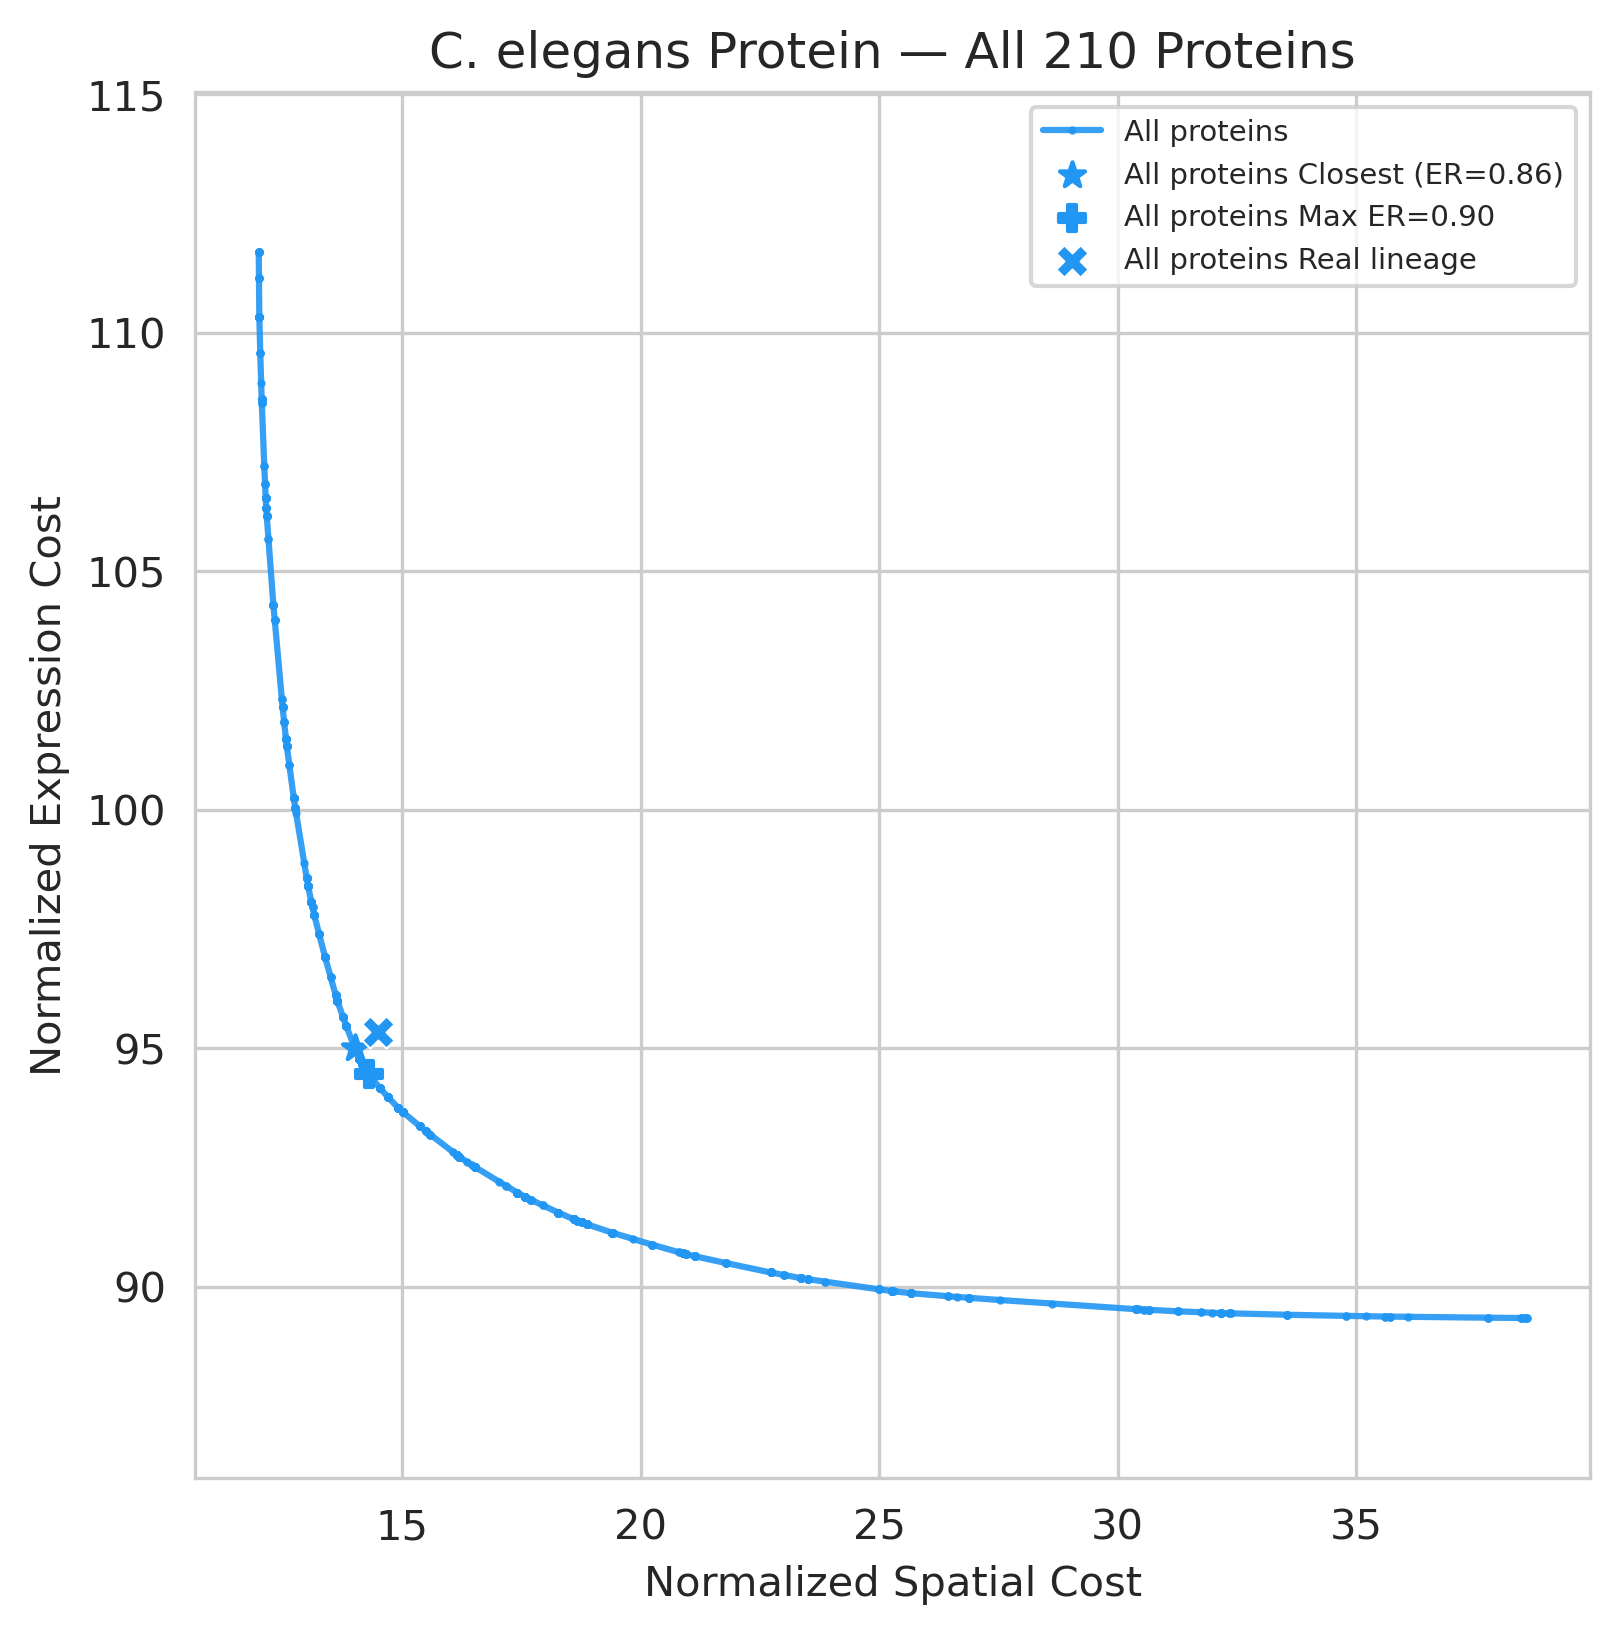

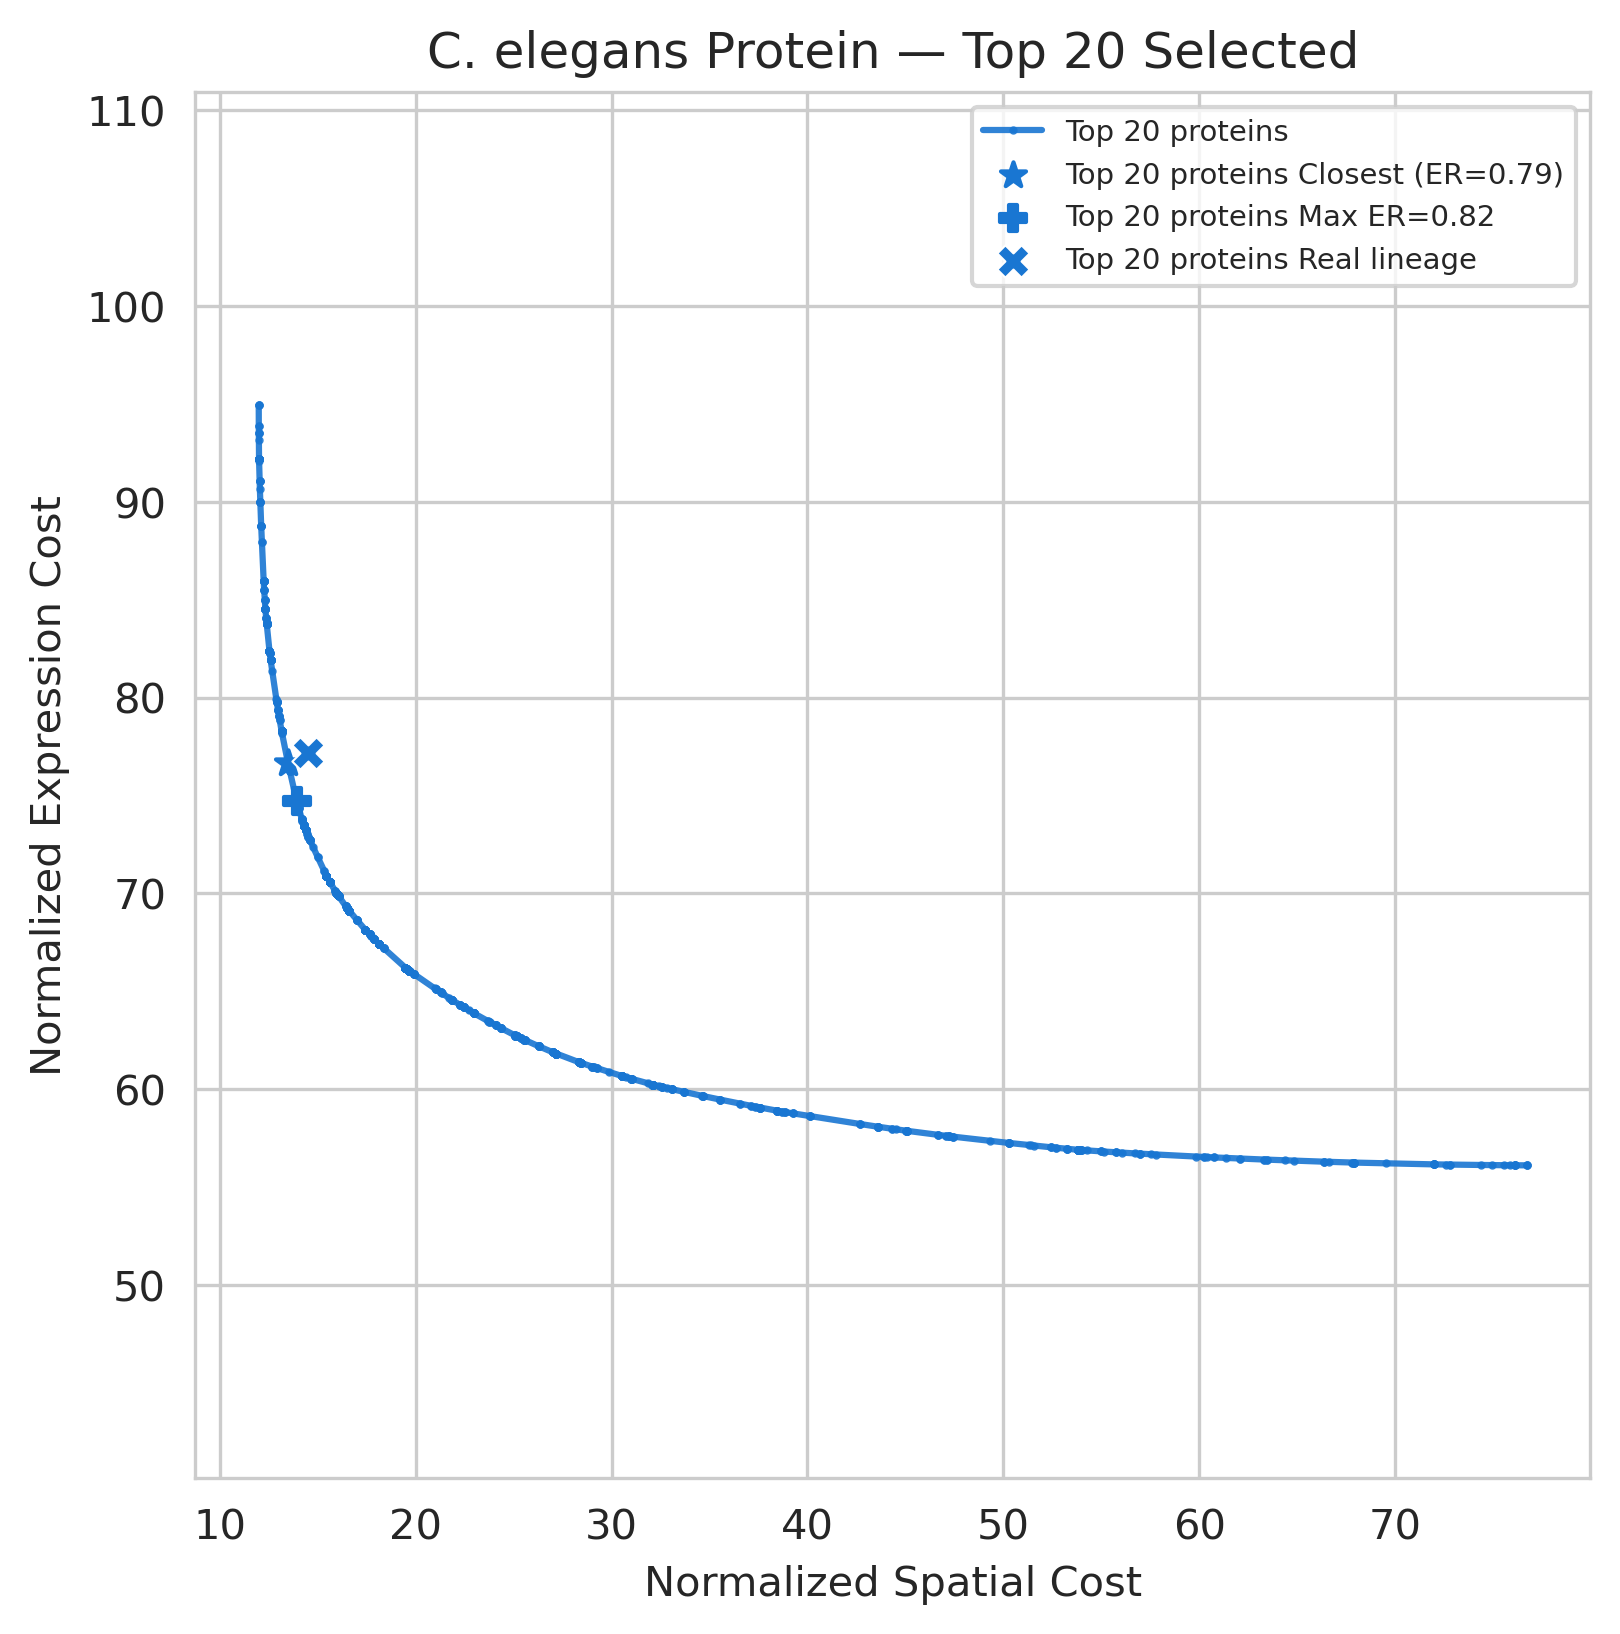

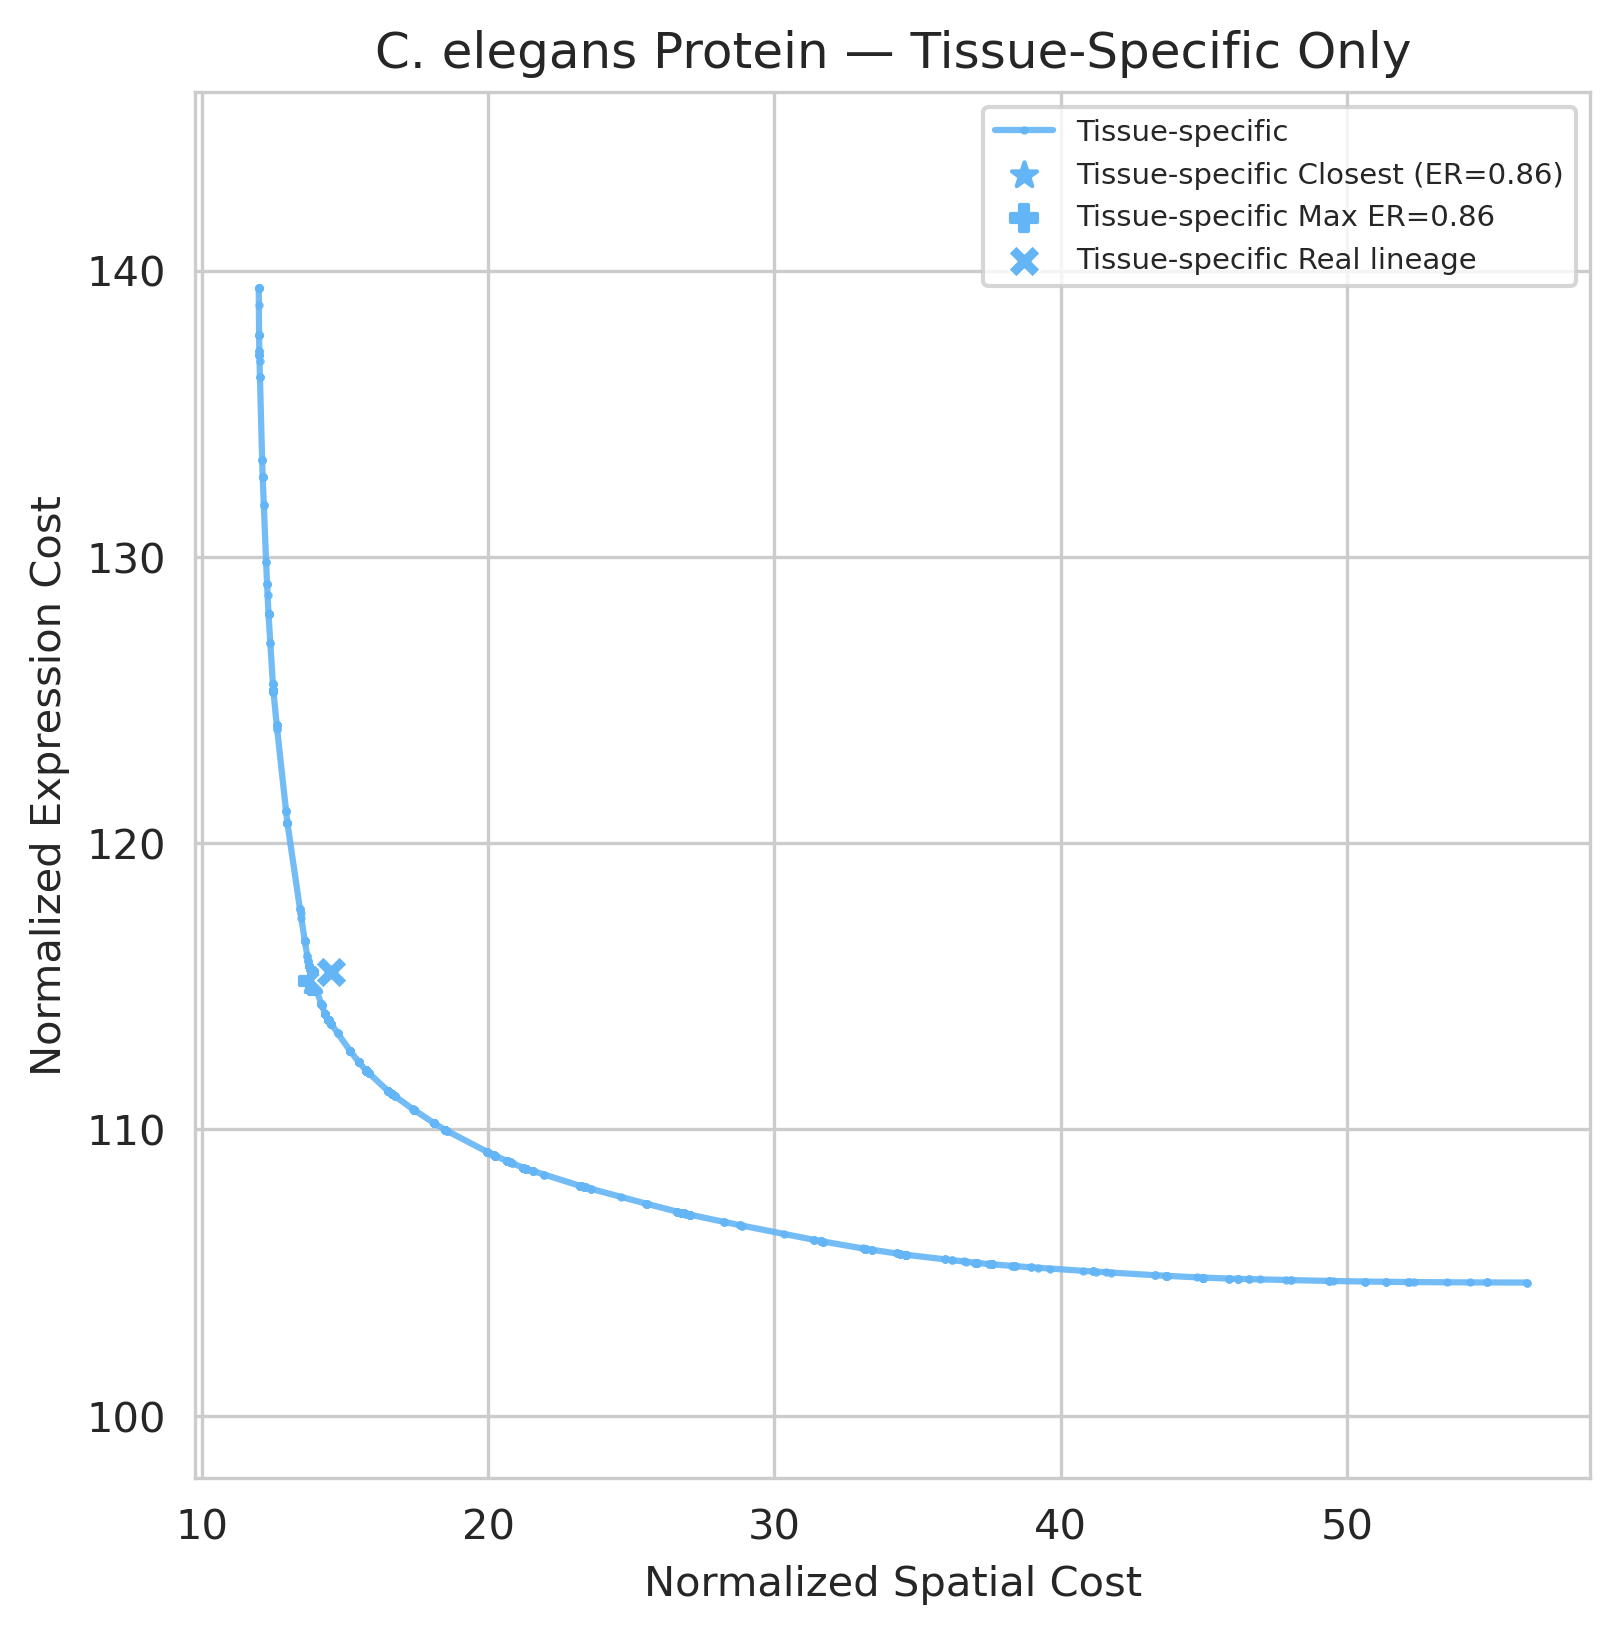

In [12]:
# ── Pareto front analysis ──

def print_pareto_summary(res, label=""):
    """Print the key scale-invariant metrics from a pareto result."""
    print(f"  {label}")
    print(f"    Spatial optimum edge ratio:     {res['optimal_xyz_edge_ratio']:.4f}")
    print(f"    Expression optimum edge ratio:  {res['optimal_exp_edge_ratio']:.4f}")
    print(f"    Max edge ratio (best trade-off): {res['largest_edge_ratio']:.4f}")
    print(f"    Closest distance to Pareto:     {res['closest_distance']:.4f}")

print("=" * 60)
print("C. ELEGANS PROTEIN — PARETO FRONT RESULTS")
print("=" * 60)

# 1) All proteins
res_all_prot = pareto_calculate(
    xyz_cost_prot, all_exp_cost_full_prot, prot_data['terminal_parents'],
    plot_figure=True, figure_title="C. elegans Protein — All 210 Proteins",
    color='#2196F3', label='All proteins'
)
print_pareto_summary(res_all_prot, "All 210 proteins")

# 2) Top 20 proteins
res_top_prot = pareto_calculate(
    xyz_cost_prot, all_exp_cost_prot, prot_data['terminal_parents'],
    plot_figure=True, figure_title="C. elegans Protein — Top 20 Selected",
    color='#1976D2', label='Top 20 proteins'
)
print_pareto_summary(res_top_prot, "Top 20 proteins")

# 3) Tissue-specific
res_tissue_prot = pareto_calculate(
    xyz_cost_prot, tissue_cost_prot, prot_data['terminal_parents'],
    plot_figure=True, figure_title="C. elegans Protein — Tissue-Specific Only",
    color='#64B5F6', label='Tissue-specific'
)
print_pareto_summary(res_tissue_prot, "Tissue-specific")


In [13]:
# ── Random baseline: 20 random proteins × 1000 shuffles ──
print("Running random baseline for C. elegans protein (this takes ~2 min)...")

prot_random_mats = build_random_cost_matrices(
    prot_data['terminal_parents'], prot_data['terminal_nodes'],
    full_exp_dict_prot, n_features=20, n_random=1000
)

prot_random_results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(pareto_calculate)(xyz_cost_prot, rmat, prot_data['terminal_parents'],
                              plot_figure=False)
    for rmat in tqdm(prot_random_mats, desc="Random baseline: protein")
)

prot_rand_df = pd.DataFrame(prot_random_results)
print("\nRandom baseline summary (protein, 20 random features, n=1000):")
print(f"  Spatial optimum ER:     {prot_rand_df['optimal_xyz_edge_ratio'].mean():.4f} ± {prot_rand_df['optimal_xyz_edge_ratio'].std():.4f}")
print(f"  Expression optimum ER:  {prot_rand_df['optimal_exp_edge_ratio'].mean():.4f} ± {prot_rand_df['optimal_exp_edge_ratio'].std():.4f}")
print(f"  Max edge ratio:         {prot_rand_df['largest_edge_ratio'].mean():.4f} ± {prot_rand_df['largest_edge_ratio'].std():.4f}")
print(f"  Closest distance:       {prot_rand_df['closest_distance'].mean():.4f} ± {prot_rand_df['closest_distance'].std():.4f}")
print(f"\nReal (top 20 selected features):")
print(f"  Spatial optimum ER:     {res_top_prot['optimal_xyz_edge_ratio']:.4f}")
print(f"  Expression optimum ER:  {res_top_prot['optimal_exp_edge_ratio']:.4f}")
print(f"  Max edge ratio:         {res_top_prot['largest_edge_ratio']:.4f}")
print(f"  Closest distance:       {res_top_prot['closest_distance']:.4f}")


Running random baseline for C. elegans protein (this takes ~2 min)...


Random feature matrices:   0%|          | 0/1000 [00:00<?, ?it/s]

Random feature matrices:   6%|▋         | 64/1000 [00:00<00:11, 79.18it/s]

Random feature matrices:  10%|▉         | 96/1000 [00:01<00:14, 62.43it/s]

Random feature matrices:  13%|█▎        | 128/1000 [00:02<00:17, 50.42it/s]

...

Random baseline: protein:  93%|█████████▎| 928/1000 [02:26<00:11,  6.09it/s]

Random baseline: protein:  96%|█████████▌| 960/1000 [02:32<00:06,  5.94it/s]

Random baseline: protein:  99%|█████████▉| 992/1000 [02:37<00:01,  5.97it/s]

Random baseline: protein: 100%|██████████| 1000/1000 [02:37<00:00,  6.34it/s]


Random baseline summary (protein, 20 random features, n=1000):
  Spatial optimum ER:     0.5987 ± 0.0000
  Expression optimum ER:  0.1135 ± 0.0393
  Max edge ratio:         0.7054 ± 0.0382
  Closest distance:       1.7789 ± 0.3021

Real (top 20 selected features):
  Spatial optimum ER:     0.5987
  Expression optimum ER:  0.2040
  Max edge ratio:         0.8194
  Closest distance:       1.1315


  Gaussian noise (null control)
    Spatial optimum edge ratio:     0.5987
    Expression optimum edge ratio:  0.0067
    Max edge ratio (best trade-off): 0.5987
    Closest distance to Pareto:     6.8200


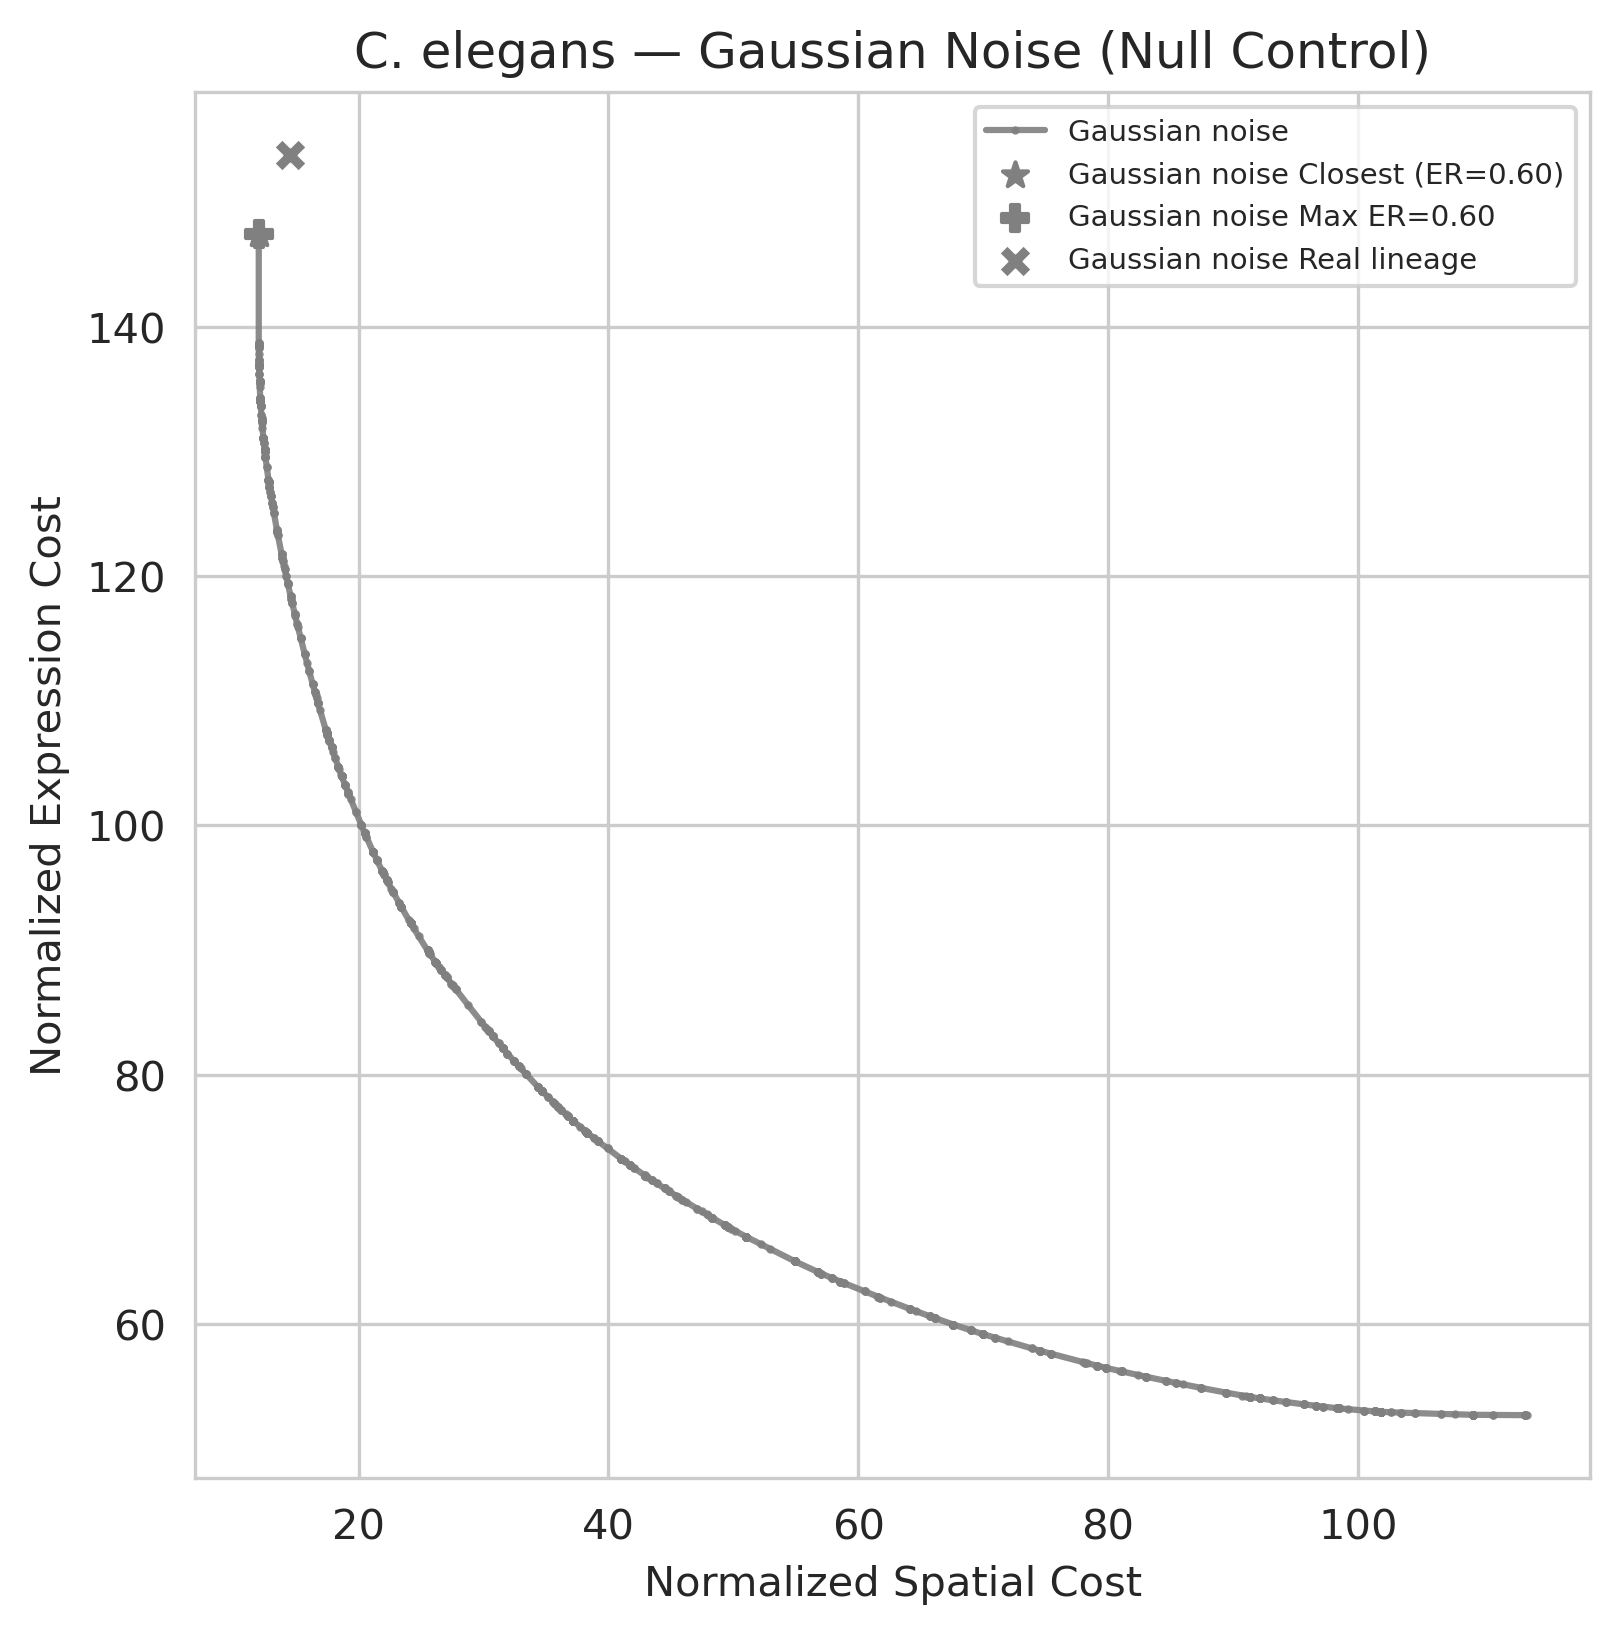

In [14]:
# ── Gaussian noise control ──
gauss_cost_prot = np.zeros((len(prot_data['terminal_parents']), len(prot_data['terminal_nodes'])))
n_proteins = protein_exp_full.shape[1]
rng = np.random.default_rng(42)
for i, parent in enumerate(prot_data['terminal_parents']):
    for j, node in enumerate(prot_data['terminal_nodes']):
        pvec = rng.normal(0, 1, size=n_proteins)
        nvec = rng.normal(0, 1, size=n_proteins)
        gauss_cost_prot[i, j] = cosine(pvec, nvec)

res_gauss_prot = pareto_calculate(
    xyz_cost_prot, gauss_cost_prot, prot_data['terminal_parents'],
    plot_figure=True, figure_title="C. elegans — Gaussian Noise (Null Control)",
    color='gray', label='Gaussian noise'
)
print_pareto_summary(res_gauss_prot, "Gaussian noise (null control)")


### Std-Based Normalization Example

Compare the Pareto front under std-based scaling (1 unit = 1σ of cousin-randomized total cost).
The lineage point is no longer forced to (1,1); its position shows how many standard deviations
the real lineage is from random. Edge retention is unchanged.

Protein terminal cells (T=255): 299
Cousin groups (>=2): 93 (covering 265 cells)

Lineage spatial cost: 785.8 = -9.3 std from random mean
Lineage expression cost: 138.400 = -5.5 std from random mean
Random spatial: mean=1072.0, std=30.7
Random expression: mean=143.414, std=0.912



Edge retention check:
  Expr opt: ratio=0.2040, std=0.2040 ✓
  Max ER:   ratio=0.8194, std=0.8194 ✓
  Spat opt: ratio=0.5987, std=0.5987 ✓


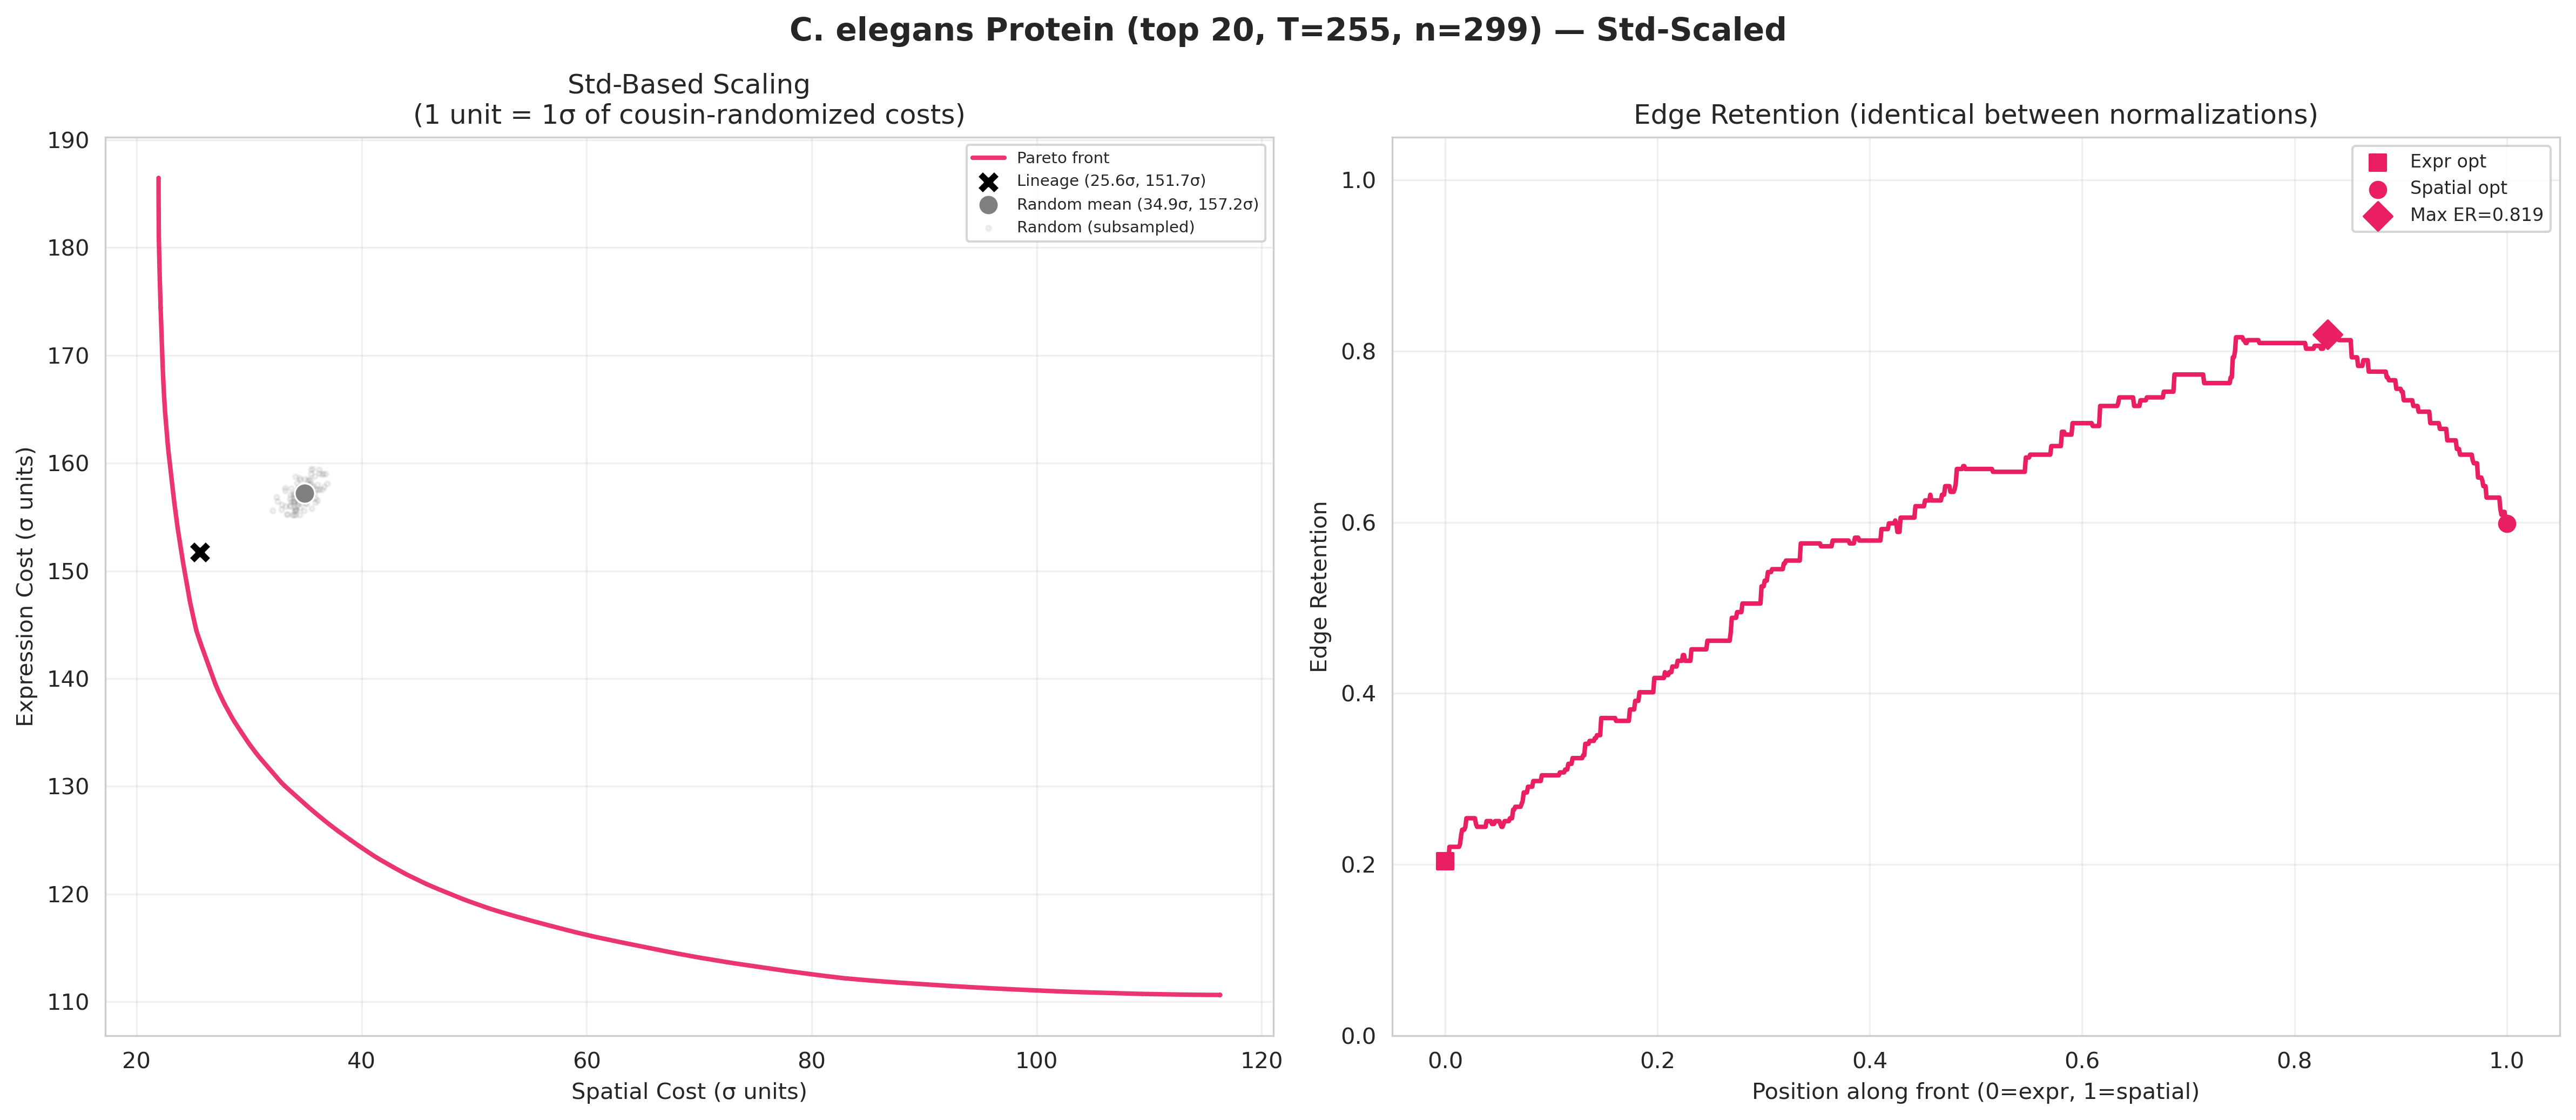

In [15]:
# ═══════════════════════════════════════════════════════════
# Std-based normalization demonstration on C. elegans Protein
# ═══════════════════════════════════════════════════════════

# Inline definition (also defined later; included here for early cells that need it)
def _compute_ratio_pareto(xyz_cost_mat, exp_cost_mat, terminal_parents, iteration=1000):
    lineage_xyz = xyz_cost_mat.diagonal().sum()
    lineage_exp = exp_cost_mat.diagonal().sum()
    xyz_rel = xyz_cost_mat / lineage_xyz; exp_rel = exp_cost_mat / lineage_exp
    xyz_list, exp_list, edge_ratios = [], [], []
    for i in range(iteration + 1):
        alpha = i / iteration
        row_ind, col_ind = linear_sum_assignment(alpha * xyz_rel + (1 - alpha) * exp_rel)
        xyz_list.append(xyz_rel[row_ind, col_ind].sum())
        exp_list.append(exp_rel[row_ind, col_ind].sum())
        edge_ratios.append(lineage_edge_ratio(row_ind, col_ind, terminal_parents))
    edge_ratios = np.array(edge_ratios)
    max_er_idx = int(np.argmax(edge_ratios))
    key_points = {"expr_opt_idx": 0, "xyz_opt_idx": iteration, "max_er_idx": max_er_idx}
    return np.array(xyz_list), np.array(exp_list), edge_ratios, key_points

# Compute cousin groups for the protein terminal cells
prot_cousin_groups = build_cousin_groups(prot_data['terminal_nodes'], gp_map)
cells_in_groups = sum(len(g) for g in prot_cousin_groups)
print(f"Protein terminal cells (T=255): {len(prot_data['terminal_nodes'])}")
print(f"Cousin groups (>=2): {len(prot_cousin_groups)} (covering {cells_in_groups} cells)")

# Compute std-based scaling factors from cousin-group randomization
prot_random_stats = compute_cousin_random_stats(
    xyz_cost_prot, all_exp_cost_prot, prot_cousin_groups, n_random=1000, seed=42
)

lineage_xyz = xyz_cost_prot.diagonal().sum()
lineage_exp = all_exp_cost_prot.diagonal().sum()
xyz_z = (lineage_xyz - prot_random_stats['xyz_mean']) / prot_random_stats['xyz_std']
exp_z = (lineage_exp - prot_random_stats['exp_mean']) / prot_random_stats['exp_std']
print(f"\nLineage spatial cost: {lineage_xyz:.1f} = {xyz_z:+.1f} std from random mean")
print(f"Lineage expression cost: {lineage_exp:.3f} = {exp_z:+.1f} std from random mean")
print(f"Random spatial: mean={prot_random_stats['xyz_mean']:.1f}, std={prot_random_stats['xyz_std']:.1f}")
print(f"Random expression: mean={prot_random_stats['exp_mean']:.3f}, std={prot_random_stats['exp_std']:.3f}")

# Compute std-scaled Pareto front
std_xyz_pf, std_exp_pf, std_edges, std_kp = compute_std_scaled_pareto(
    xyz_cost_prot, all_exp_cost_prot, prot_data['terminal_parents'], prot_random_stats
)

# Also compute ratio-based for edge retention comparison
_, _, ratio_edges, _ = _compute_ratio_pareto(
    xyz_cost_prot, all_exp_cost_prot, prot_data['terminal_parents']
)
print(f"\nEdge retention check:")
print(f"  Expr opt: ratio={ratio_edges[0]:.4f}, std={std_edges[0]:.4f} {'✓' if abs(ratio_edges[0]-std_edges[0])<1e-10 else '✗'}")
print(f"  Max ER:   ratio={ratio_edges.max():.4f}, std={std_edges.max():.4f} {'✓' if abs(ratio_edges.max()-std_edges.max())<1e-10 else '✗'}")
print(f"  Spat opt: ratio={ratio_edges[-1]:.4f}, std={std_edges[-1]:.4f} {'✓' if abs(ratio_edges[-1]-std_edges[-1])<1e-10 else '✗'}")

# ── Figure: Std-based scaling only ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
x_front = np.linspace(0, 1, 1001)

# Left: Std-scaled Pareto front
ax_l.plot(std_xyz_pf, std_exp_pf, color='#E91E63', lw=2, alpha=0.9, label='Pareto front')
lx_std = lineage_xyz / prot_random_stats['xyz_std']
le_std = lineage_exp / prot_random_stats['exp_std']
ax_l.scatter(lx_std, le_std, color='black', marker='X', s=100, edgecolors='white', lw=0.8,
          zorder=10, label=f'Lineage ({lx_std:.1f}σ, {le_std:.1f}σ)')
rm_x = prot_random_stats['xyz_mean'] / prot_random_stats['xyz_std']
rm_e = prot_random_stats['exp_mean'] / prot_random_stats['exp_std']
ax_l.scatter(rm_x, rm_e, color='gray', marker='o', s=80, edgecolors='white', lw=0.8,
          zorder=9, label=f'Random mean ({rm_x:.1f}σ, {rm_e:.1f}σ)')
rand_x = prot_random_stats['random_xyz'][::10] / prot_random_stats['xyz_std']
rand_e = prot_random_stats['random_exp'][::10] / prot_random_stats['exp_std']
ax_l.scatter(rand_x, rand_e, color='gray', alpha=0.10, s=5, label='Random (subsampled)')
ax_l.set_xlabel('Spatial Cost (σ units)'); ax_l.set_ylabel('Expression Cost (σ units)')
ax_l.set_title('Std-Based Scaling\n(1 unit = 1σ of cousin-randomized costs)', fontsize=12)
ax_l.legend(fontsize=7, loc='upper right'); ax_l.grid(True, alpha=0.3)

# Right: Edge retention
ax_r.plot(x_front, std_edges, color='#E91E63', lw=2)
ax_r.scatter(0, std_edges[0], color='#E91E63', marker='s', s=50, zorder=8, label='Expr opt')
ax_r.scatter(1, std_edges[-1], color='#E91E63', marker='o', s=50, zorder=8, label='Spatial opt')
ax_r.scatter(x_front[std_kp['max_er_idx']], std_edges[std_kp['max_er_idx']],
           color='#E91E63', marker='D', s=80, zorder=8, label=f'Max ER={std_edges.max():.3f}')
ax_r.set_xlabel('Position along front (0=expr, 1=spatial)'); ax_r.set_ylabel('Edge Retention')
ax_r.set_title('Edge Retention (identical between normalizations)', fontsize=12)
ax_r.set_ylim(0, 1.05); ax_r.grid(True, alpha=0.3); ax_r.legend(fontsize=8)

fig.suptitle('C. elegans Protein (top 20, T=255, n=299) — Std-Scaled',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


---
## Subtree / Cell Type Analysis — C. elegans Protein

Two parallel ways to partition the terminal cells for Pareto analysis.
Set `ANALYSIS_MODE` below to choose:

- **`'subtree'`** — partition by lineage branch (AB, ABa, ABp, P1 vs Full tree)
- **`'cell_type'`** — partition by cell type (top 3 types + rest, using WormWeb annotations)

Cell type analysis only applies to C. elegans protein data (the only config with broad enough coverage).
Apoptotic cells (`programmed_death`) can be singled out as their own group or merged into "rest".


  Subtree AB          :  216 cells | Expr opt ER=0.218 | Max ER=0.838 | XYZ opt ER=0.671


  Subtree ABa         :  106 cells | Expr opt ER=0.302 | Max ER=0.887 | XYZ opt ER=0.679


  Subtree ABp         :  110 cells | Expr opt ER=0.245 | Max ER=0.882 | XYZ opt ER=0.773


  Subtree P1          :   83 cells | Expr opt ER=0.337 | Max ER=0.880 | XYZ opt ER=0.771


  Subtree Full tree   :  299 cells | Expr opt ER=0.204 | Max ER=0.819 | XYZ opt ER=0.599

Cell type distribution (terminal cells with protein + tracking):
  neuron              :   97
  muscle              :   61
  epithelium          :   57
  programmed_death    :   34
  glial               :   20
  alimentary          :   20
  excretory           :    4
  other               :    3
  reproduction        :    2
  mesoderm            :    1

Analysis groups (SINGLE_OUT_APOPTOTIC=True):
  neuron              :   97
  muscle              :   61
  epithelium          :   57
  rest (other types)  :   50
  programmed_death    :   34
  neuron: 97 cells — running Pareto...


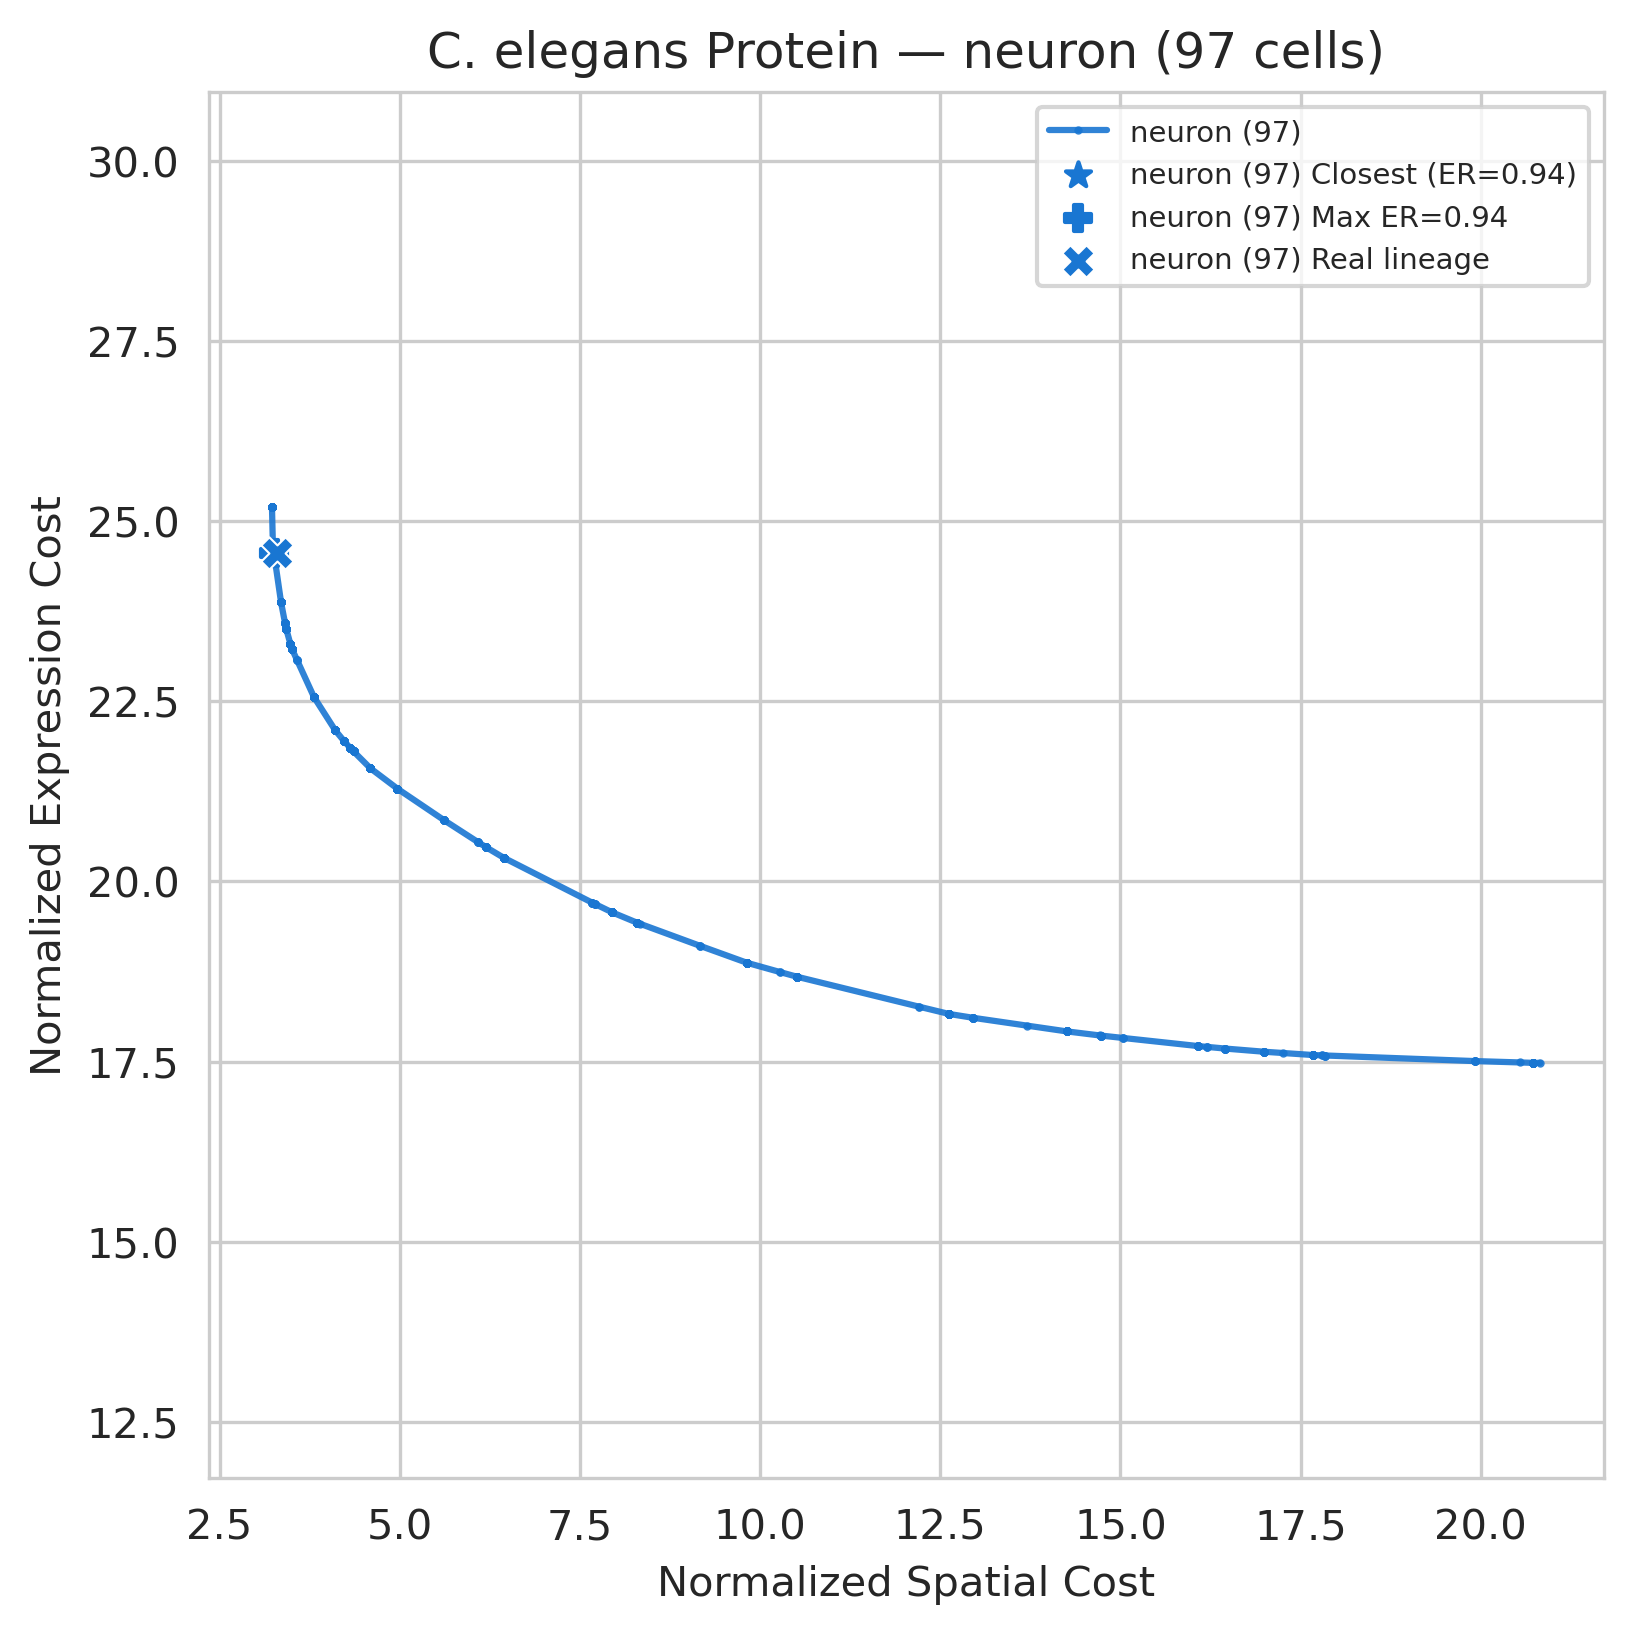

    Expr opt ER=0.227 | Max ER=0.938 | XYZ opt ER=0.897
  muscle: 61 cells — running Pareto...


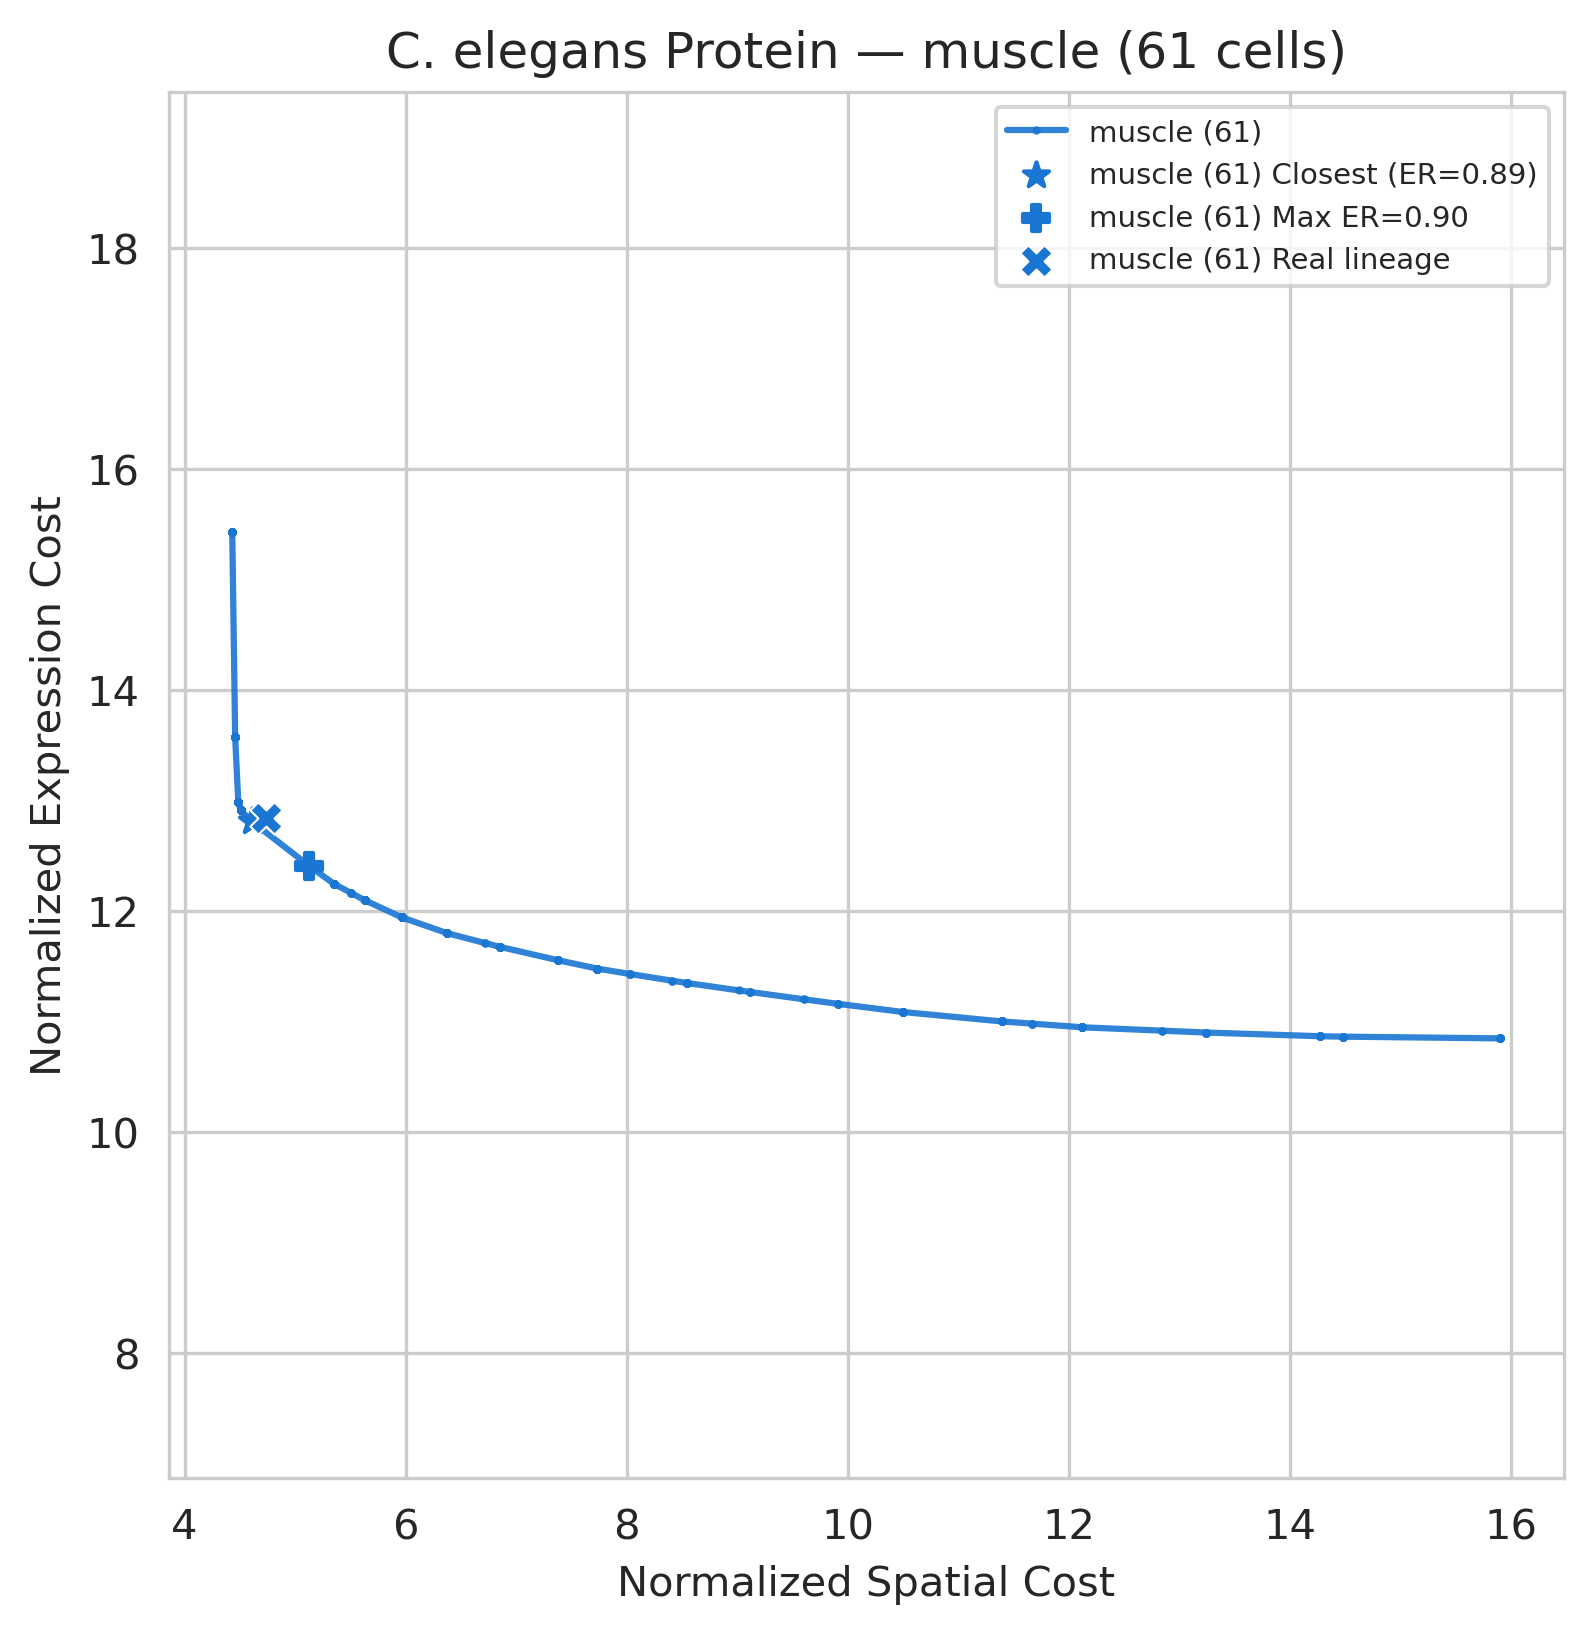

    Expr opt ER=0.311 | Max ER=0.902 | XYZ opt ER=0.754
  epithelium: 57 cells — running Pareto...


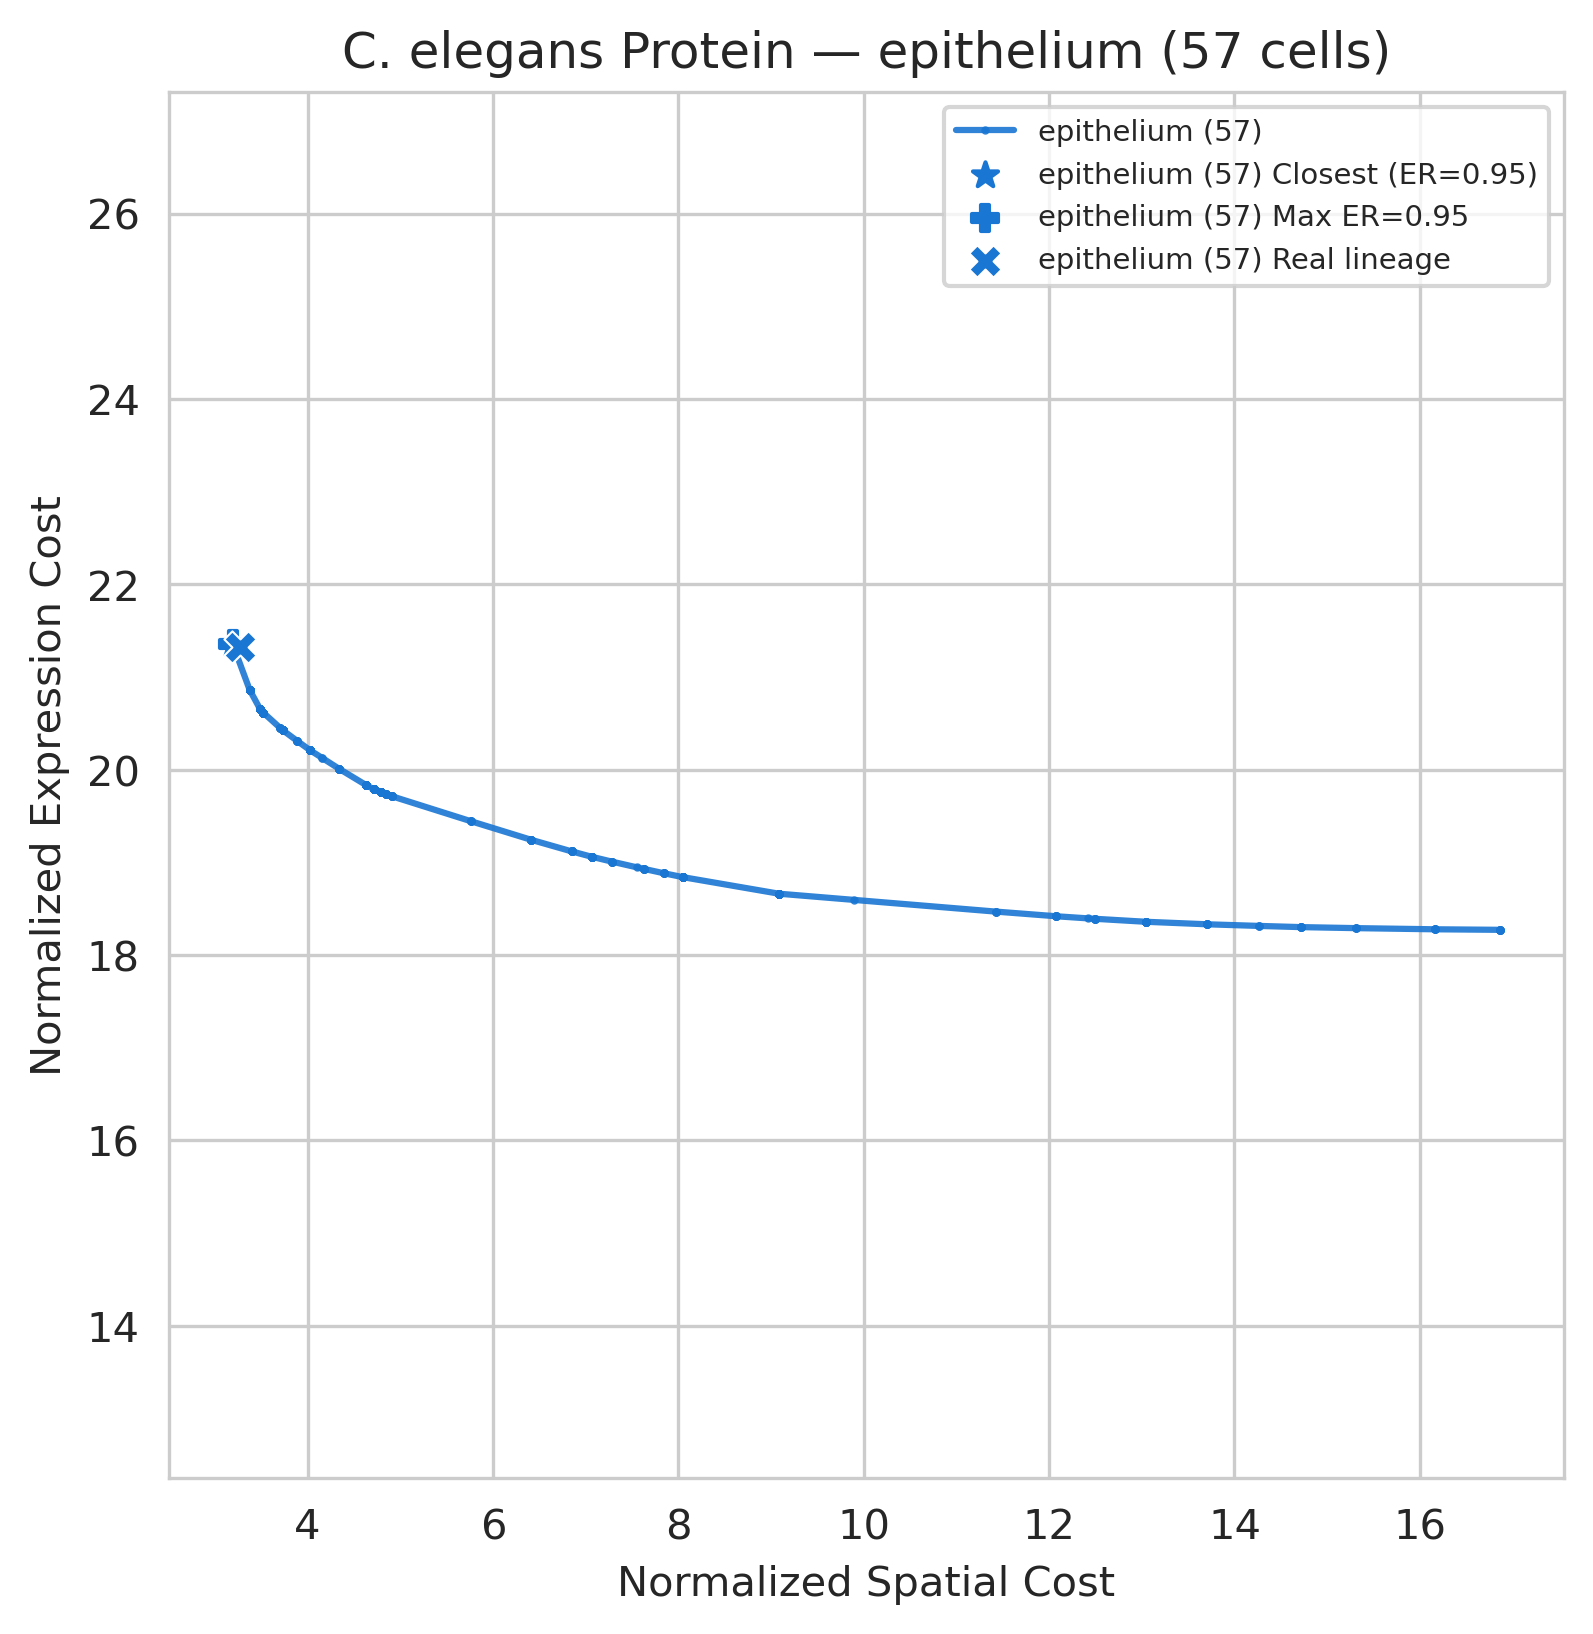

    Expr opt ER=0.193 | Max ER=0.947 | XYZ opt ER=0.912

'rest (other types)' includes: {'alimentary', 'excretory', 'glial', 'other', 'reproduction', 'mesoderm'}
  rest (other types): 50 cells — running Pareto...


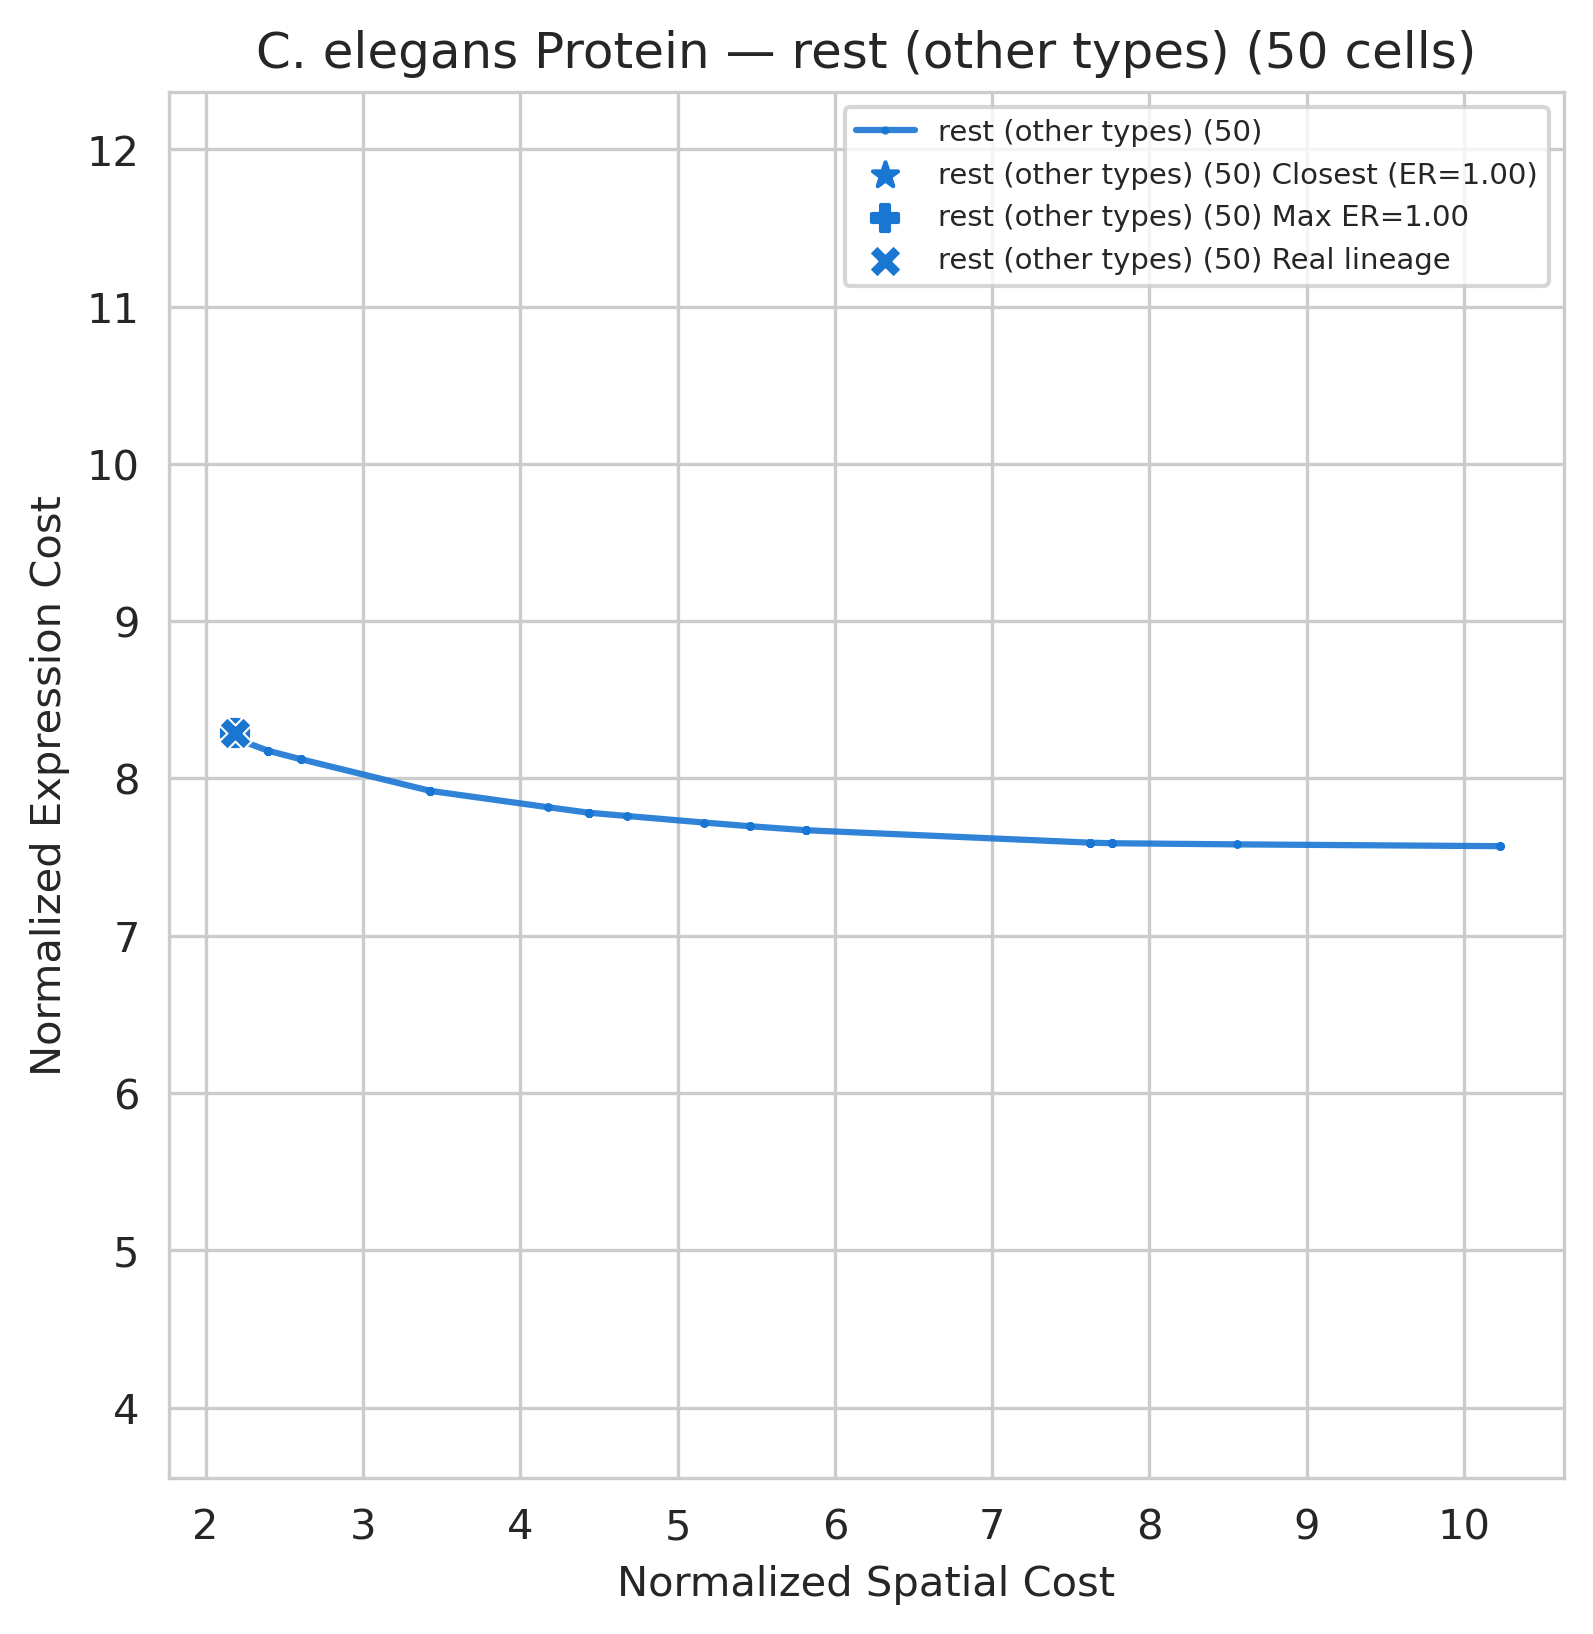

    Expr opt ER=0.420 | Max ER=1.000 | XYZ opt ER=0.960
  programmed_death: 34 cells — running Pareto...


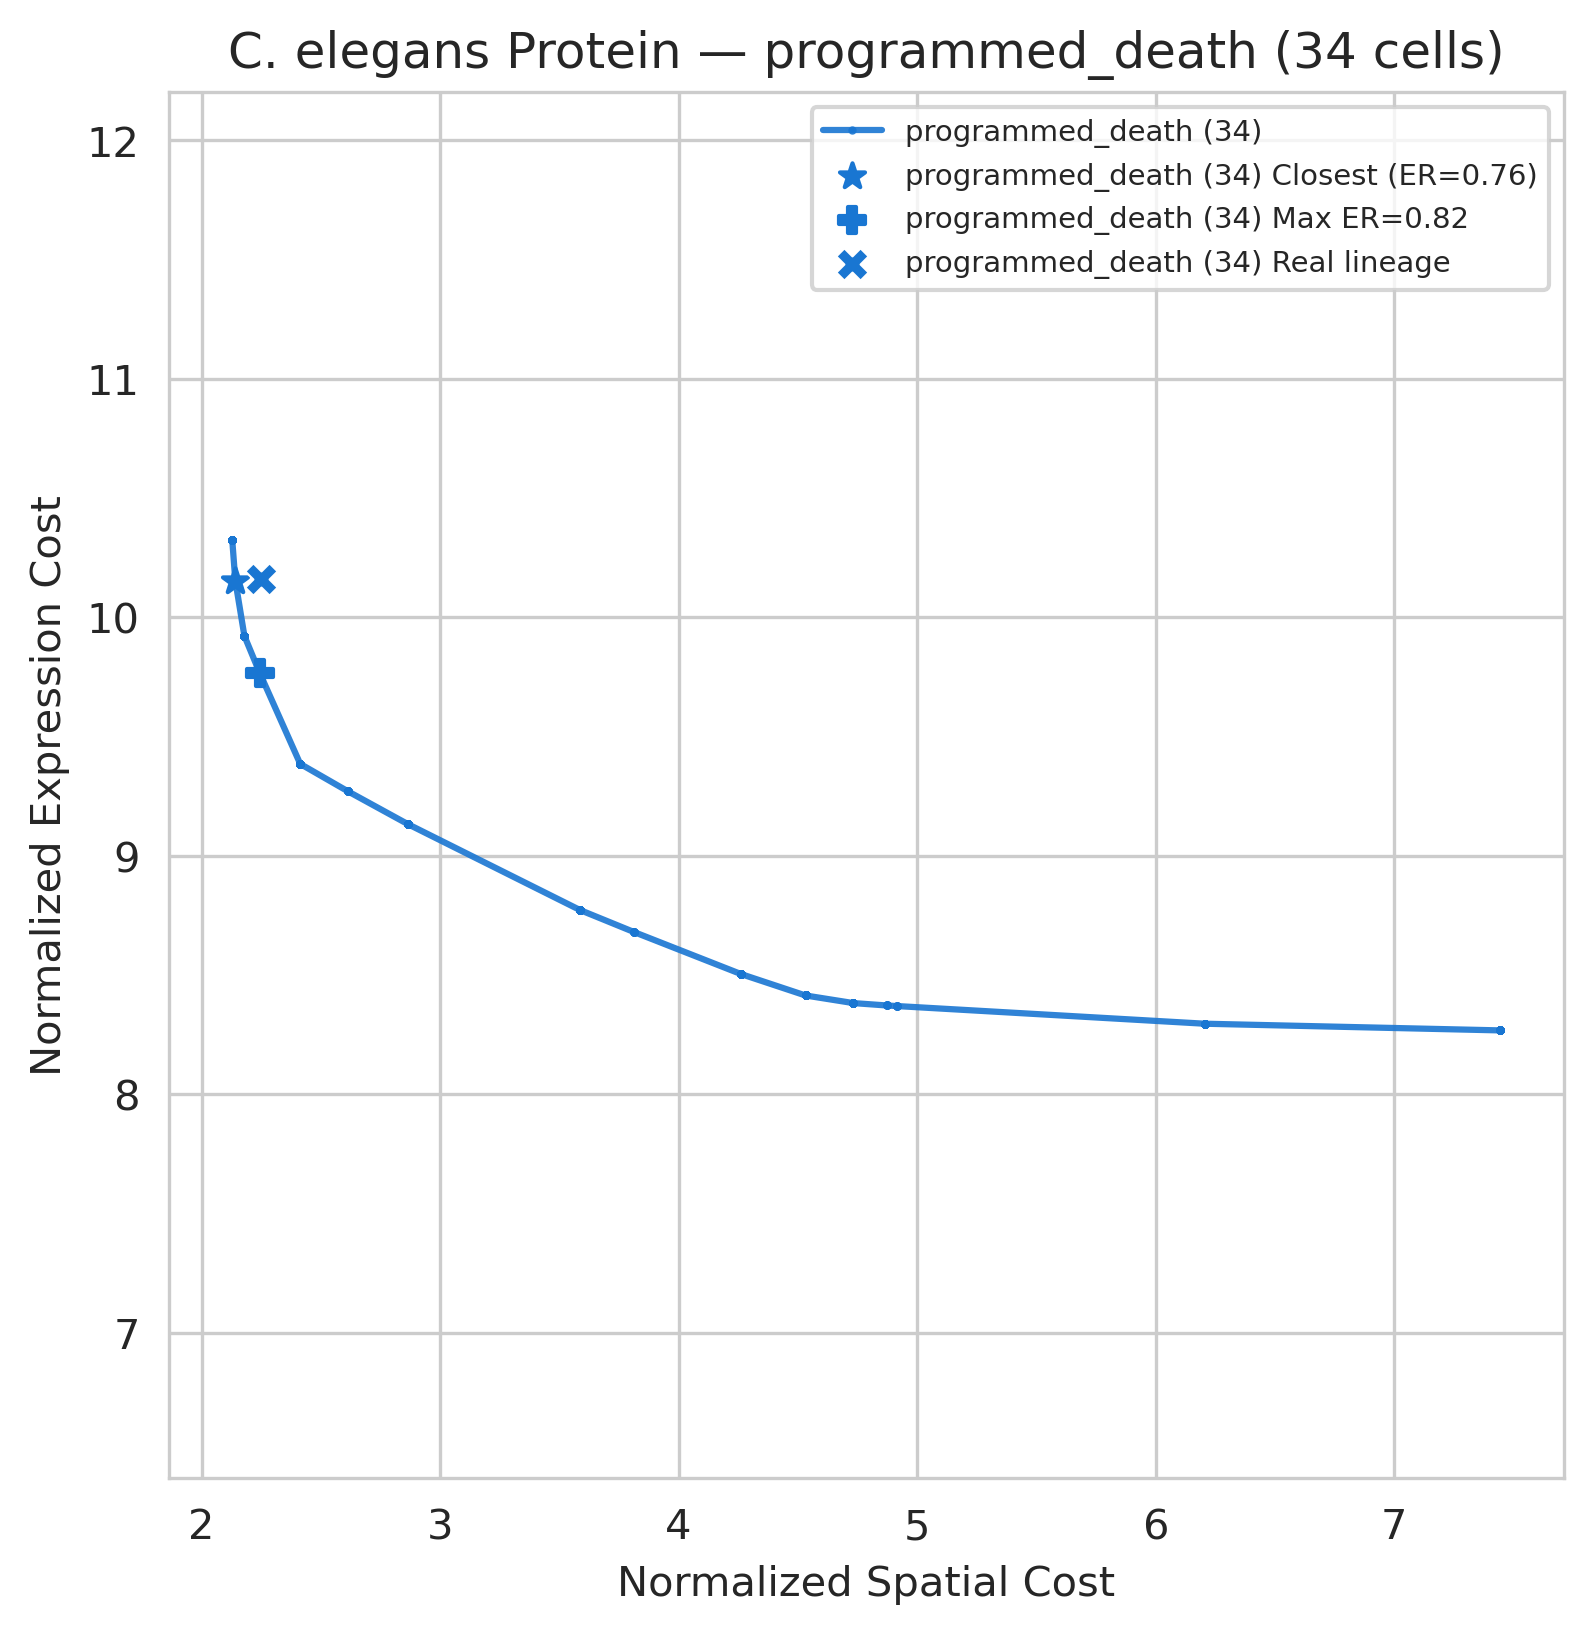

    Expr opt ER=0.353 | Max ER=0.824 | XYZ opt ER=0.706


In [16]:
# ═══════════════════════════════════════════════════════
# CONFIG: Choose analysis mode
# ═══════════════════════════════════════════════════════

ANALYSIS_MODE = 'cell_type'   # 'subtree' | 'cell_type'
SINGLE_OUT_APOPTOTIC = True   # only used in 'cell_type' mode

# ═══════════════════════════════════════════════════════
# Shared constants (needed by RNA subtree sections below)
# ═══════════════════════════════════════════════════════

SUBTREE_ROOTS = ["AB", "ABa", "ABp", "P1"]
subtree_labels = ["Full tree", "AB", "ABa", "ABp", "P1"]  # needed by RNA subtree cells



# ═══════════════════════════════════════════════════════
# Cell type loading (used in cell_type mode)
# ═══════════════════════════════════════════════════════

CELL_TYPE_MERGE_MAP = {
    'neuron':    'neuron',
    'muscle':    'muscle',
    'repro':     'reproduction',
    'hypoderm':  'epithelium',
    'epithelium':'epithelium',
    'sheath':    'glial',
    'socket':    'glial',
    'coelomocyte':'coelomocyte',
    'excretory': 'excretory',
    'mesoderm':  'mesoderm',
    'other':     'other',
    'intestine': 'alimentary',
    'valve':     'alimentary',
    'marginal':  'alimentary',
    'gland':     'alimentary',
    'rectal':    'alimentary',
    'tail':      'programmed_death',
    'programmed_death': 'programmed_death',
    'blast':     'programmed_death',
}

cell_type_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
lineage_to_type = {}
for _, row in cell_type_df.iterrows():
    lineage = row.get('wormweb.lineage', '')
    raw_type = row.get('wormweb.type', '')
    if pd.notna(raw_type) and raw_type.strip():
        lineage_to_type[lineage] = CELL_TYPE_MERGE_MAP.get(raw_type.strip(), raw_type.strip())

def get_cell_type(lineage_name):
    return lineage_to_type.get(lineage_name, 'programmed_death')


# ═══════════════════════════════════════════════════════
# Always run: protein subtree analysis (fast, needed by RNA comparisons)
# ═══════════════════════════════════════════════════════

subtree_results = {}
for sroot in SUBTREE_ROOTS + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    
    if sroot == 'Full':
        term_data = prot_data
    else:
        term_data = collect_terminal_cells(
            lineage_data, valid_cell_names_protein,
            protein_exp_index=protein_exp_full.index,
            include_embryonic_terminals=False,
            include_apoptotic_cells=True,
            subtree_root_name=sroot
        )
    
    n_term = len(term_data['terminal_nodes'])
    xyz_mat, exp_mat, full_exp_dict, _ = build_cost_matrices(
        term_data['terminal_nodes'], term_data['terminal_parents'],
        all_xyz_map_elegans, protein_exp_full, selected_features=protein_selected
    )
    res = pareto_calculate(
        xyz_mat, exp_mat, term_data['terminal_parents'],
        plot_figure=False,
        figure_title=f"C. elegans Protein — {label} ({n_term} cells)",
        color='#1976D2', label=f'{label} ({n_term})'
    )
    
    subtree_results[label] = {
        'term_data': term_data, 'xyz_mat': xyz_mat, 'exp_mat': exp_mat,
        'full_exp_dict': full_exp_dict, 'pareto': res,
    }
    print(f"  Subtree {label:12s}: {n_term:4d} cells | "
          f"Expr opt ER={res['optimal_exp_edge_ratio']:.3f} | "
          f"Max ER={res['largest_edge_ratio']:.3f} | "
          f"XYZ opt ER={res['optimal_xyz_edge_ratio']:.3f}")


# ═══════════════════════════════════════════════════════
# Conditional: cell type analysis (only when mode='cell_type')
# ═══════════════════════════════════════════════════════

if ANALYSIS_MODE == 'cell_type':
    
    term_nodes = prot_data['terminal_nodes']
    term_parents_list = prot_data['terminal_parents']
    
    cell_type_counts = defaultdict(int)
    node_type_map = {}
    for node in term_nodes:
        ct = get_cell_type(node)
        node_type_map[node] = ct
        cell_type_counts[ct] += 1
    
    sorted_types = sorted(cell_type_counts.items(), key=lambda x: -x[1])
    print("\nCell type distribution (terminal cells with protein + tracking):")
    for ct, count in sorted_types:
        print(f"  {ct:20s}: {count:4d}")
    
    apoptotic_label = 'programmed_death'
    non_apoptotic = [(ct, cnt) for ct, cnt in sorted_types if ct != apoptotic_label]
    apoptotic_count = cell_type_counts.get(apoptotic_label, 0)
    
    if SINGLE_OUT_APOPTOTIC and apoptotic_count > 0:
        top3 = non_apoptotic[:3]
        rest_count = sum(cnt for ct, cnt in non_apoptotic[3:])
        groups = [(ct, cnt) for ct, cnt in top3]
        if rest_count > 0:
            groups.append(('rest (other types)', rest_count))
        groups.append((apoptotic_label, apoptotic_count))
    else:
        top3 = sorted_types[:3]
        rest_count = sum(cnt for ct, cnt in sorted_types[3:])
        groups = [(ct, cnt) for ct, cnt in top3]
        if rest_count > 0:
            groups.append(('rest (other types)', rest_count))
    
    print(f"\nAnalysis groups (SINGLE_OUT_APOPTOTIC={SINGLE_OUT_APOPTOTIC}):")
    for ct, cnt in groups:
        print(f"  {ct:20s}: {cnt:4d}")
    
    cell_type_results = {}
    
    for group_name, _ in groups:
        if group_name == 'rest (other types)':
            if SINGLE_OUT_APOPTOTIC and apoptotic_count > 0:
                included_types = set(ct for ct, cnt in non_apoptotic[3:])
            else:
                included_types = set(ct for ct, cnt in sorted_types[3:])
            print(f"\n'rest (other types)' includes: {included_types}")
        elif group_name == apoptotic_label:
            included_types = {apoptotic_label}
        else:
            included_types = {group_name}
        
        group_nodes = []
        group_parents = []
        for node, parent in zip(term_nodes, term_parents_list):
            if node_type_map.get(node, 'programmed_death') in included_types:
                if node in all_xyz_map_elegans and parent in all_xyz_map_elegans:
                    group_nodes.append(node)
                    group_parents.append(parent)
        
        if len(group_nodes) < 10:
            print(f"  {group_name}: {len(group_nodes)} cells — too few, skipping Pareto")
            continue
        
        print(f"  {group_name}: {len(group_nodes)} cells — running Pareto...")
        
        xyz_mat, exp_mat, full_exp_dict, _ = build_cost_matrices(
            group_nodes, group_parents,
            all_xyz_map_elegans, protein_exp_full, selected_features=protein_selected
        )
        res = pareto_calculate(
            xyz_mat, exp_mat, group_parents,
            plot_figure=True, figure_title=f"C. elegans Protein — {group_name} ({len(group_nodes)} cells)",
            color='#1976D2', label=f'{group_name} ({len(group_nodes)})'
        )
        plt.show()
        
        cell_type_results[group_name] = {
            'term_data': {'terminal_nodes': group_nodes, 'terminal_parents': group_parents},
            'xyz_mat': xyz_mat, 'exp_mat': exp_mat,
            'full_exp_dict': full_exp_dict, 'pareto': res,
        }
        
        print(f"    Expr opt ER={res['optimal_exp_edge_ratio']:.3f} | "
              f"Max ER={res['largest_edge_ratio']:.3f} | "
              f"XYZ opt ER={res['optimal_xyz_edge_ratio']:.3f}")
    
    analysis_labels = list(cell_type_results.keys())
    analysis_results = cell_type_results
    analysis_title = 'Cell Type'

elif ANALYSIS_MODE == 'subtree':
    analysis_labels = ['Full tree', 'AB', 'ABa', 'ABp', 'P1']
    analysis_results = subtree_results
    analysis_title = 'Subtree'


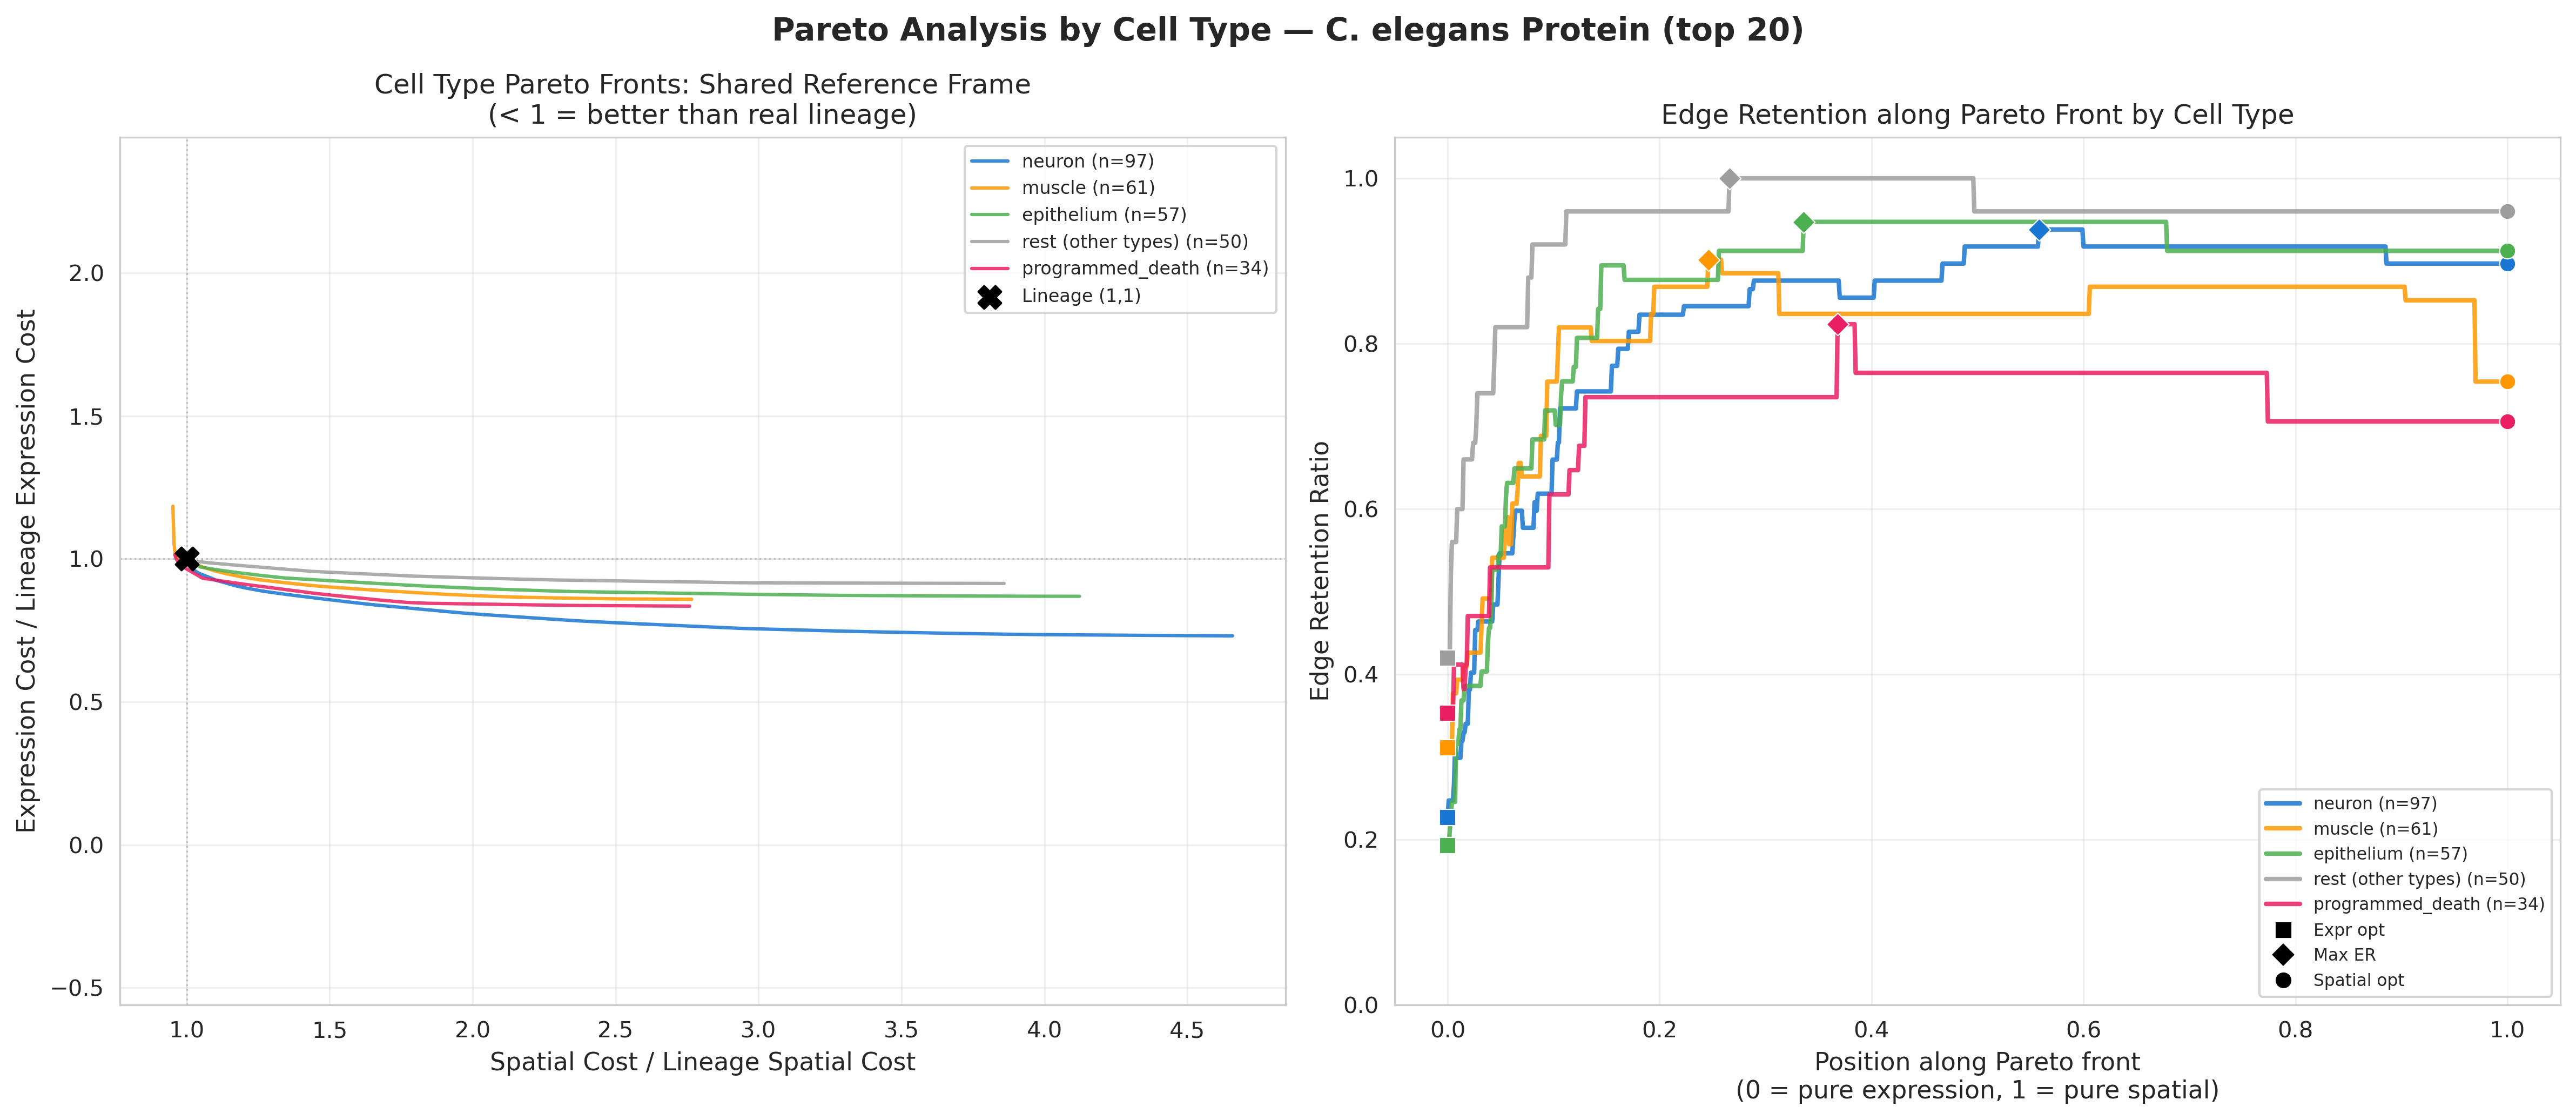

,N Cells,Expr Opt ER,Max ER,XYZ Opt ER,Closest Dist
Cell Type,,,,,
neuron,97,0.226804,0.938144,0.896907,0.042358
muscle,61,0.311475,0.901639,0.754098,0.132772
epithelium,57,0.192982,0.947368,0.912281,0.086565
rest (other types),50,0.420000,1.000000,0.960000,0.000000
programmed_death,34,0.352941,0.823529,0.705882,0.108225


In [17]:
# ═══════════════════════════════════════════════════════════
# COMPARATIVE VISUALIZATION (works for both modes)
# ═══════════════════════════════════════════════════════════

# Re-define compute_ratio_pareto here (also defined later in comparative section)
def _compute_ratio_pareto(xyz_cost_mat, exp_cost_mat, terminal_parents, iteration=1000):
    lineage_xyz = xyz_cost_mat.diagonal().sum()
    lineage_exp = exp_cost_mat.diagonal().sum()
    xyz_rel = xyz_cost_mat / lineage_xyz
    exp_rel = exp_cost_mat / lineage_exp
    xyz_list, exp_list, edge_ratios = [], [], []
    for i in range(iteration + 1):
        alpha = i / iteration
        combined = alpha * xyz_rel + (1 - alpha) * exp_rel
        row_ind, col_ind = linear_sum_assignment(combined)
        xyz_list.append(xyz_rel[row_ind, col_ind].sum())
        exp_list.append(exp_rel[row_ind, col_ind].sum())
        edge_ratios.append(lineage_edge_ratio(row_ind, col_ind, terminal_parents))
    edge_ratios = np.array(edge_ratios)
    max_er_idx = int(np.argmax(edge_ratios))
    key_points = {'expr_opt_idx': 0, 'xyz_opt_idx': iteration, 'max_er_idx': max_er_idx}
    return np.array(xyz_list), np.array(exp_list), edge_ratios, key_points


# Color palette
n_groups = len(analysis_labels)
group_colors = {
    # Subtree colors
    'Full tree': '#333333', 'AB': '#1976D2', 'ABa': '#4CAF50', 'ABp': '#FF9800', 'P1': '#E91E63',
    # Cell type colors
    'neuron': '#1976D2', 'muscle': '#FF9800', 'epithelium': '#4CAF50',
    'programmed_death': '#E91E63', 'rest (other types)': '#9E9E9E',
}
# Fallback colors
import matplotlib.cm as cm
default_cmap = cm.tab10
for i, label in enumerate(analysis_labels):
    if label not in group_colors:
        group_colors[label] = default_cmap(i % 10)


# Compute ratio-based Pareto fronts
analysis_ratio = {}
for label in analysis_labels:
    sr = analysis_results[label]
    analysis_ratio[label] = _compute_ratio_pareto(
        sr['xyz_mat'], sr['exp_mat'],
        sr['term_data']['terminal_parents']
    )

# Marker style
_markers = {'expr_opt_idx': ('s', 'Expr opt'),
            'max_er_idx':   ('D', 'Max ER'),
            'xyz_opt_idx':  ('o', 'Spatial opt')}

# ── Figure: 1 row × 2 columns ──
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))
x_front = np.linspace(0, 1, 1001)

for label in analysis_labels:
    xyz_arr, exp_arr, edge_arr, key_pts = analysis_ratio[label]
    color = group_colors.get(label, 'gray')
    sr = analysis_results[label]
    n = len(sr['term_data']['terminal_nodes'])
    
    ax_left.plot(xyz_arr, exp_arr, color=color, linewidth=1.5, alpha=0.85,
                 label=f'{label} (n={n})')
    ax_left.scatter(1.0, 1.0, color=color, marker='X', s=70,
                    edgecolors='white', linewidth=0.8, zorder=6)
    
    ax_right.plot(x_front, edge_arr, color=color, linewidth=2, alpha=0.85,
                  label=f'{label} (n={n})')
    for pt_key, (marker, _) in _markers.items():
        idx = key_pts[pt_key]
        ax_right.scatter(x_front[idx], edge_arr[idx], color=color, marker=marker,
                        s=50, zorder=8, edgecolors='white', linewidth=0.5)

ax_left.axvline(x=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.axhline(y=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.scatter([1.0], [1.0], color='black', marker='X', s=100, zorder=10,
                label='Lineage (1,1)')
ax_left.set_xlabel('Spatial Cost / Lineage Spatial Cost', fontsize=11)
ax_left.set_ylabel('Expression Cost / Lineage Expression Cost', fontsize=11)
ax_left.set_title(f'{analysis_title} Pareto Fronts: Shared Reference Frame\n(< 1 = better than real lineage)', fontsize=12)
ax_left.legend(fontsize=8, loc='upper right')
ax_left.axis('equal')
ax_left.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_lines = list(ax_right.get_lines()) + [
    Line2D([0], [0], color='black', marker='s', linestyle='', markersize=6, label='Expr opt'),
    Line2D([0], [0], color='black', marker='D', linestyle='', markersize=6, label='Max ER'),
    Line2D([0], [0], color='black', marker='o', linestyle='', markersize=6, label='Spatial opt'),
]
ax_right.legend(handles=legend_lines, fontsize=7.5, loc='best')
ax_right.set_xlabel('Position along Pareto front\n(0 = pure expression, 1 = pure spatial)', fontsize=11)
ax_right.set_ylabel('Edge Retention Ratio', fontsize=11)
ax_right.set_title(f'Edge Retention along Pareto Front by {analysis_title}', fontsize=12)
ax_right.set_ylim(0, 1.05)
ax_right.grid(True, alpha=0.3)

fig.suptitle(f'Pareto Analysis by {analysis_title} — C. elegans Protein (top 20)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


# ── Summary table ──
comparison_rows = []
for label in analysis_labels:
    res = analysis_results[label]['pareto']
    n = len(analysis_results[label]['term_data']['terminal_nodes'])
    comparison_rows.append({
        f'{analysis_title}': label,
        'N Cells': n,
        'Expr Opt ER': res['optimal_exp_edge_ratio'],
        'Max ER': res['largest_edge_ratio'],
        'XYZ Opt ER': res['optimal_xyz_edge_ratio'],
        'Closest Dist': res['closest_distance'],
    })

comp_df = pd.DataFrame(comparison_rows).set_index(f'{analysis_title}')
comp_df


  neuron              : n= 97, groups=26, xyz_std=15.4, exp_std=0.471
  muscle              : n= 61, groups=16, xyz_std=13.9, exp_std=0.254
  epithelium          : n= 57, groups=12, xyz_std=13.5, exp_std=0.176
  rest (other types)  : n= 50, groups=10, xyz_std=8.2, exp_std=0.218
  programmed_death    : n= 34, groups= 3, xyz_std=5.4, exp_std=0.111


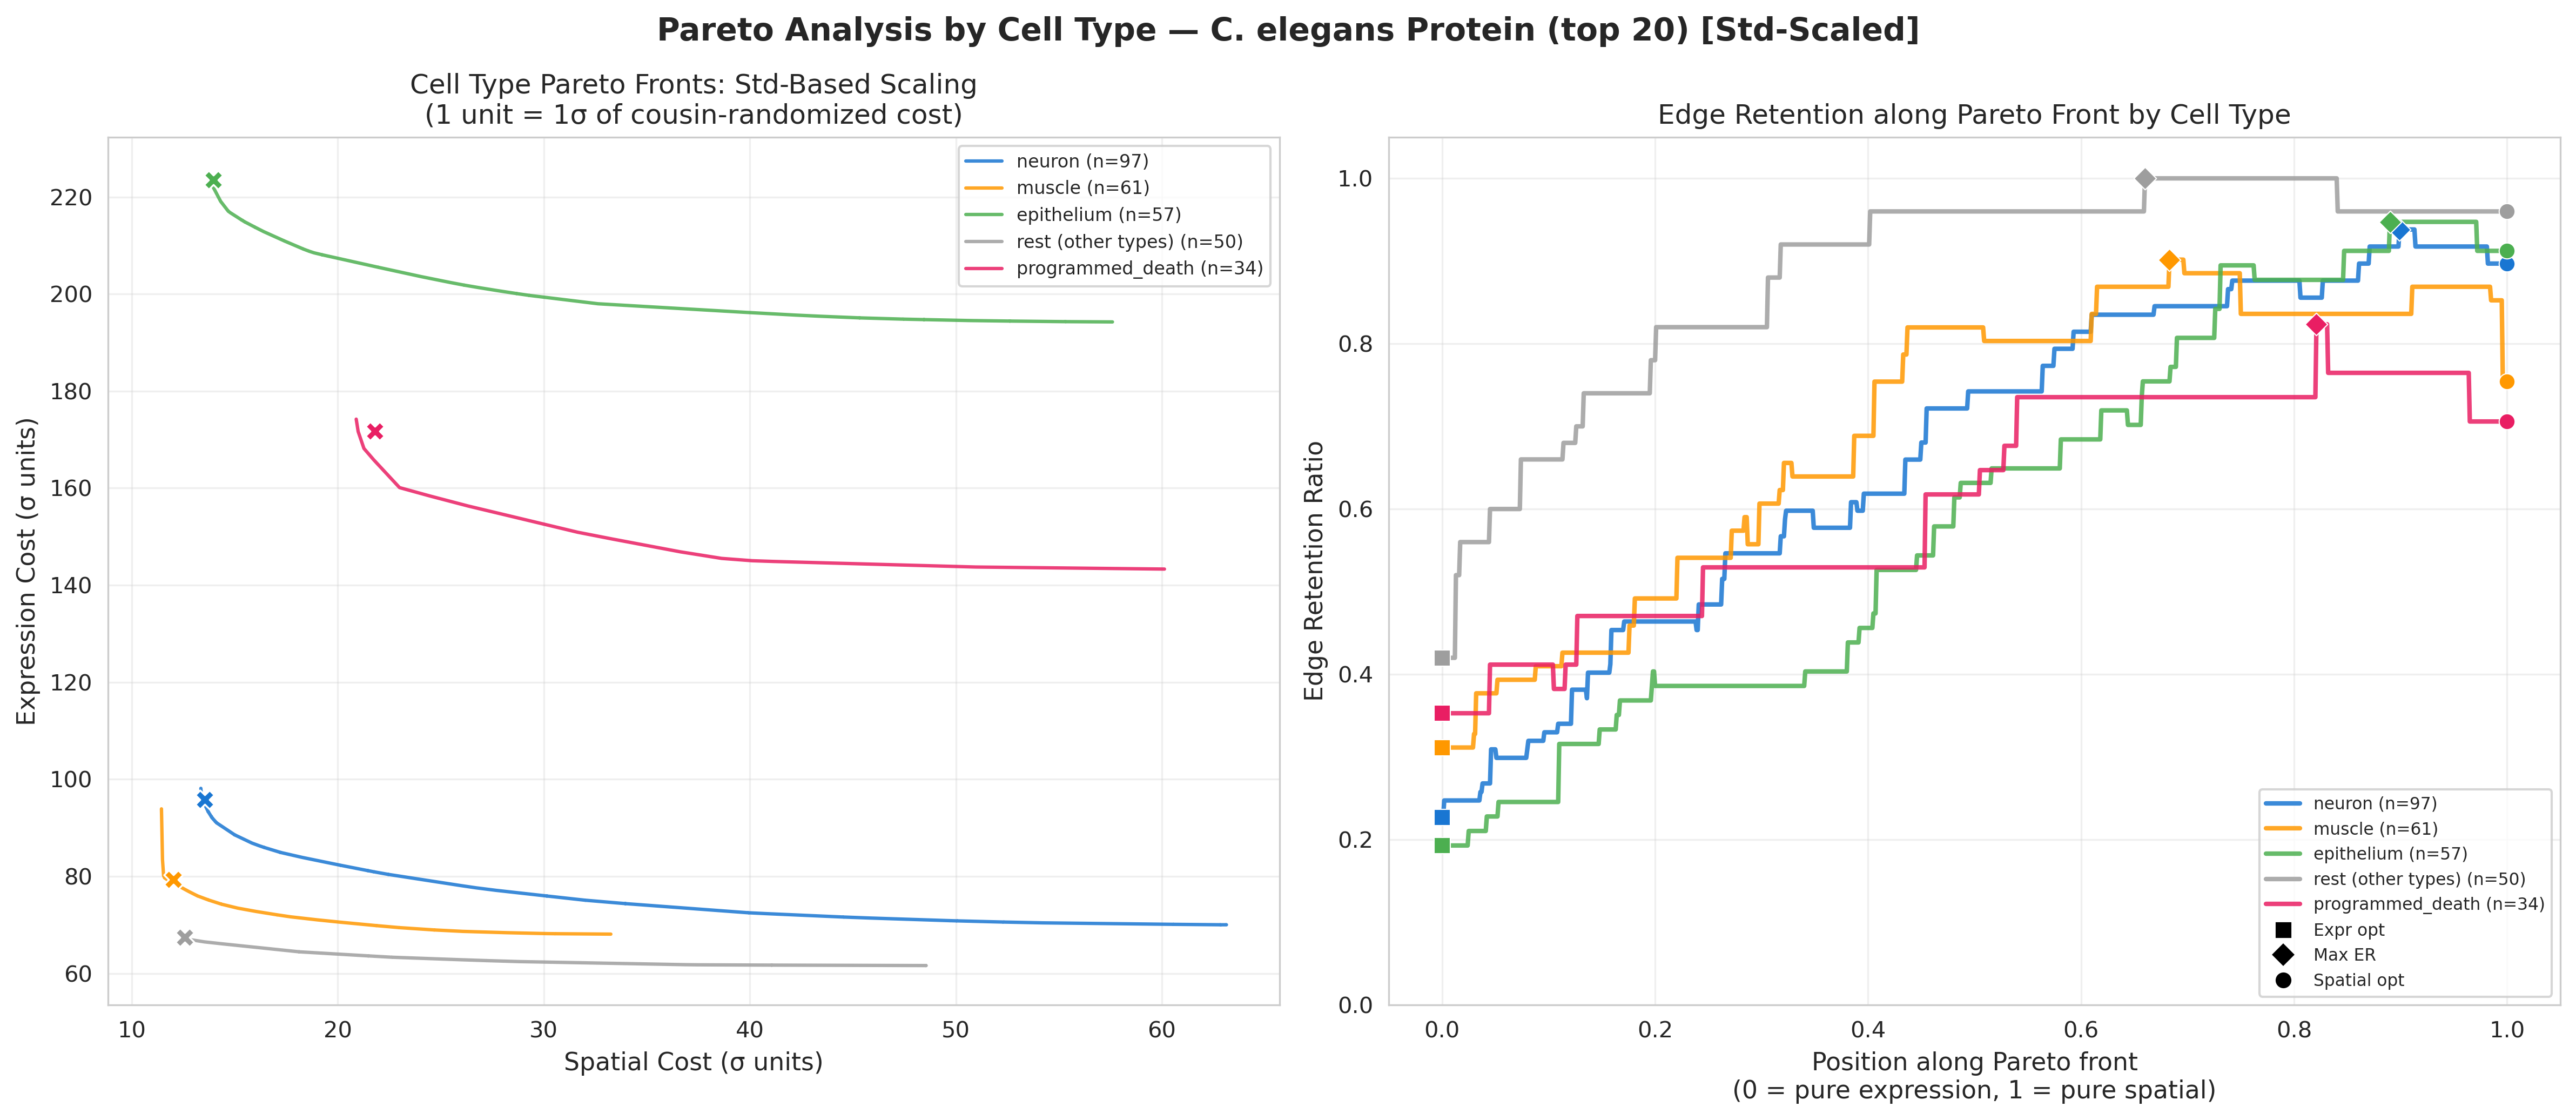

In [18]:
# ═══════════════════════════════════════════════════════════
# Std-Scaled Comparative Visualization
# Uses randomization-based normalization (units = σ of cousin-randomized costs)
# ═══════════════════════════════════════════════════════════

# Compute random stats for each analysis group
analysis_rs = {}
for label in analysis_labels:
    sr = analysis_results[label]
    tn = sr['term_data']['terminal_nodes']
    sub_groups = build_cousin_groups(tn, gp_map)
    analysis_rs[label] = compute_cousin_random_stats(
        sr['xyz_mat'], sr['exp_mat'], sub_groups, n_random=300, seed=42
    )
    print(f"  {label:20s}: n={len(tn):3d}, groups={len(sub_groups):2d}, "
          f"xyz_std={analysis_rs[label]['xyz_std']:.1f}, exp_std={analysis_rs[label]['exp_std']:.3f}")

# Compute std-scaled Pareto fronts
analysis_std = {}
for label in analysis_labels:
    sr = analysis_results[label]
    analysis_std[label] = compute_std_scaled_pareto(
        sr['xyz_mat'], sr['exp_mat'],
        sr['term_data']['terminal_parents'],
        analysis_rs[label]
    )

# ── Figure: 1 row × 2 columns (std-scaled) ──
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))
x_front = np.linspace(0, 1, 1001)

for label in analysis_labels:
    xyz_arr, exp_arr, edge_arr, key_pts = analysis_std[label]
    color = group_colors.get(label, 'gray')
    sr = analysis_results[label]
    n = len(sr['term_data']['terminal_nodes'])
    
    # Lineage position in std units
    lx = sr['xyz_mat'].diagonal().sum() / analysis_rs[label]['xyz_std']
    le = sr['exp_mat'].diagonal().sum() / analysis_rs[label]['exp_std']
    
    ax_left.plot(xyz_arr, exp_arr, color=color, linewidth=1.5, alpha=0.85,
                 label=f'{label} (n={n})')
    ax_left.scatter(lx, le, color=color, marker='X', s=70,
                    edgecolors='white', linewidth=0.8, zorder=6)
    
    ax_right.plot(x_front, edge_arr, color=color, linewidth=2, alpha=0.85,
                  label=f'{label} (n={n})')
    for pt_key, (marker, _) in _markers.items():
        idx = key_pts[pt_key]
        ax_right.scatter(x_front[idx], edge_arr[idx], color=color, marker=marker,
                        s=50, zorder=8, edgecolors='white', linewidth=0.5)

ax_left.set_xlabel('Spatial Cost (σ units)', fontsize=11)
ax_left.set_ylabel('Expression Cost (σ units)', fontsize=11)
ax_left.set_title(f'{analysis_title} Pareto Fronts: Std-Based Scaling\n(1 unit = 1σ of cousin-randomized cost)', fontsize=12)
ax_left.legend(fontsize=8, loc='upper right')
ax_left.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_lines = list(ax_right.get_lines()) + [
    Line2D([0], [0], color='black', marker='s', linestyle='', markersize=6, label='Expr opt'),
    Line2D([0], [0], color='black', marker='D', linestyle='', markersize=6, label='Max ER'),
    Line2D([0], [0], color='black', marker='o', linestyle='', markersize=6, label='Spatial opt'),
]
ax_right.legend(handles=legend_lines, fontsize=7.5, loc='best')
ax_right.set_xlabel('Position along Pareto front\n(0 = pure expression, 1 = pure spatial)', fontsize=11)
ax_right.set_ylabel('Edge Retention Ratio', fontsize=11)
ax_right.set_title(f'Edge Retention along Pareto Front by {analysis_title}', fontsize=12)
ax_right.set_ylim(0, 1.05)
ax_right.grid(True, alpha=0.3)

fig.suptitle(f'Pareto Analysis by {analysis_title} — C. elegans Protein (top 20) [Std-Scaled]',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


### 3b. Relaxed Parent Pool — Per-Type Analysis

For each cell type, compare the **type-restricted** Pareto front (only type-matched parents)
against a **relaxed** version where terminal cells can be assigned to **any** terminal parent
in the full tree. The relaxed version is an upper bound — it shows how much better the
assignment could be if we dropped the type constraint.

In [19]:
# ═══════════════════════════════════════════════════════════
# Relaxed parent pool: for each type, assign to ANY parent
# ═══════════════════════════════════════════════════════════
if ANALYSIS_MODE == 'cell_type':
    
    # Get ALL terminal parents from the full protein tree
    all_parents = list(dict.fromkeys(prot_data['terminal_parents']))
    
    relaxed_results = {}
    for gname in cell_type_results:
        d = cell_type_results[gname]
        gn = d['term_data']['terminal_nodes']  # terminal cells of this type
        gp = d['term_data']['terminal_parents']  # real parents of these cells
        n_type = len(gn)
        
        if n_type < 10:
            continue
        
        # Build rectangular cost matrix: n_parent_candidates x n_type_terminals
        # Initialize with large values to exclude invalid candidates
        BIG = 1e10
        xm_relax = np.full((len(all_parents), n_type), BIG)
        em_relax = np.full((len(all_parents), n_type), BIG)
        for i, parent_candidate in enumerate(all_parents):
            if parent_candidate not in all_xyz_map_elegans or parent_candidate not in protein_exp_full.index:
                continue  # skip parents without tracking or expression data
            for j, node in enumerate(gn):
                xm_relax[i, j] = np.linalg.norm(all_xyz_map_elegans[parent_candidate] - all_xyz_map_elegans[node])
                em_relax[i, j] = cosine(
                    protein_exp_full.loc[parent_candidate, protein_selected].values,
                    protein_exp_full.loc[node, protein_selected].values
                )
        
        # Normalize (min-max)
        xm_n = (xm_relax - xm_relax.min()) / (xm_relax.max() - xm_relax.min())
        em_n = (em_relax - em_relax.min()) / (em_relax.max() - em_relax.min())
        
        # Pareto sweep
        relaxed_edges = []
        for i in range(1001):
            a = i / 1000
            ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
            # Edge retention: fraction where assigned parent == real parent
            edges = 0
            for r, c in zip(ri, ci):
                if all_parents[r] == gp[c]:
                    edges += 1
            relaxed_edges.append(edges / n_type)
        
        relaxed_edges = np.array(relaxed_edges)
        # Also compute type-restricted edge ratios (recompute along front for consistency)
        xm_r, em_r = d['xyz_mat'], d['exp_mat']
        xm_rn = (xm_r - xm_r.min()) / (xm_r.max() - xm_r.min())
        em_rn = (em_r - em_r.min()) / (em_r.max() - em_r.min())
        restricted_edges = []
        for i in range(1001):
            a = i / 1000
            ri, ci = linear_sum_assignment(a * xm_rn + (1 - a) * em_rn)
            edges = sum(1 for r, c in zip(ri, ci) if gp[r] == gp[c]) / n_type
            restricted_edges.append(edges)
        
        relaxed_results[gname] = {
            'relaxed_edges': relaxed_edges,
            'restricted_edges': np.array(restricted_edges),
            'n': n_type,
            'restricted_res': d['pareto'],
        }
        
        rlx_max = relaxed_edges.max()
        rst_max = d['pareto']['largest_edge_ratio']
        print(f"  {gname:20s}: n={n_type:3d} | restricted Max ER={rst_max:.3f} | relaxed Max ER={rlx_max:.3f} | gain={rlx_max-rst_max:+.3f}")


  neuron              : n= 97 | restricted Max ER=0.938 | relaxed Max ER=0.629 | gain=-0.309


  muscle              : n= 61 | restricted Max ER=0.902 | relaxed Max ER=0.475 | gain=-0.426


  epithelium          : n= 57 | restricted Max ER=0.947 | relaxed Max ER=0.509 | gain=-0.439


  rest (other types)  : n= 50 | restricted Max ER=1.000 | relaxed Max ER=0.860 | gain=-0.140


  programmed_death    : n= 34 | restricted Max ER=0.824 | relaxed Max ER=0.529 | gain=-0.294


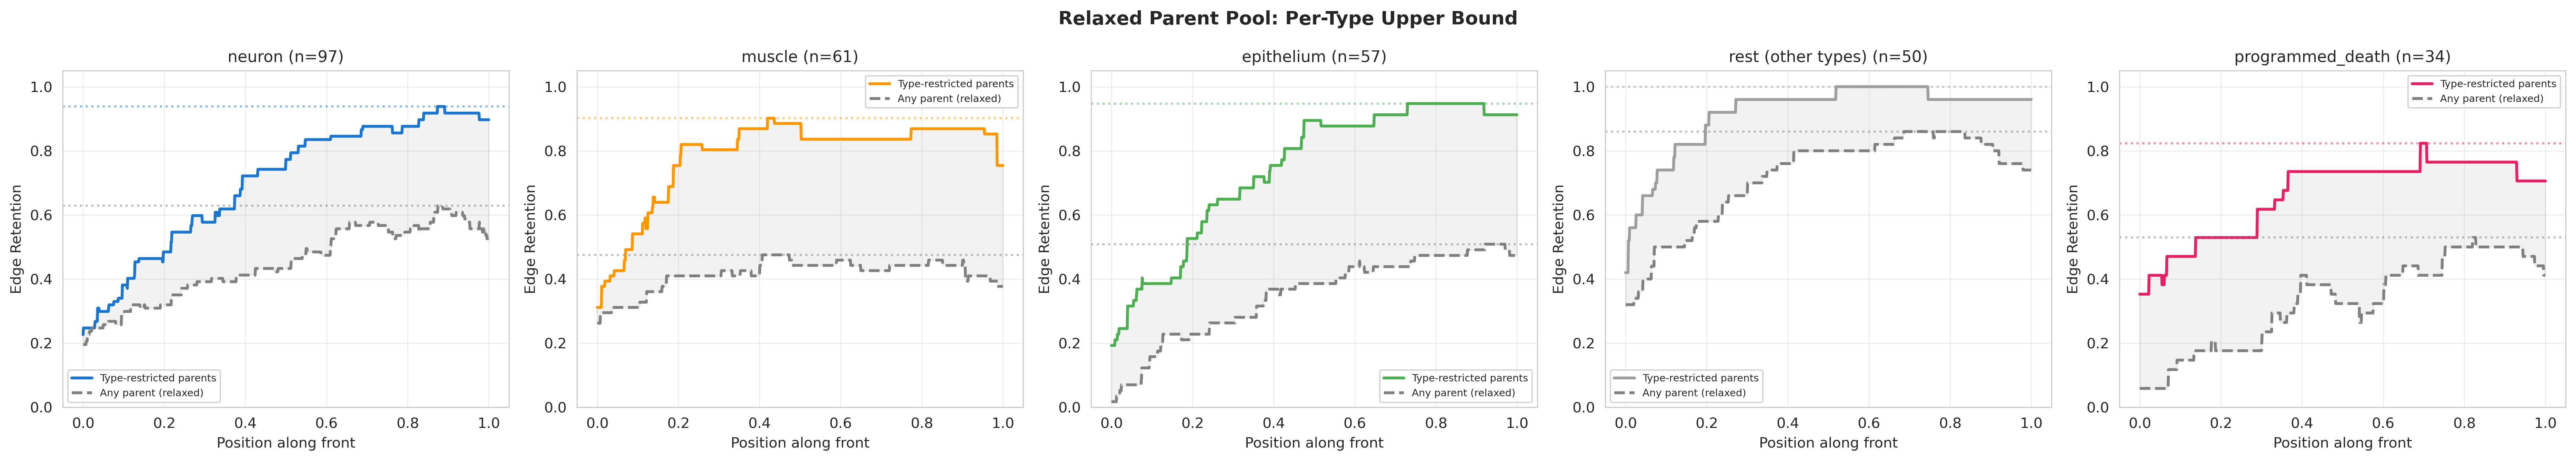

In [20]:
# ── Figure: Relaxed vs Restricted edge retention ──
if ANALYSIS_MODE == 'cell_type' and relaxed_results:
    fig, axes = plt.subplots(1, len(relaxed_results), figsize=(5*len(relaxed_results), 4.5))
    if len(relaxed_results) == 1:
        axes = [axes]
    
    for ax, (gname, rd) in zip(axes, relaxed_results.items()):
        xf = np.linspace(0, 1, 1001)
        color_restricted = group_colors.get(gname, 'gray')
        color_relaxed = 'gray'
        
        ax.plot(xf, rd['restricted_edges'], color=color_restricted, lw=2, label='Type-restricted parents')
        ax.plot(xf, rd['relaxed_edges'], color=color_relaxed, lw=2, ls='--', label='Any parent (relaxed)')
        ax.axhline(y=rd['restricted_res']['largest_edge_ratio'], color=color_restricted, ls=':', alpha=0.5)
        ax.axhline(y=rd['relaxed_edges'].max(), color=color_relaxed, ls=':', alpha=0.5)
        ax.fill_between(xf, rd['restricted_edges'], rd['relaxed_edges'], alpha=0.1, color='gray')
        ax.set_title(f'{gname} (n={rd["n"]})', fontsize=11)
        ax.set_xlabel('Position along front'); ax.set_ylabel('Edge Retention')
        ax.set_ylim(0, 1.05); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    
    fig.suptitle('Relaxed Parent Pool: Per-Type Upper Bound', fontsize=13, fontweight='bold')
    fig.tight_layout(); plt.show()


### 3c. Full-Tree Assignment Decomposed by Cell Type

Take the full-tree Pareto front assignment and compute per-type edge retention.
This shows which cell types' lineage edges are preserved vs. sacrificed in the
global optimum (where all cells compete for parents simultaneously).

In [21]:
# ── Decompose full-tree Pareto front by cell type (grouped) ──
if ANALYSIS_MODE == 'cell_type':
    
    xm_full = xyz_cost_prot; em_full = all_exp_cost_prot
    tp_full = prot_data['terminal_parents']; tn_full = prot_data['terminal_nodes']
    
    # Map terminal cells to merged types (use get_cell_type from shared definitions)
    full_node_type = {}
    for n in tn_full:
        full_node_type[n] = get_cell_type(n)
    
    # Group: neuron, muscle, epithelium, programmed_death, rest
    MAJOR_TYPES = {'neuron', 'muscle', 'epithelium', 'programmed_death'}
    full_type_groups = defaultdict(list)
    for i, (node, parent) in enumerate(zip(tn_full, tp_full)):
        ct = full_node_type.get(node, 'programmed_death')
        group = ct if ct in MAJOR_TYPES else 'rest (other types)'
        full_type_groups[group].append(i)
    
    print("Group sizes:")
    for ct in sorted(full_type_groups, key=lambda c: -len(full_type_groups[c])):
        print(f"  {ct:20s}: {len(full_type_groups[ct]):3d}")
    
    # Normalize cost matrices
    xm_n = (xm_full - xm_full.min()) / (xm_full.max() - xm_full.min())
    em_n = (em_full - em_full.min()) / (em_full.max() - em_full.min())
    
    # Find key alpha points
    best_er, best_alpha = 0, 0
    for i in range(1001):
        a = i/1000; ri, ci = linear_sum_assignment(a*xm_n + (1-a)*em_n)
        er = sum(1 for r,c in zip(ri,ci) if tp_full[r]==tp_full[c]) / len(tp_full)
        if er > best_er: best_er, best_alpha = er, i
    key_alphas = {'Expr opt (a=0)': 0, 'Max ER': best_alpha, 'Spatial opt (a=1)': 1000}
    
    decomp_results = {}
    for label, alpha_idx in key_alphas.items():
        a = alpha_idx / 1000
        ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
        type_er = {}
        for ct, indices in full_type_groups.items():
            edges = sum(1 for idx in indices if tp_full[ri[idx]] == tp_full[ci[idx]])
            type_er[ct] = edges / len(indices) if len(indices) > 0 else 0
        decomp_results[label] = {'alpha_idx': alpha_idx, 'type_er': type_er, 'row_ind': ri, 'col_ind': ci}
    
    # Table
    overall_er = {k: sum(1 for r,c in zip(v['row_ind'],v['col_ind']) if tp_full[r]==tp_full[c])/len(tp_full)
                  for k,v in decomp_results.items()}
    print(f"\nOverall ER: Expr opt={overall_er['Expr opt (a=0)']:.3f}, Max ER={overall_er['Max ER']:.3f}, Spatial opt={overall_er['Spatial opt (a=1)']:.3f}")
    print()
    
    decomp_rows = []
    for ct in sorted(full_type_groups, key=lambda c: -len(full_type_groups[c])):
        n = len(full_type_groups[ct])
        decomp_rows.append({
            'Cell Type': ct, 'N': n,
            'Expr opt ER': round(decomp_results['Expr opt (a=0)']['type_er'][ct], 3),
            'Max ER point': round(decomp_results['Max ER']['type_er'][ct], 3),
            'Spatial opt ER': round(decomp_results['Spatial opt (a=1)']['type_er'][ct], 3),
        })
    decomp_df = pd.DataFrame(decomp_rows).set_index('Cell Type')
    decomp_df


Group sizes:
  neuron              :  97
  muscle              :  61
  epithelium          :  57
  rest (other types)  :  50
  programmed_death    :  34



Overall ER: Expr opt=0.204, Max ER=0.819, Spatial opt=0.599



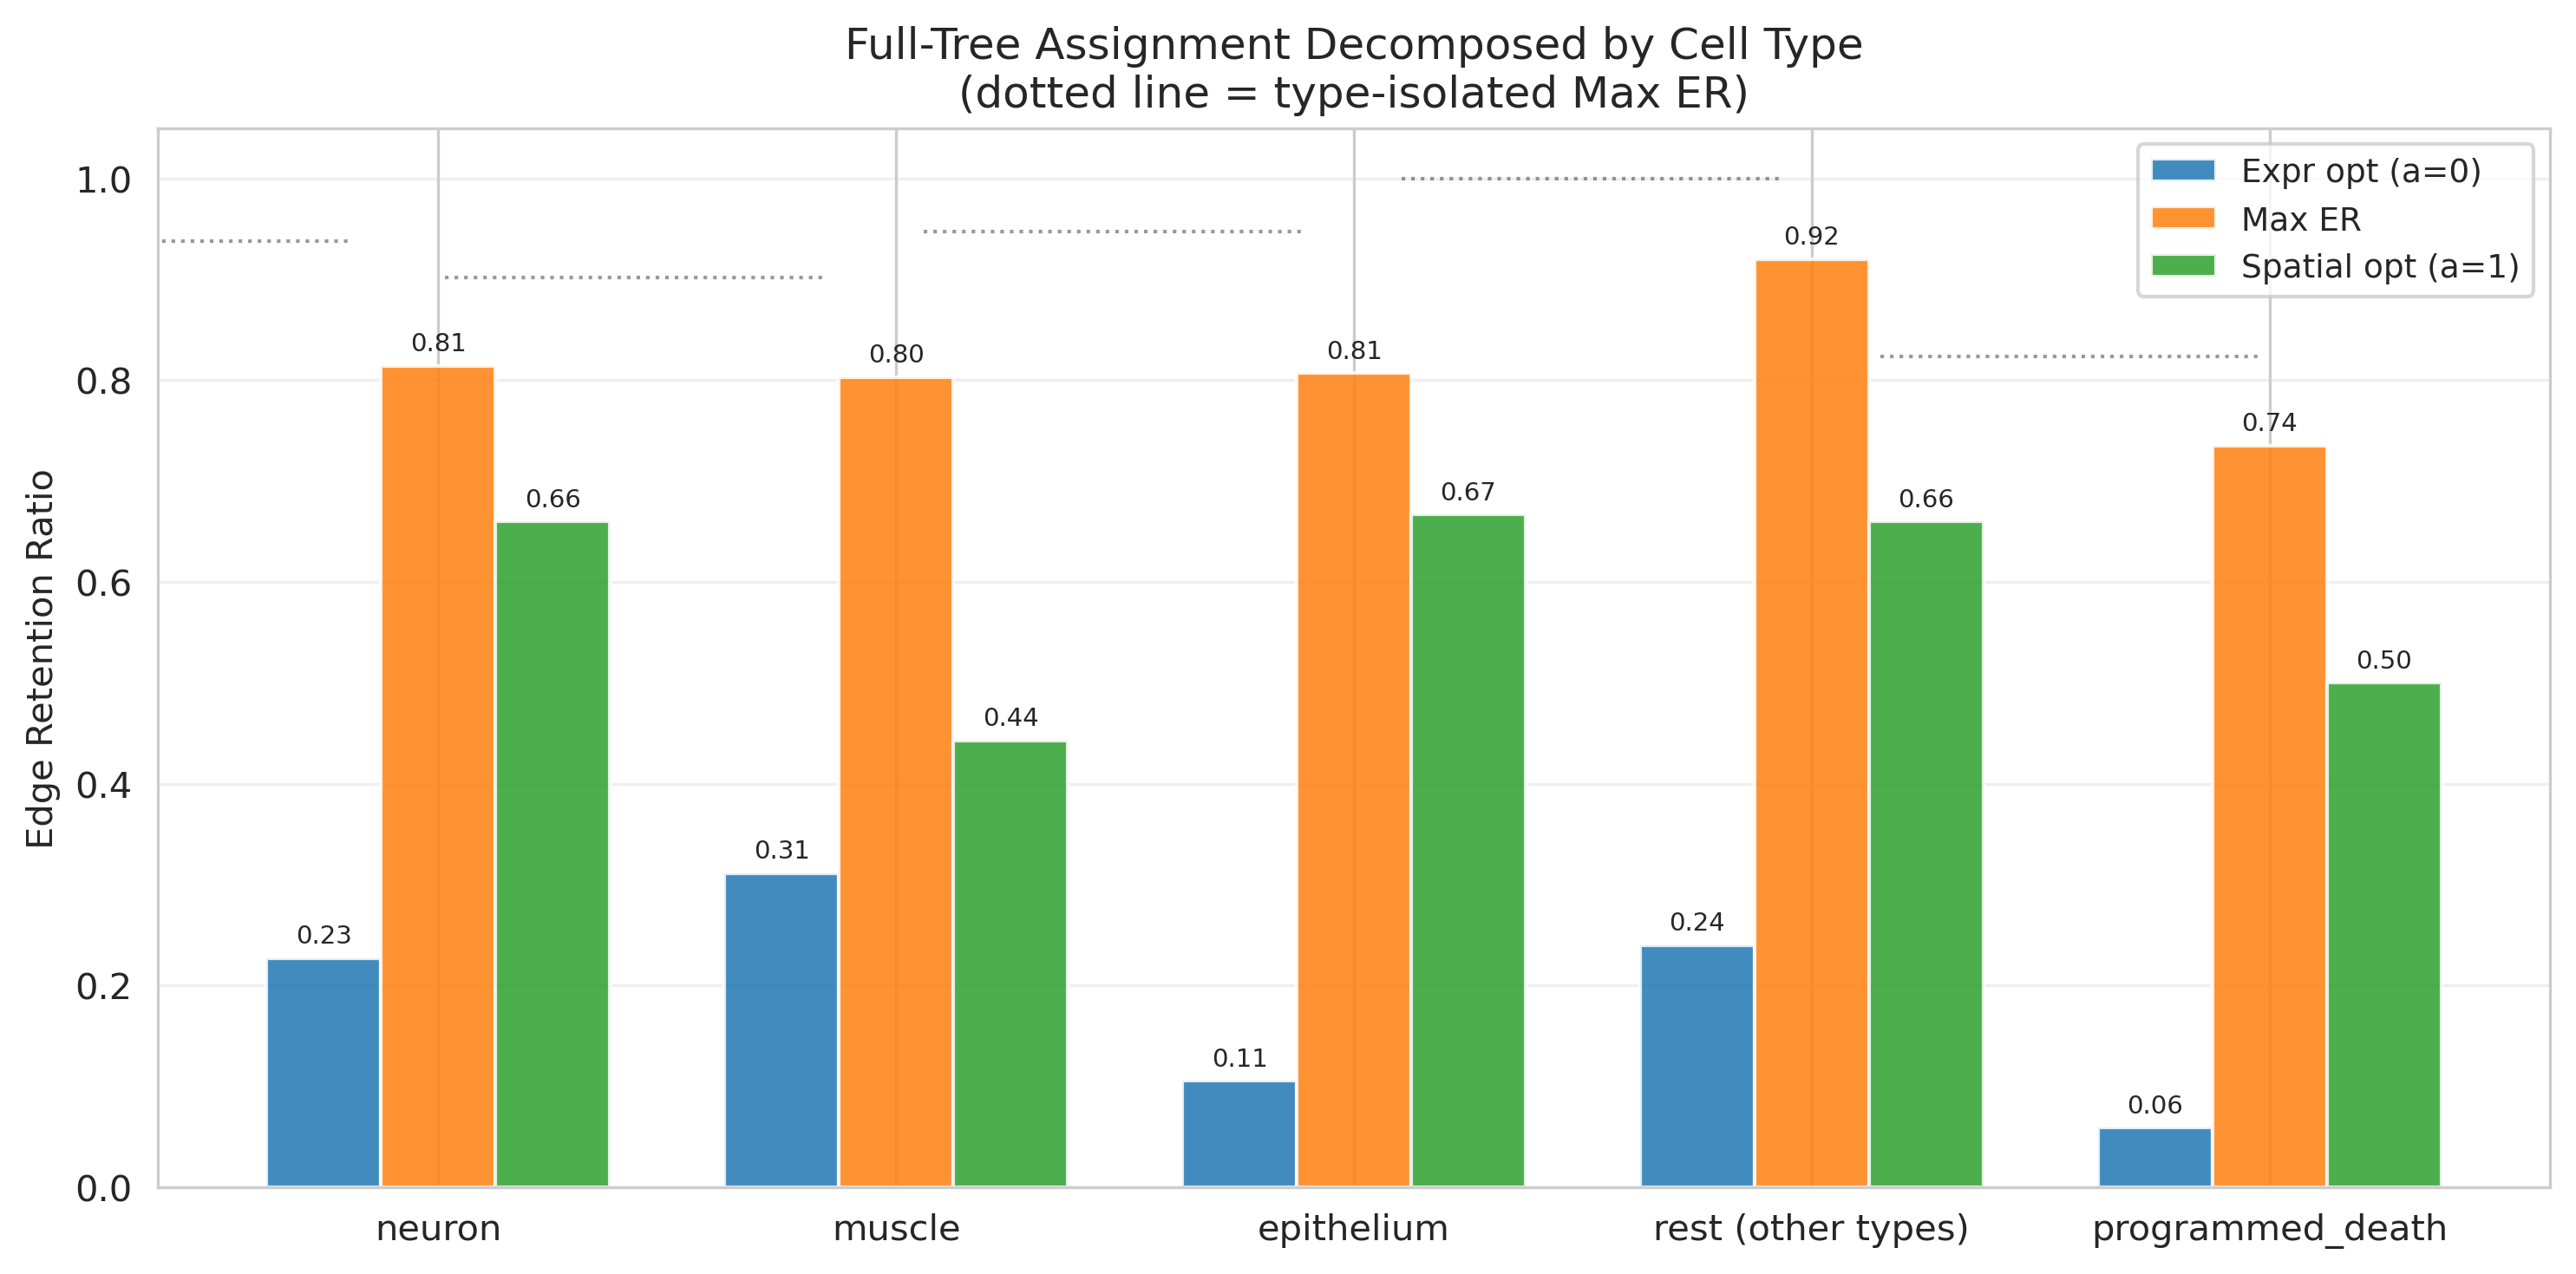

In [22]:
# ── Figure 1: Per-type edge retention in global assignment (bar chart) ──
if ANALYSIS_MODE == 'cell_type':
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    types_ordered = sorted(full_type_groups, key=lambda c: -len(full_type_groups[c]))
    x = np.arange(len(types_ordered))
    w = 0.25
    
    for i, (label, alpha_idx) in enumerate(key_alphas.items()):
        ers = [decomp_results[label]['type_er'][ct] for ct in types_ordered]
        bars = ax.bar(x + i*w - w, ers, w, label=label, alpha=0.85)
        for bar, er in zip(bars, ers):
            if er > 0.05:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{er:.2f}', ha='center', va='bottom', fontsize=7)
    
    # Reference: per-type isolated Max ER (dotted lines)
    for i, ct in enumerate(types_ordered):
        if ct in cell_type_results:
            ref_er = cell_type_results[ct]['pareto']['largest_edge_ratio']
        elif ct == 'rest (other types)':
            ref_er = cell_type_results['rest (other types)']['pareto']['largest_edge_ratio']
        else:
            ref_er = None
        if ref_er is not None:
            ax.axhline(y=ref_er, xmin=(i-0.4)/len(types_ordered),
                       xmax=(i+0.4)/len(types_ordered), color='black', ls=':', alpha=0.4, lw=1)
    
    ax.set_xticks(x); ax.set_xticklabels(types_ordered, fontsize=10)
    ax.set_ylabel('Edge Retention Ratio'); ax.set_ylim(0, 1.05)
    ax.set_title('Full-Tree Assignment Decomposed by Cell Type\n(dotted line = type-isolated Max ER)', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    fig.tight_layout(); plt.show()


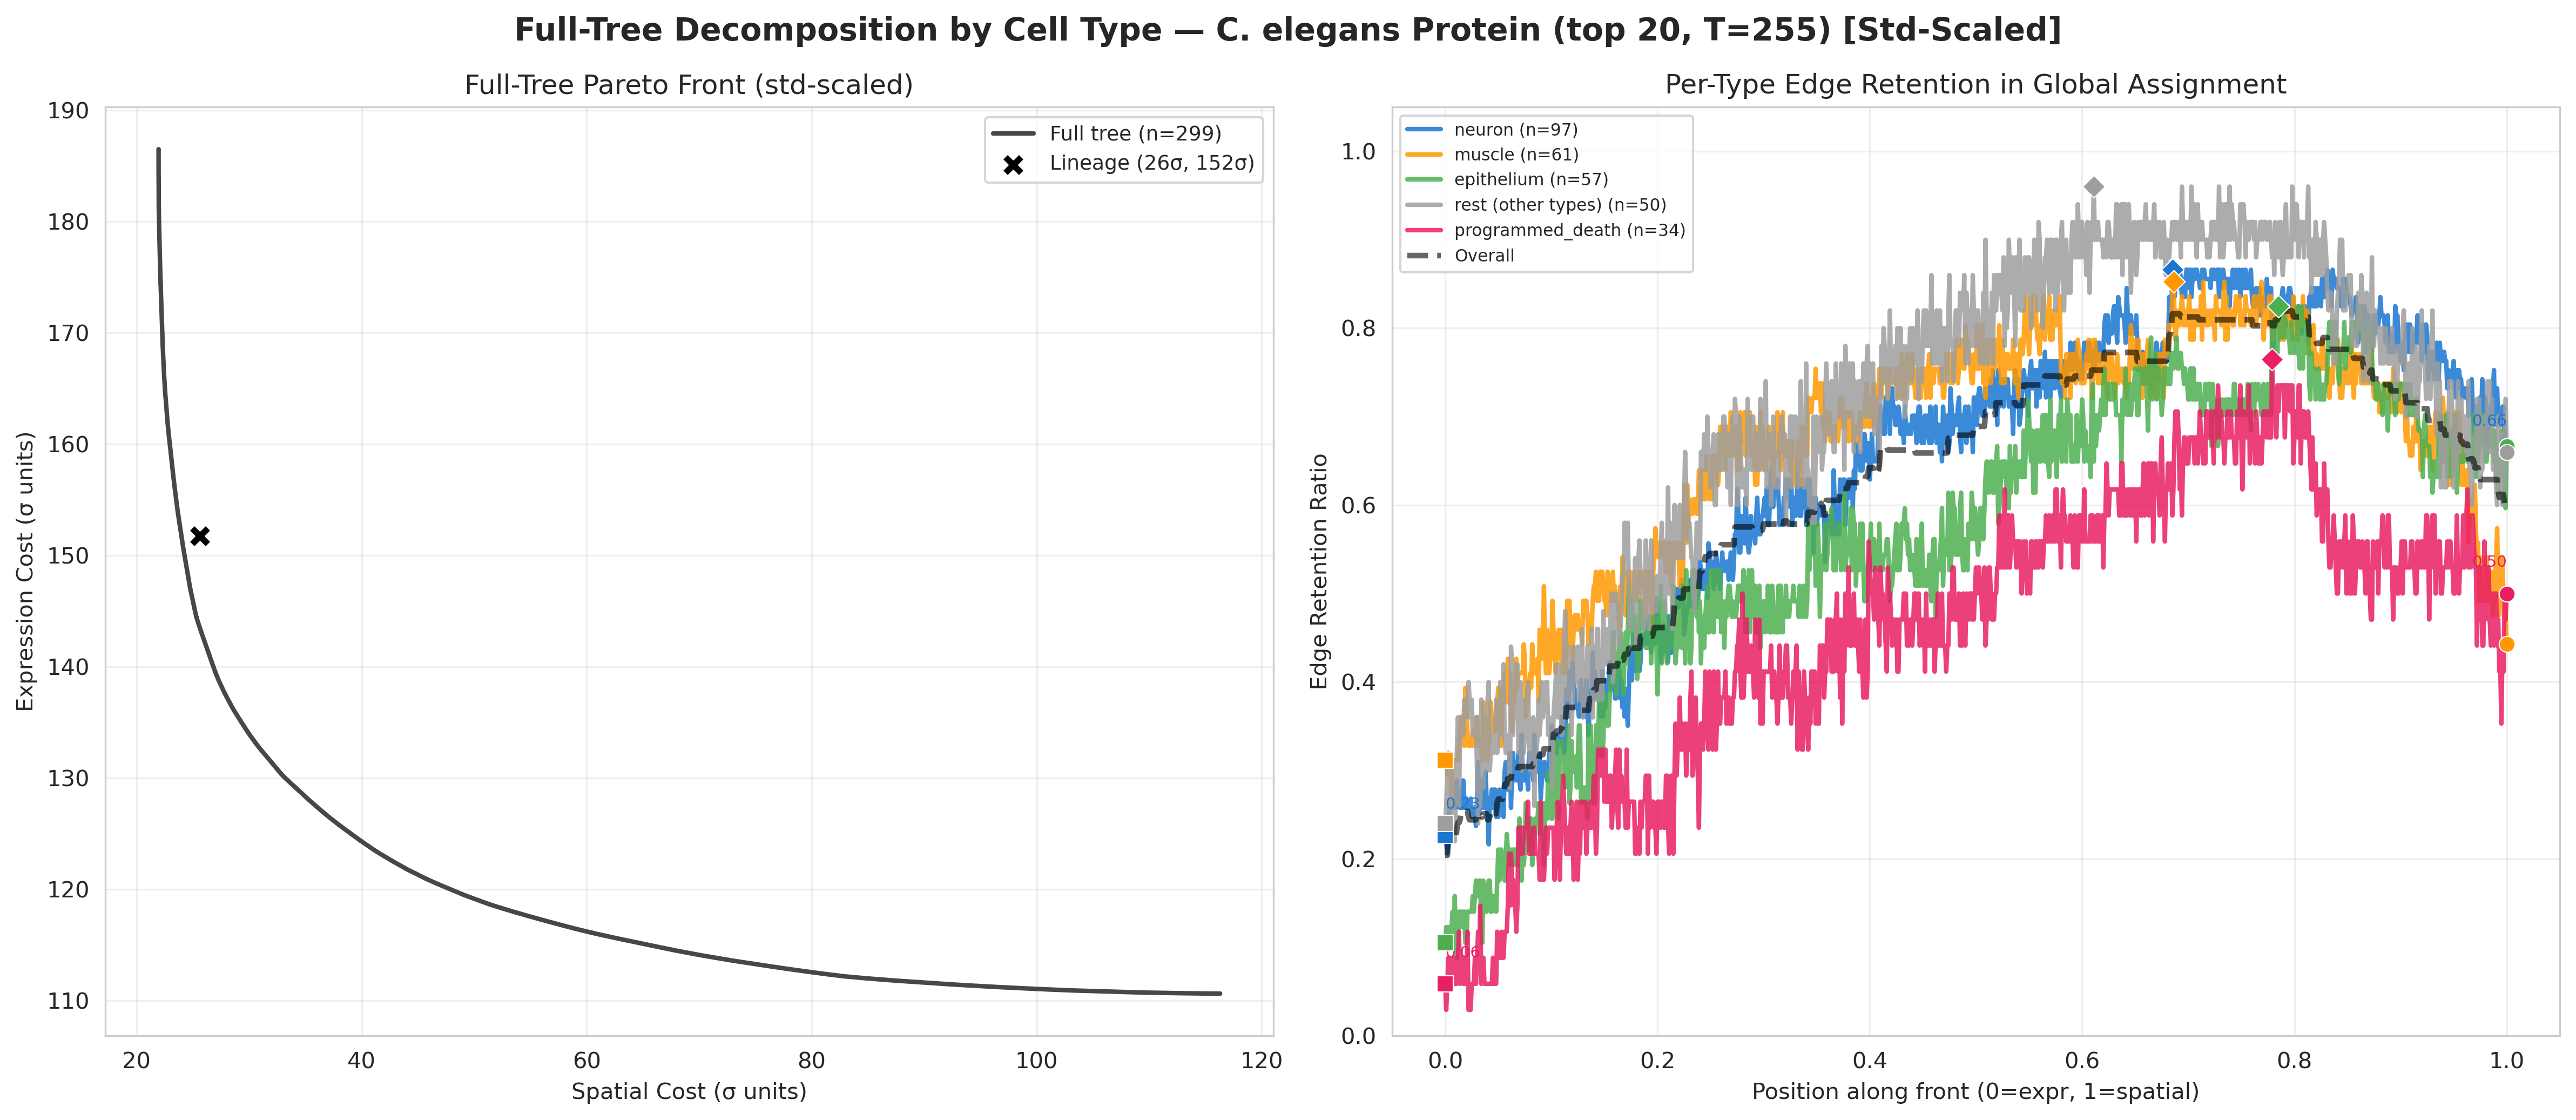

In [23]:
# ── Figure 2: Full-tree Pareto front + per-type edge retention curves (std-scaled) ──
if ANALYSIS_MODE == 'cell_type':
    
    type_list = sorted(full_type_groups, key=lambda c: -len(full_type_groups[c]))
    
    # Compute std-scaled Pareto front for the full tree
    xyz_arr, exp_arr, __, ___ = compute_std_scaled_pareto(xm_full, em_full, tp_full, prot_random_stats)
    
    # Lineage position in std units
    lx = xm_full.diagonal().sum() / prot_random_stats['xyz_std']
    le = em_full.diagonal().sum() / prot_random_stats['exp_std']
    
    # Compute per-type edge retention at each alpha
    per_type_edges = {ct: [] for ct in type_list}
    for i in range(1001):
        a = i / 1000
        ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
        for ct, indices in full_type_groups.items():
            edges = sum(1 for idx in indices if tp_full[ri[idx]] == tp_full[ci[idx]])
            per_type_edges[ct].append(edges / len(indices))
    
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
    x_front = np.linspace(0, 1, 1001)
    
    # ── LEFT: Full-tree Pareto front (std-scaled) ──
    ax_l.plot(xyz_arr, exp_arr, color='#333333', lw=2, alpha=0.9, label=f'Full tree (n={len(tn_full)})')
    ax_l.scatter(lx, le, color='black', marker='X', s=100, edgecolors='white', lw=0.8, zorder=10,
                label=f'Lineage ({lx:.0f}σ, {le:.0f}σ)')
    ax_l.set_xlabel('Spatial Cost (σ units)'); ax_l.set_ylabel('Expression Cost (σ units)')
    ax_l.set_title('Full-Tree Pareto Front (std-scaled)', fontsize=12)
    ax_l.legend(fontsize=9, loc='upper right'); ax_l.grid(True, alpha=0.3)
    
    # ── RIGHT: Per-type edge retention along the full-tree front ──
    for ct in type_list:
        color = group_colors.get(ct, 'gray')
        edges = np.array(per_type_edges[ct])
        ax_r.plot(x_front, edges, color=color, lw=2, alpha=0.85, label=f'{ct} (n={len(full_type_groups[ct])})')
        ax_r.scatter(0, edges[0], color=color, marker='s', s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_r.scatter(1, edges[-1], color=color, marker='o', s=50, zorder=8, edgecolors='white', lw=0.5)
        max_idx = np.argmax(edges)
        ax_r.scatter(x_front[max_idx], edges[max_idx], color=color, marker='D', s=50, zorder=8, edgecolors='white', lw=0.5)
        if ct in ['neuron', 'programmed_death']:
            ax_r.annotate(f'{edges[0]:.2f}', (0, edges[0]+0.03), color=color, fontsize=7, ha='left')
            ax_r.annotate(f'{edges[-1]:.2f}', (1, edges[-1]+0.03), color=color, fontsize=7, ha='right')
    
    # Overall edge retention (dashed black)
    overall_edges = []
    for i in range(1001):
        a = i/1000; ri, ci = linear_sum_assignment(a*xm_n + (1-a)*em_n)
        overall_edges.append(sum(1 for r,c in zip(ri,ci) if tp_full[r]==tp_full[c]) / len(tp_full))
    ax_r.plot(x_front, overall_edges, color='black', lw=2.5, ls='--', alpha=0.6, label='Overall')
    
    ax_r.set_xlabel('Position along front (0=expr, 1=spatial)'); ax_r.set_ylabel('Edge Retention Ratio')
    ax_r.set_title('Per-Type Edge Retention in Global Assignment', fontsize=12)
    ax_r.set_ylim(0, 1.05); ax_r.grid(True, alpha=0.3)
    ax_r.legend(fontsize=7.5, loc='best')
    
    fig.suptitle('Full-Tree Decomposition by Cell Type — C. elegans Protein (top 20, T=255) [Std-Scaled]',
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()


---
## Extended Subtree Analysis — C. elegans Protein (top 20)

All lineage subtrees with more than 10 terminal cells (with protein + tracking data).
For each subtree, we compute the Pareto metrics and annotate with the **dominant cell type**
and its fraction — this reveals whether subtrees dominated by a single cell type behave differently.

In [24]:
# ═══════════════════════════════════════════════════════
# Enumerate all subtrees with >10 terminal cells
# ═══════════════════════════════════════════════════════

# Post-order DFS: for each node, collect its terminal descendants
# that have both tracking and protein expression data.
terminal_descendants = {}  # node_name -> [(terminal_name, parent_name), ...]

def postorder_collect(node, parent=None):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    my_terminals = []

    if len(children) == 0:
        # Terminal cell
        p_lookup_name = map_names(parent['did']) if parent else None
        if (lookup_name in valid_cell_names_protein and
            p_lookup_name in valid_cell_names_protein):
            my_terminals.append((lookup_name, p_lookup_name))
    else:
        for child in children:
            my_terminals.extend(postorder_collect(child, node))

    terminal_descendants[lookup_name] = my_terminals
    return my_terminals

postorder_collect(lineage_data)
print(f"Enumerated {len(terminal_descendants)} nodes, "
      f"{sum(1 for v in terminal_descendants.values() if len(v) > 0)} have terminal descendants")

# Filter: subtrees with >10 terminal cells
MIN_TERMINALS = 10
qualifying = [(name, terms) for name, terms in terminal_descendants.items()
              if len(terms) >= MIN_TERMINALS]
qualifying.sort(key=lambda x: -len(x[1]))  # sort by count descending
print(f"Subtrees with >{MIN_TERMINALS} terminal cells: {len(qualifying)}")

# ── Run Pareto for each qualified subtree ──
ext_subtree_results = {}

for subtree_name, term_list in qualifying:
    tn = [t[0] for t in term_list]
    tp = [t[1] for t in term_list]
    n = len(tn)

    # Cell type composition
    type_counts = defaultdict(int)
    for node in tn:
        type_counts[get_cell_type(node)] += 1
    dominant_type = max(type_counts, key=type_counts.get)
    dominant_frac = type_counts[dominant_type] / n

    # Build cost matrices & run Pareto
    xm, em, _, _ = build_cost_matrices(tn, tp, all_xyz_map_elegans, protein_exp_full, selected_features=protein_selected)
    res = pareto_calculate(xm, em, tp, plot_figure=False)

    ext_subtree_results[subtree_name] = {
        'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res,
        'n': n, 'dominant_type': dominant_type, 'dominant_frac': dominant_frac,
        'type_dist': dict(type_counts),
    }

print(f"\nRan Pareto for {len(ext_subtree_results)} subtrees")


Enumerated 2183 nodes, 733 have terminal descendants
Subtrees with >10 terminal cells: 49



Ran Pareto for 49 subtrees


In [25]:
# ── Extended subtree summary table ──

ext_rows = []
for name in sorted(ext_subtree_results, key=lambda k: -ext_subtree_results[k]['n']):
    d = ext_subtree_results[name]
    r = d['res']
    # Format type distribution as a compact string
    type_str = ', '.join(f'{t}({c})' for t, c in sorted(d['type_dist'].items(), key=lambda x: -x[1])[:3])

    ext_rows.append({
        'Subtree': name,
        'N': d['n'],
        'Expr Opt ER': round(r['optimal_exp_edge_ratio'], 3),
        'Max ER': round(r['largest_edge_ratio'], 3),
        'Spatial Opt ER': round(r['optimal_xyz_edge_ratio'], 3),
        'Closest Dist': round(r['closest_distance'], 3),
        'Dominant Type': d['dominant_type'],
        'Dom. Frac': round(d['dominant_frac'], 2),
        'Top 3 Types': type_str,
    })

ext_df = pd.DataFrame(ext_rows).set_index('Subtree')
print(f"Total subtrees: {len(ext_df)}")
ext_df


Total subtrees: 49


,N,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist,Dominant Type,Dom. Frac,Top 3 Types
Subtree,,,,,,,,
P0,299,0.204,0.819,0.599,1.132,neuron,0.32,"neuron(97), muscle(61), epithelium(57)"
AB,216,0.218,0.838,0.671,0.464,neuron,0.44,"neuron(95), epithelium(44), programmed_death(27)"
ABp,110,0.245,0.882,0.773,0.348,neuron,0.54,"neuron(59), epithelium(24), programmed_death(12)"
ABa,106,0.302,0.887,0.679,0.175,neuron,0.34,"neuron(36), epithelium(20), programmed_death(15)"
P1,83,0.337,0.880,0.771,0.191,muscle,0.59,"muscle(49), epithelium(13), alimentary(9)"
ABpr,60,0.367,0.867,0.800,0.262,neuron,0.62,"neuron(37), epithelium(9), programmed_death(6)"
ABal,59,0.424,0.932,0.780,0.273,neuron,0.44,"neuron(26), programmed_death(11), glial(9)"
EMS,55,0.327,0.909,0.800,0.114,muscle,0.67,"muscle(37), alimentary(9), programmed_death(7)"
MS,53,0.302,0.906,0.792,0.114,muscle,0.70,"muscle(37), alimentary(7), programmed_death(7)"


In [26]:
# ── Highlight subtrees dominated (>70%) by a single cell type ──
dominated = ext_df[ext_df['Dom. Frac'] >= 0.7].sort_values('Dom. Frac', ascending=False)
print(f"Subtrees with >70% single cell type: {len(dominated)}")
print()
dominated[['N', 'Expr Opt ER', 'Max ER', 'Spatial Opt ER', 'Dominant Type', 'Dom. Frac']]


Subtrees with >70% single cell type: 17



,N,Expr Opt ER,Max ER,Spatial Opt ER,Dominant Type,Dom. Frac
Subtree,,,,,,
D,12,0.417,0.833,0.833,muscle,1.00
C,14,0.286,0.786,0.786,epithelium,0.93
ABprpaa,11,0.636,1.000,0.818,neuron,0.91
ABplpaa,10,1.000,1.000,1.000,neuron,0.90
P3,14,0.500,0.857,0.857,muscle,0.86
ABprpa,27,0.556,0.926,0.852,neuron,0.85
ABarpa,11,0.364,1.000,0.818,epithelium,0.82
ABprpap,16,0.500,0.875,0.875,neuron,0.81
ABarapp,10,0.600,1.000,1.000,neuron,0.80


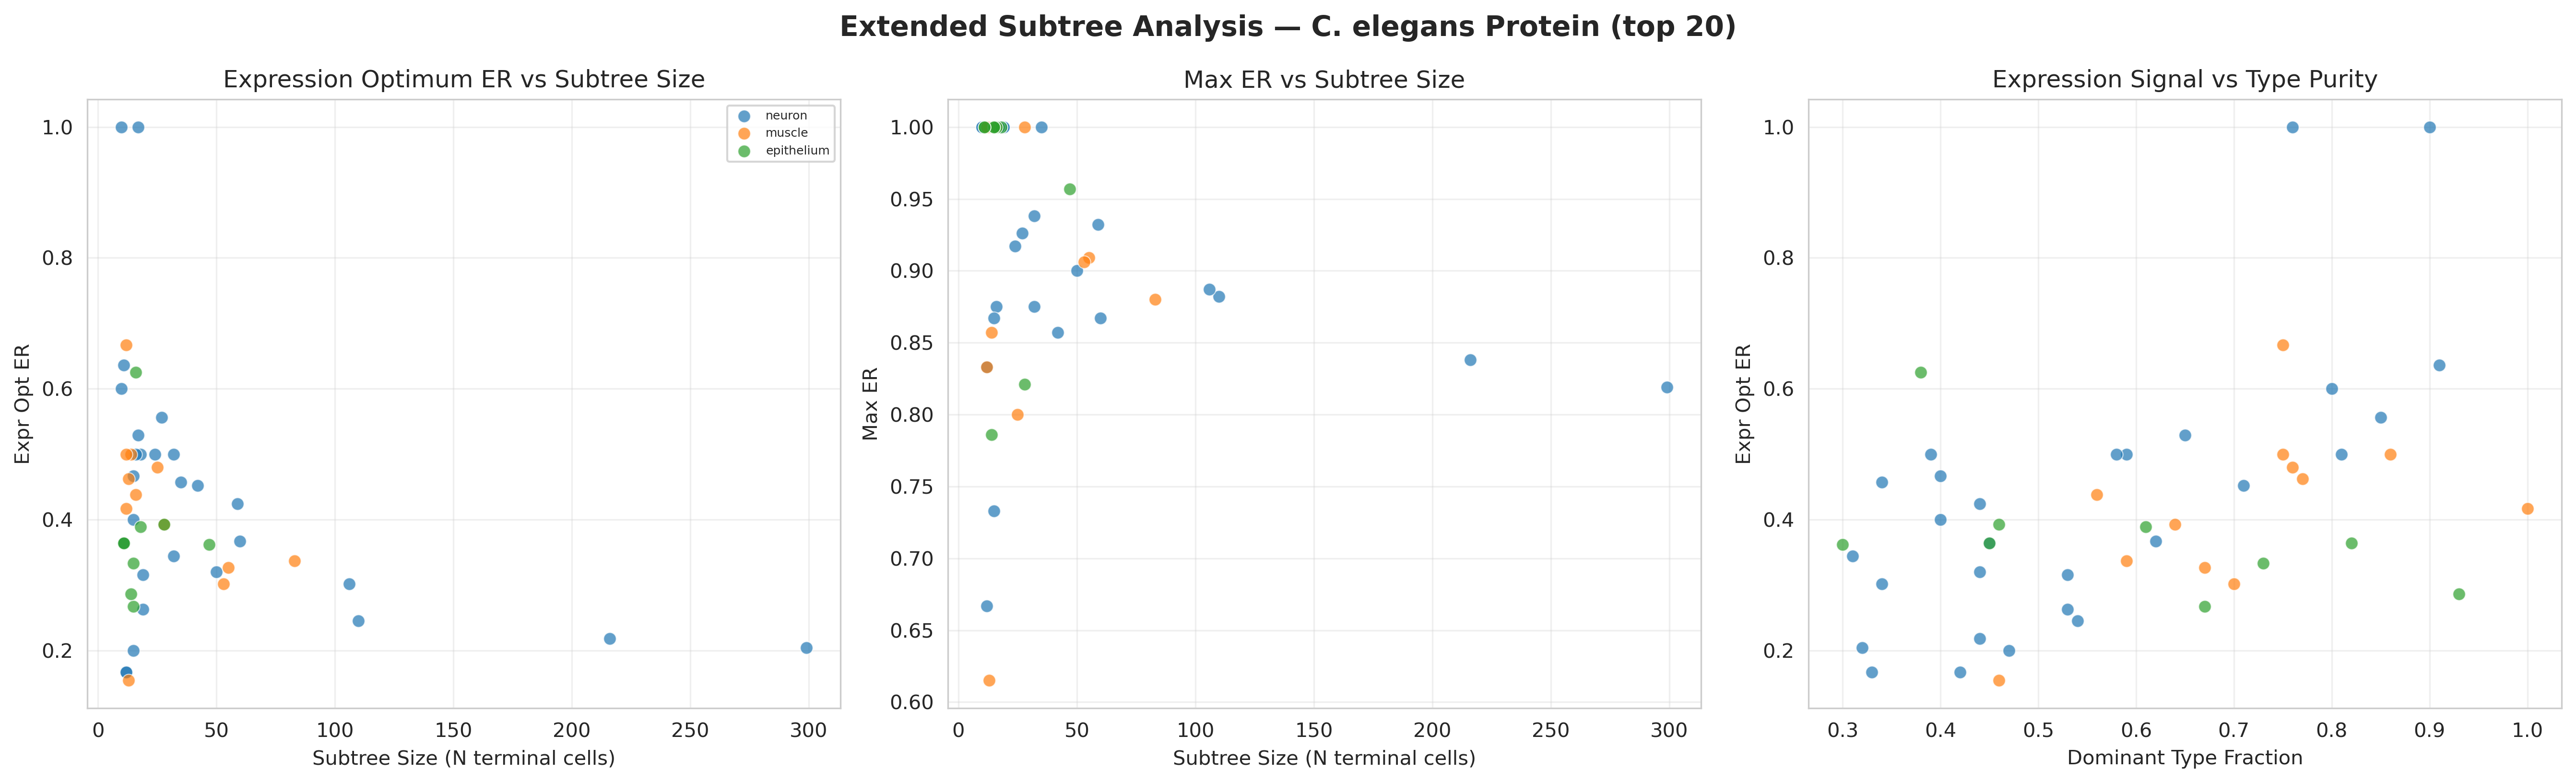

In [27]:
# ── Scatter: how Pareto metrics vary with subtree size & dominant type ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Color by dominant type
type_list = ext_df['Dominant Type'].unique()
type_colors = {t: plt.cm.tab10(i % 10) for i, t in enumerate(type_list)}

# 1) Expr Opt ER vs N
ax = axes[0]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Expr Opt ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Subtree Size (N terminal cells)'); ax.set_ylabel('Expr Opt ER')
ax.set_title('Expression Optimum ER vs Subtree Size'); ax.legend(fontsize=6, loc='best')
ax.grid(True, alpha=0.3)

# 2) Max ER vs N
ax = axes[1]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Max ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Subtree Size (N terminal cells)'); ax.set_ylabel('Max ER')
ax.set_title('Max ER vs Subtree Size'); ax.grid(True, alpha=0.3)

# 3) Expr Opt ER vs Dom. Frac
ax = axes[2]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'Dom. Frac'], ext_df.loc[mask, 'Expr Opt ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Dominant Type Fraction'); ax.set_ylabel('Expr Opt ER')
ax.set_title('Expression Signal vs Type Purity'); ax.grid(True, alpha=0.3)

fig.suptitle('Extended Subtree Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout(); plt.show()


---
## C. elegans — RNA-seq Expression


In [28]:
# ═══════════════════════════════════════════════════════
# C. ELEGANS RNA-SEQ
# ═══════════════════════════════════════════════════════

# ── Load RNA expression (shared TF features) ──
elegans_rna_full = pd.read_csv(
    "data/c_briggsae/science.adu8249/c_elegans_tf.csv", index_col=0
).T

rna_selected_features = pd.read_csv(
    'expression_embedding/results/cross_species_rna_linear/rna_selected_features.tsv',
    names=['tf'], sep='\t'
)['tf'].tolist()

print(f"C. elegans RNA expression: {elegans_rna_full.shape[0]} cells × {elegans_rna_full.shape[1]} TFs")
print(f"Shared top 20 TFs: {rna_selected_features}")

# Filter valid cells
valid_cell_names_elegans_rna = [n for n in valid_cell_names_elegans if n in elegans_rna_full.index]
print(f"Valid cells with RNA data: {len(valid_cell_names_elegans_rna)}")


C. elegans RNA expression: 1063 cells × 261 TFs
Shared top 20 TFs: ['pax-1', 'nhr-25', 'unc-120', 'lin-26', 'ceh-44', 'ceh-22', 'hnd-1', 'M03D4.4', 'unc-30', 'elt-1', 'pros-1', 'pha-4', 'nhr-49', 'egl-46', 'odd-2', 'ceh-31', 'nhr-186', 'hlh-8', 'ttx-1', 'tbx-8']
Valid cells with RNA data: 853


In [29]:
# ── Collect terminal cells ──
elegans_rna_term = collect_terminal_cells(
    lineage_data, valid_cell_names_elegans_rna,
    protein_exp_index=elegans_rna_full.index,
    include_embryonic_terminals=False,
    include_apoptotic_cells=True
)

print(f"Terminal nodes: {len(elegans_rna_term['terminal_nodes'])}")
print(f"Terminal parents: {len(elegans_rna_term['terminal_parents'])}")
print(f"All terminal cells: {len(elegans_rna_term['all_terminal_nodes'])}")


Terminal nodes: 231
Terminal parents: 231
All terminal cells: 373


In [30]:
# ── Build cost matrices ──
xyz_cost_er, exp_cost_er, full_exp_dict_er, top_exp_dict_er = build_cost_matrices(
    elegans_rna_term['terminal_nodes'], elegans_rna_term['terminal_parents'],
    all_xyz_map_elegans, elegans_rna_full, selected_features=rna_selected_features
)

# Also all-TF version
_, all_exp_cost_er, _, _ = build_cost_matrices(
    elegans_rna_term['terminal_nodes'], elegans_rna_term['terminal_parents'],
    all_xyz_map_elegans, elegans_rna_full, selected_features=None
)

print("Cost matrix shapes:", xyz_cost_er.shape, exp_cost_er.shape)
print(f"Lineage spatial cost: {xyz_cost_er.diagonal().sum():.2f}")
print(f"Lineage exp cost (all {elegans_rna_full.shape[1]} TFs): {all_exp_cost_er.diagonal().sum():.2f}")
print(f"Lineage exp cost (top 20): {exp_cost_er.diagonal().sum():.2f}")


Cost matrix shapes: (231, 231) (231, 231)
Lineage spatial cost: 583.25
Lineage exp cost (all 261 TFs): 142.62
Lineage exp cost (top 20): 82.03


C. ELEGANS RNA — PARETO FRONT RESULTS


  Top 20 shared TFs
    Spatial optimum edge ratio:     0.6840
    Expression optimum edge ratio:  0.0736
    Max edge ratio (best trade-off): 0.8052
    Closest distance to Pareto:     0.5967


  All 261 TFs
    Spatial optimum edge ratio:     0.6840
    Expression optimum edge ratio:  0.1082
    Max edge ratio (best trade-off): 0.8355
    Closest distance to Pareto:     0.5145


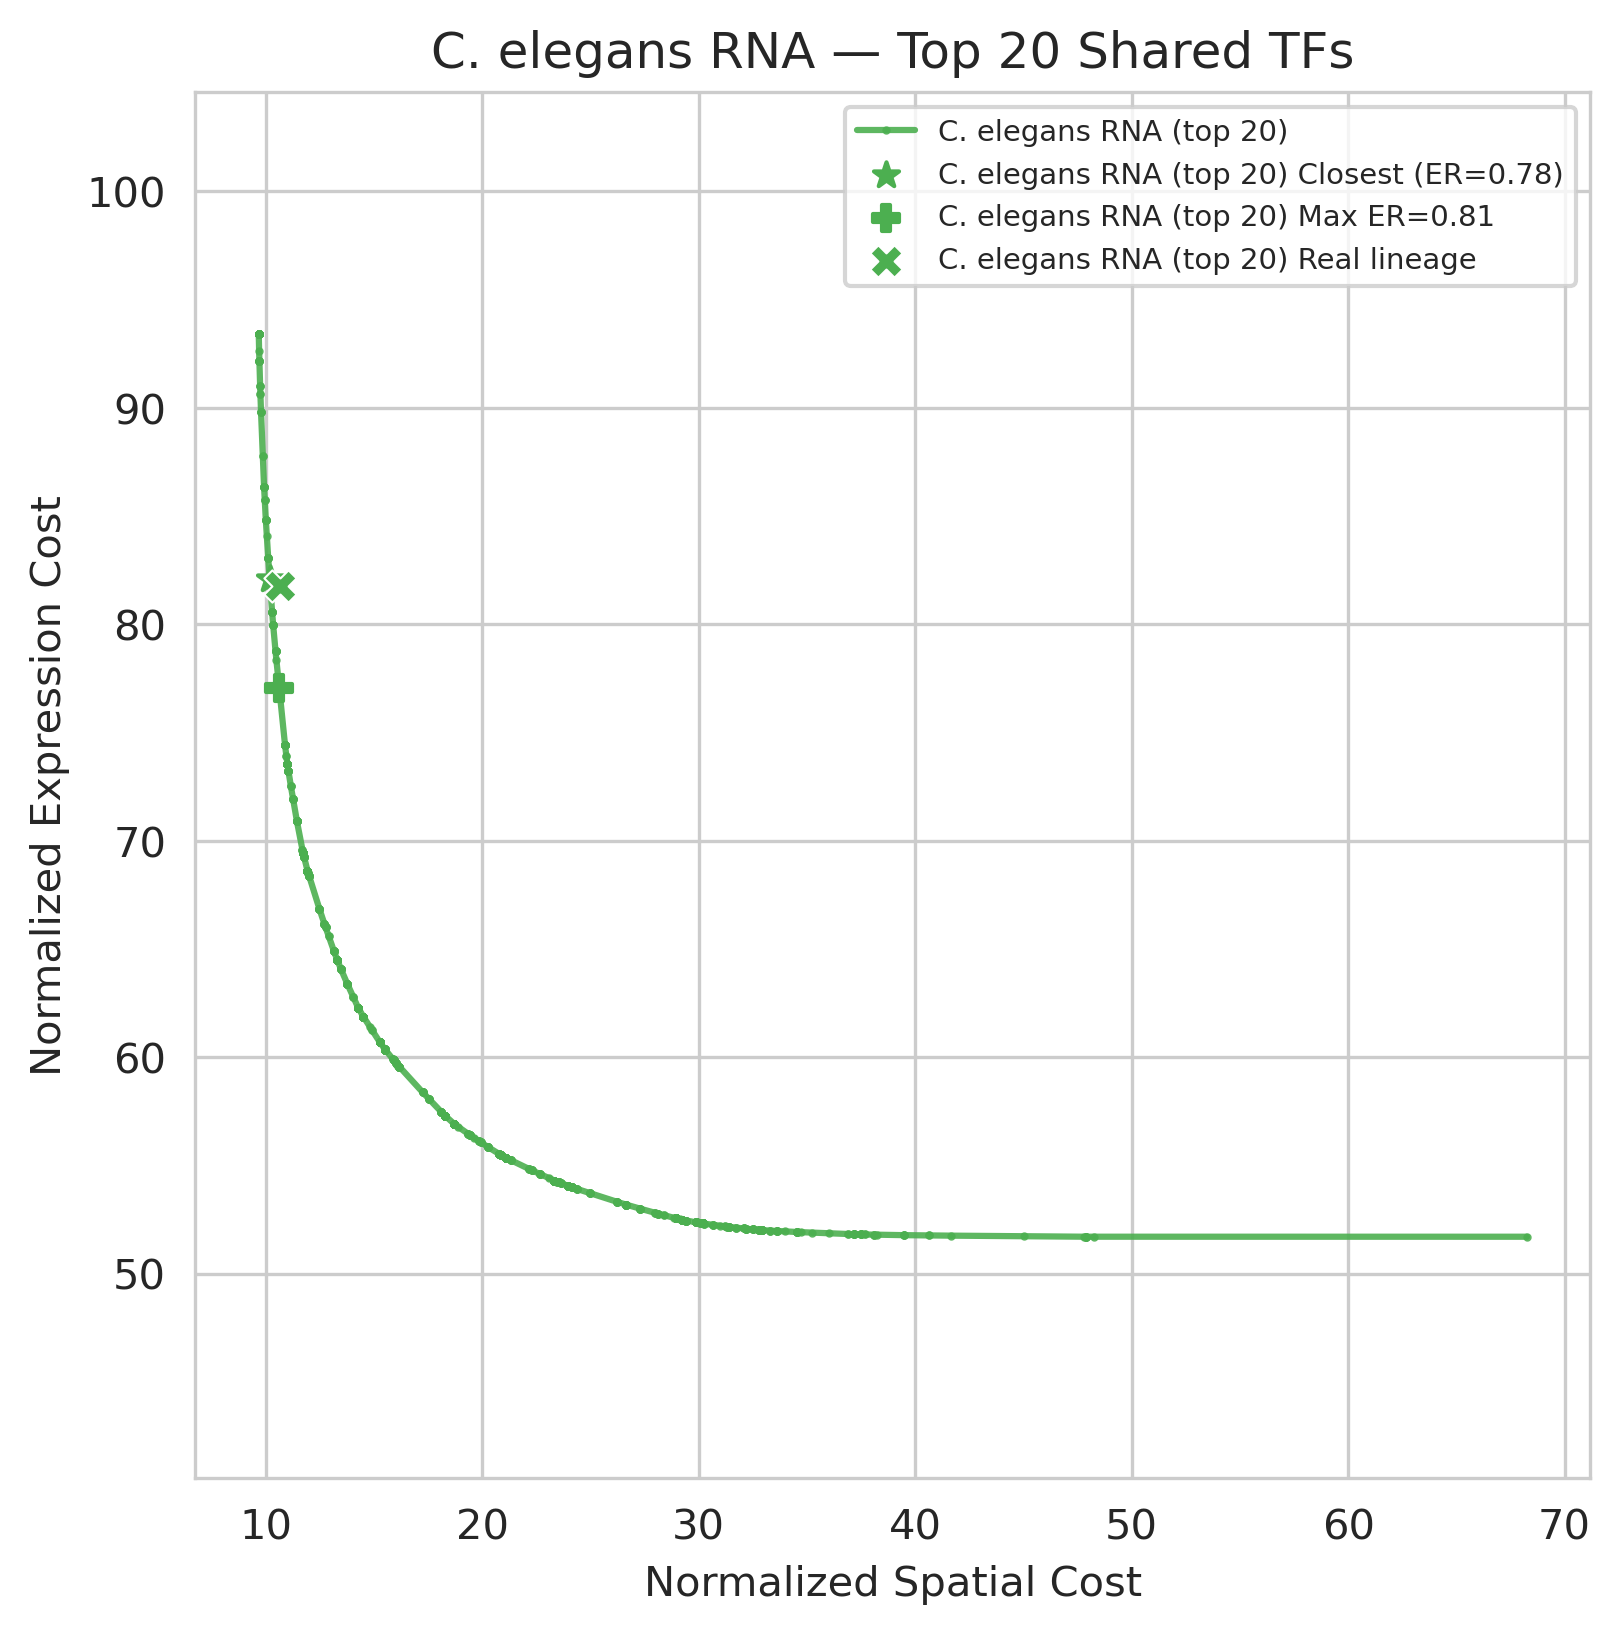

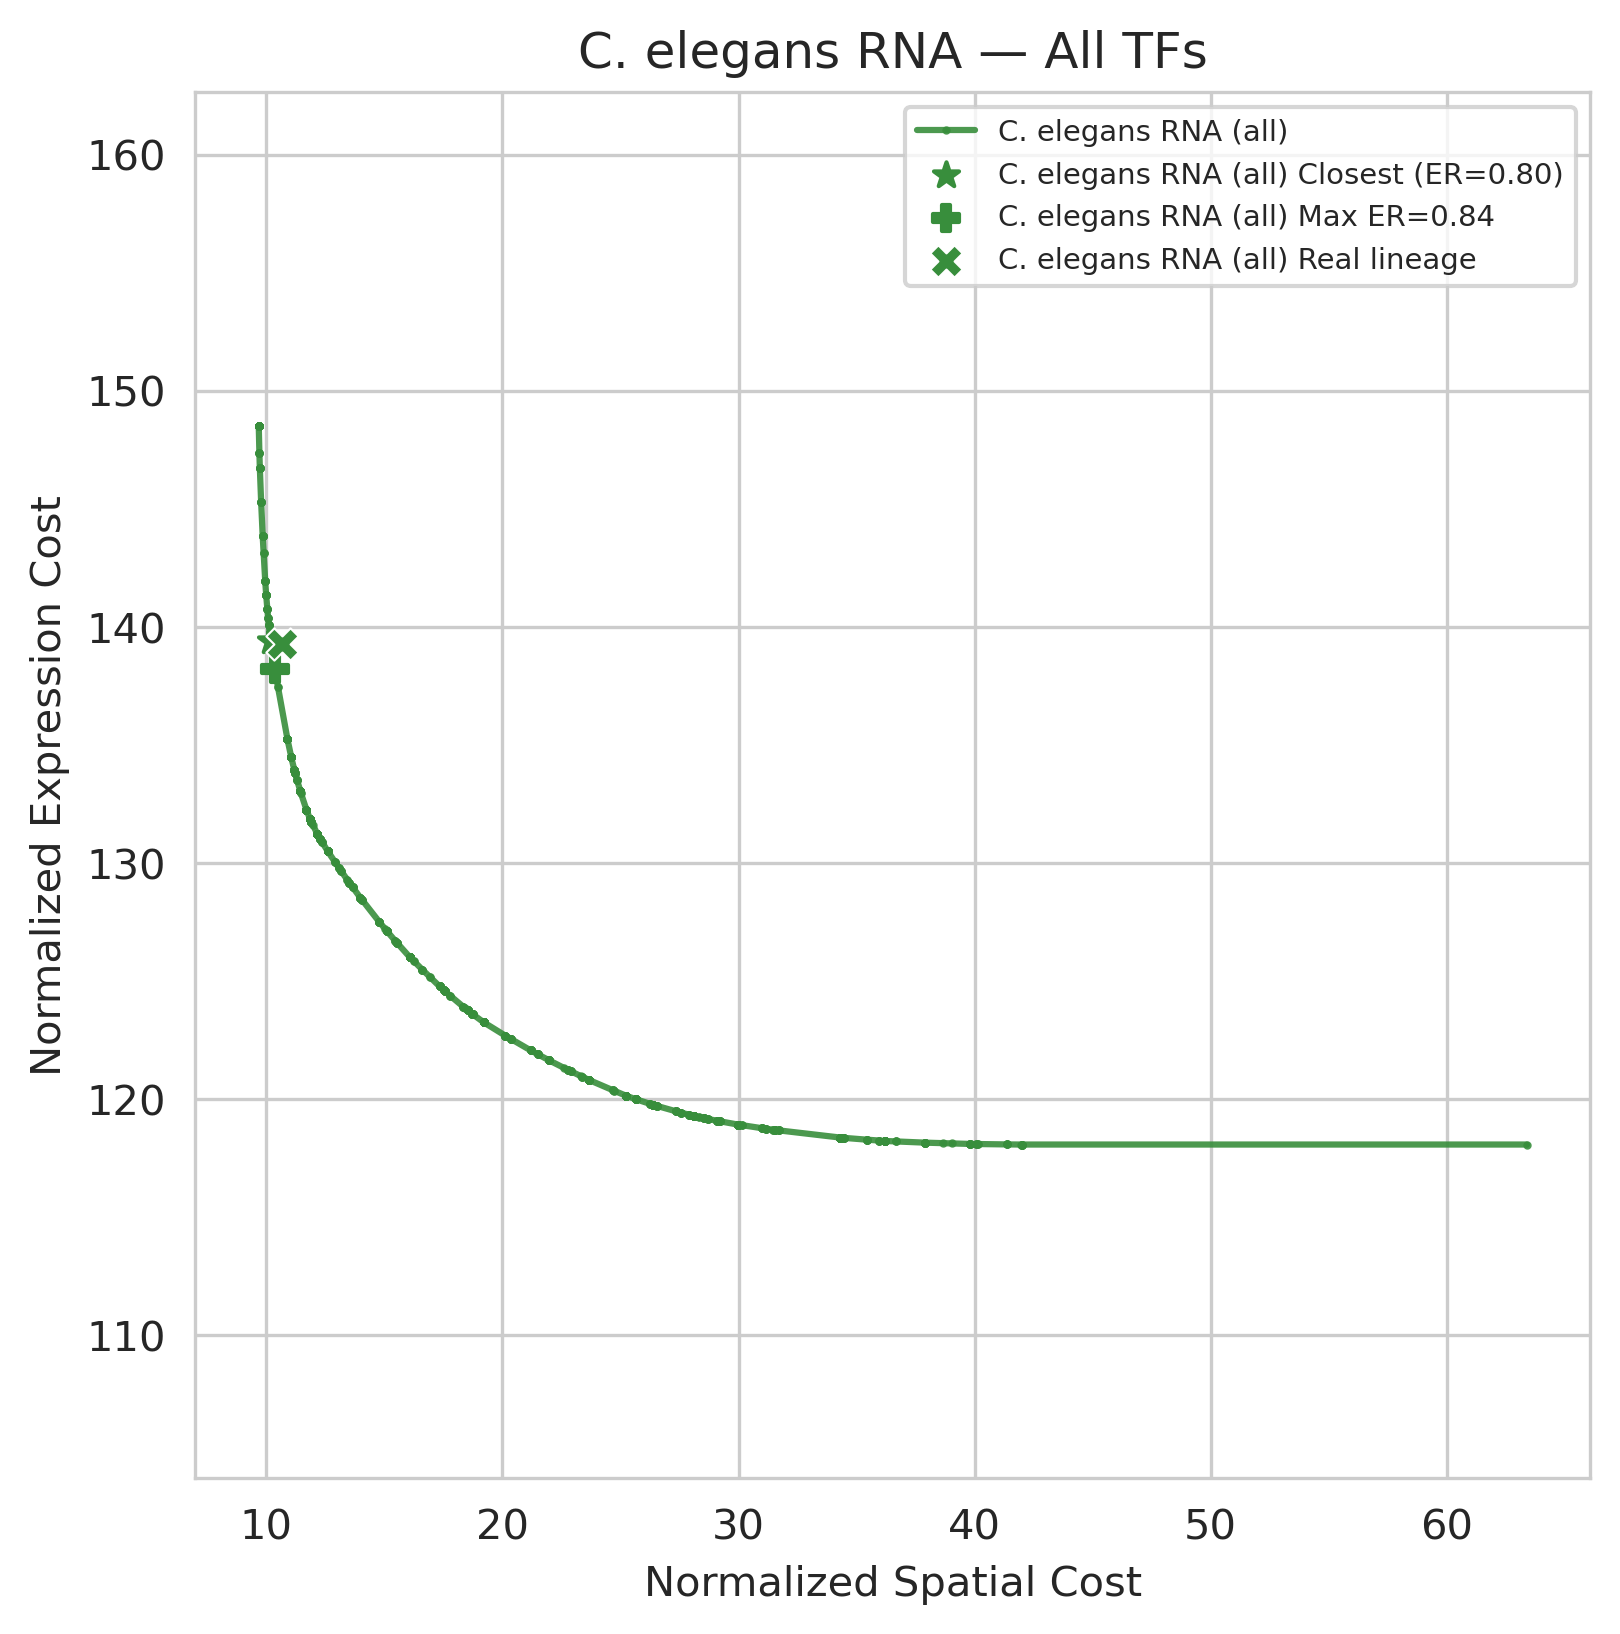

In [31]:
# ── Pareto front: C. elegans RNA ──
print("=" * 60)
print("C. ELEGANS RNA — PARETO FRONT RESULTS")
print("=" * 60)

# 1) Top 20 shared TFs
res_er = pareto_calculate(
    xyz_cost_er, exp_cost_er, elegans_rna_term['terminal_parents'],
    plot_figure=True, figure_title="C. elegans RNA — Top 20 Shared TFs",
    color='#4CAF50', label='C. elegans RNA (top 20)'
)
print_pareto_summary(res_er, "Top 20 shared TFs")

# 2) All TFs
res_er_all = pareto_calculate(
    xyz_cost_er, all_exp_cost_er, elegans_rna_term['terminal_parents'],
    plot_figure=True, figure_title="C. elegans RNA — All TFs",
    color='#388E3C', label='C. elegans RNA (all)'
)
print_pareto_summary(res_er_all, f"All {elegans_rna_full.shape[1]} TFs")


In [32]:
# ── Random baseline for C. elegans RNA ──
print("Running random baseline for C. elegans RNA...")

er_random_mats = build_random_cost_matrices(
    elegans_rna_term['terminal_parents'], elegans_rna_term['terminal_nodes'],
    full_exp_dict_er, n_features=20, n_random=1000
)

er_random_results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(pareto_calculate)(xyz_cost_er, rmat, elegans_rna_term['terminal_parents'],
                              plot_figure=False)
    for rmat in tqdm(er_random_mats, desc="Random baseline: C. elegans RNA")
)

er_rand_df = pd.DataFrame(er_random_results)
print("\nRandom baseline summary (C. elegans RNA, 20 random TFs, n=1000):")
print(f"  Spatial optimum ER:     {er_rand_df['optimal_xyz_edge_ratio'].mean():.4f} ± {er_rand_df['optimal_xyz_edge_ratio'].std():.4f}")
print(f"  Expression optimum ER:  {er_rand_df['optimal_exp_edge_ratio'].mean():.4f} ± {er_rand_df['optimal_exp_edge_ratio'].std():.4f}")
print(f"  Max edge ratio:         {er_rand_df['largest_edge_ratio'].mean():.4f} ± {er_rand_df['largest_edge_ratio'].std():.4f}")
print(f"  Closest distance:       {er_rand_df['closest_distance'].mean():.4f} ± {er_rand_df['closest_distance'].std():.4f}")
print(f"\nReal (top 20 shared TFs):")
print(f"  Spatial optimum ER:     {res_er['optimal_xyz_edge_ratio']:.4f}")
print(f"  Expression optimum ER:  {res_er['optimal_exp_edge_ratio']:.4f}")
print(f"  Max edge ratio:         {res_er['largest_edge_ratio']:.4f}")
print(f"  Closest distance:       {res_er['closest_distance']:.4f}")


Running random baseline for C. elegans RNA...


Random feature matrices:   0%|          | 0/1000 [00:00<?, ?it/s]

Random feature matrices:   6%|▋         | 64/1000 [00:00<00:03, 271.51it/s]

Random feature matrices:  10%|▉         | 96/1000 [00:00<00:07, 115.39it/s]

Random feature matrices:  13%|█▎        | 128/1000 [00:01<00:10, 86.85it/s]

...

Random baseline: C. elegans RNA:  93%|█████████▎| 928/1000 [01:36<00:07,  9.38it/s]

Random baseline: C. elegans RNA:  96%|█████████▌| 960/1000 [01:40<00:04,  9.31it/s]

Random baseline: C. elegans RNA:  99%|█████████▉| 992/1000 [01:43<00:00,  9.47it/s]

Random baseline: C. elegans RNA: 100%|██████████| 1000/1000 [01:43<00:00,  9.66it/s]


Random baseline summary (C. elegans RNA, 20 random TFs, n=1000):
  Spatial optimum ER:     0.6840 ± 0.0000
  Expression optimum ER:  0.0416 ± 0.0176
  Max edge ratio:         0.7298 ± 0.0273
  Closest distance:       0.8690 ± 0.1805

Real (top 20 shared TFs):
  Spatial optimum ER:     0.6840
  Expression optimum ER:  0.0736
  Max edge ratio:         0.8052
  Closest distance:       0.5967


---
## Subtree Analysis — C. elegans RNA

Same lineage subtrees as above, but using C. elegans scRNA-seq expression (shared top 20 TFs).
Compare to the protein results to see whether the subtree patterns are modality-dependent.


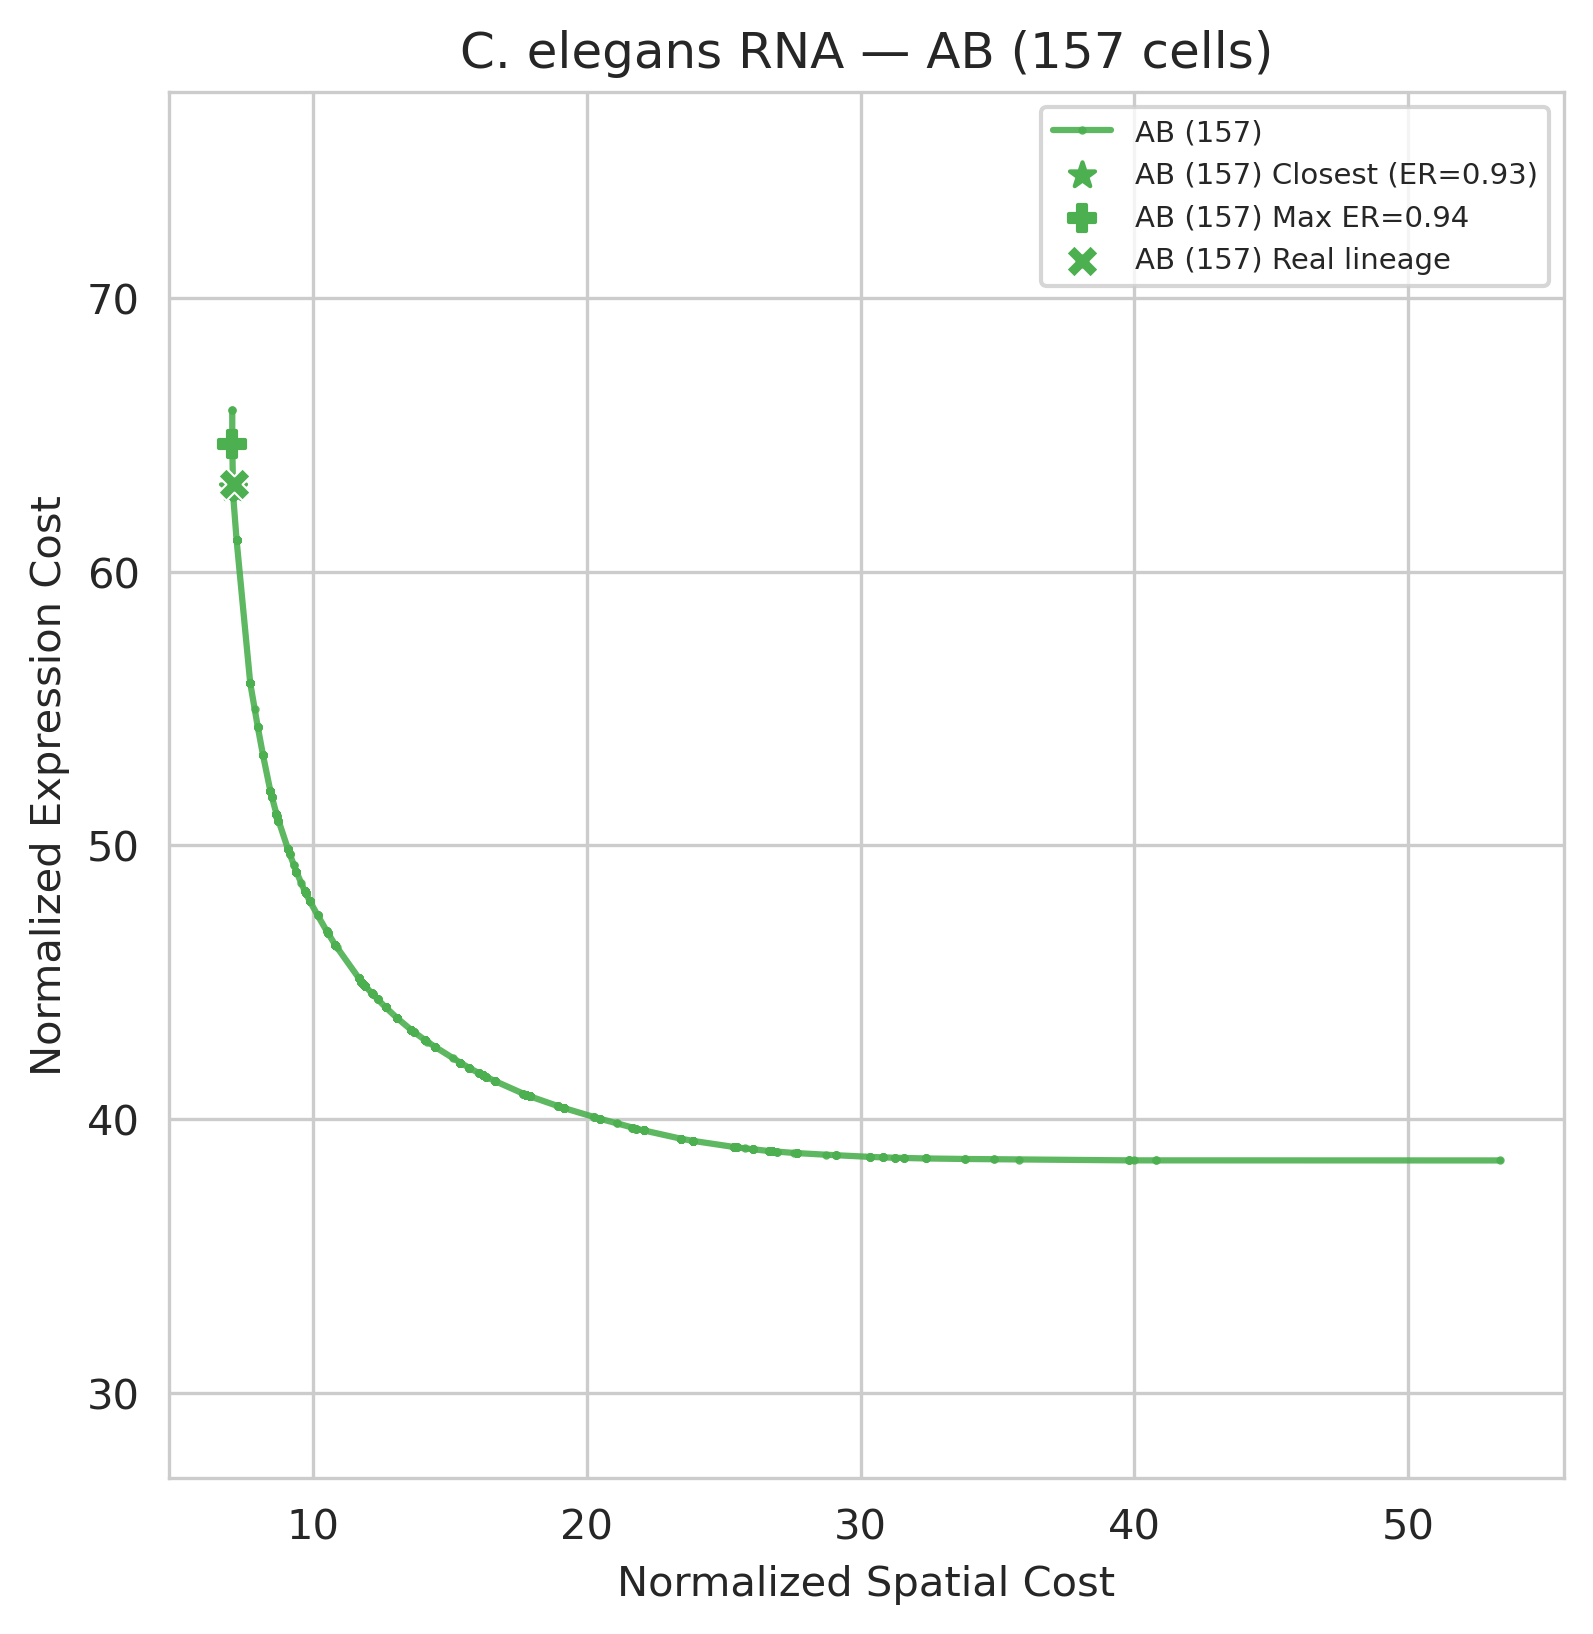

  AB          :  157 cells | Expr opt ER=0.083 | Max ER=0.936 | XYZ opt ER=0.911


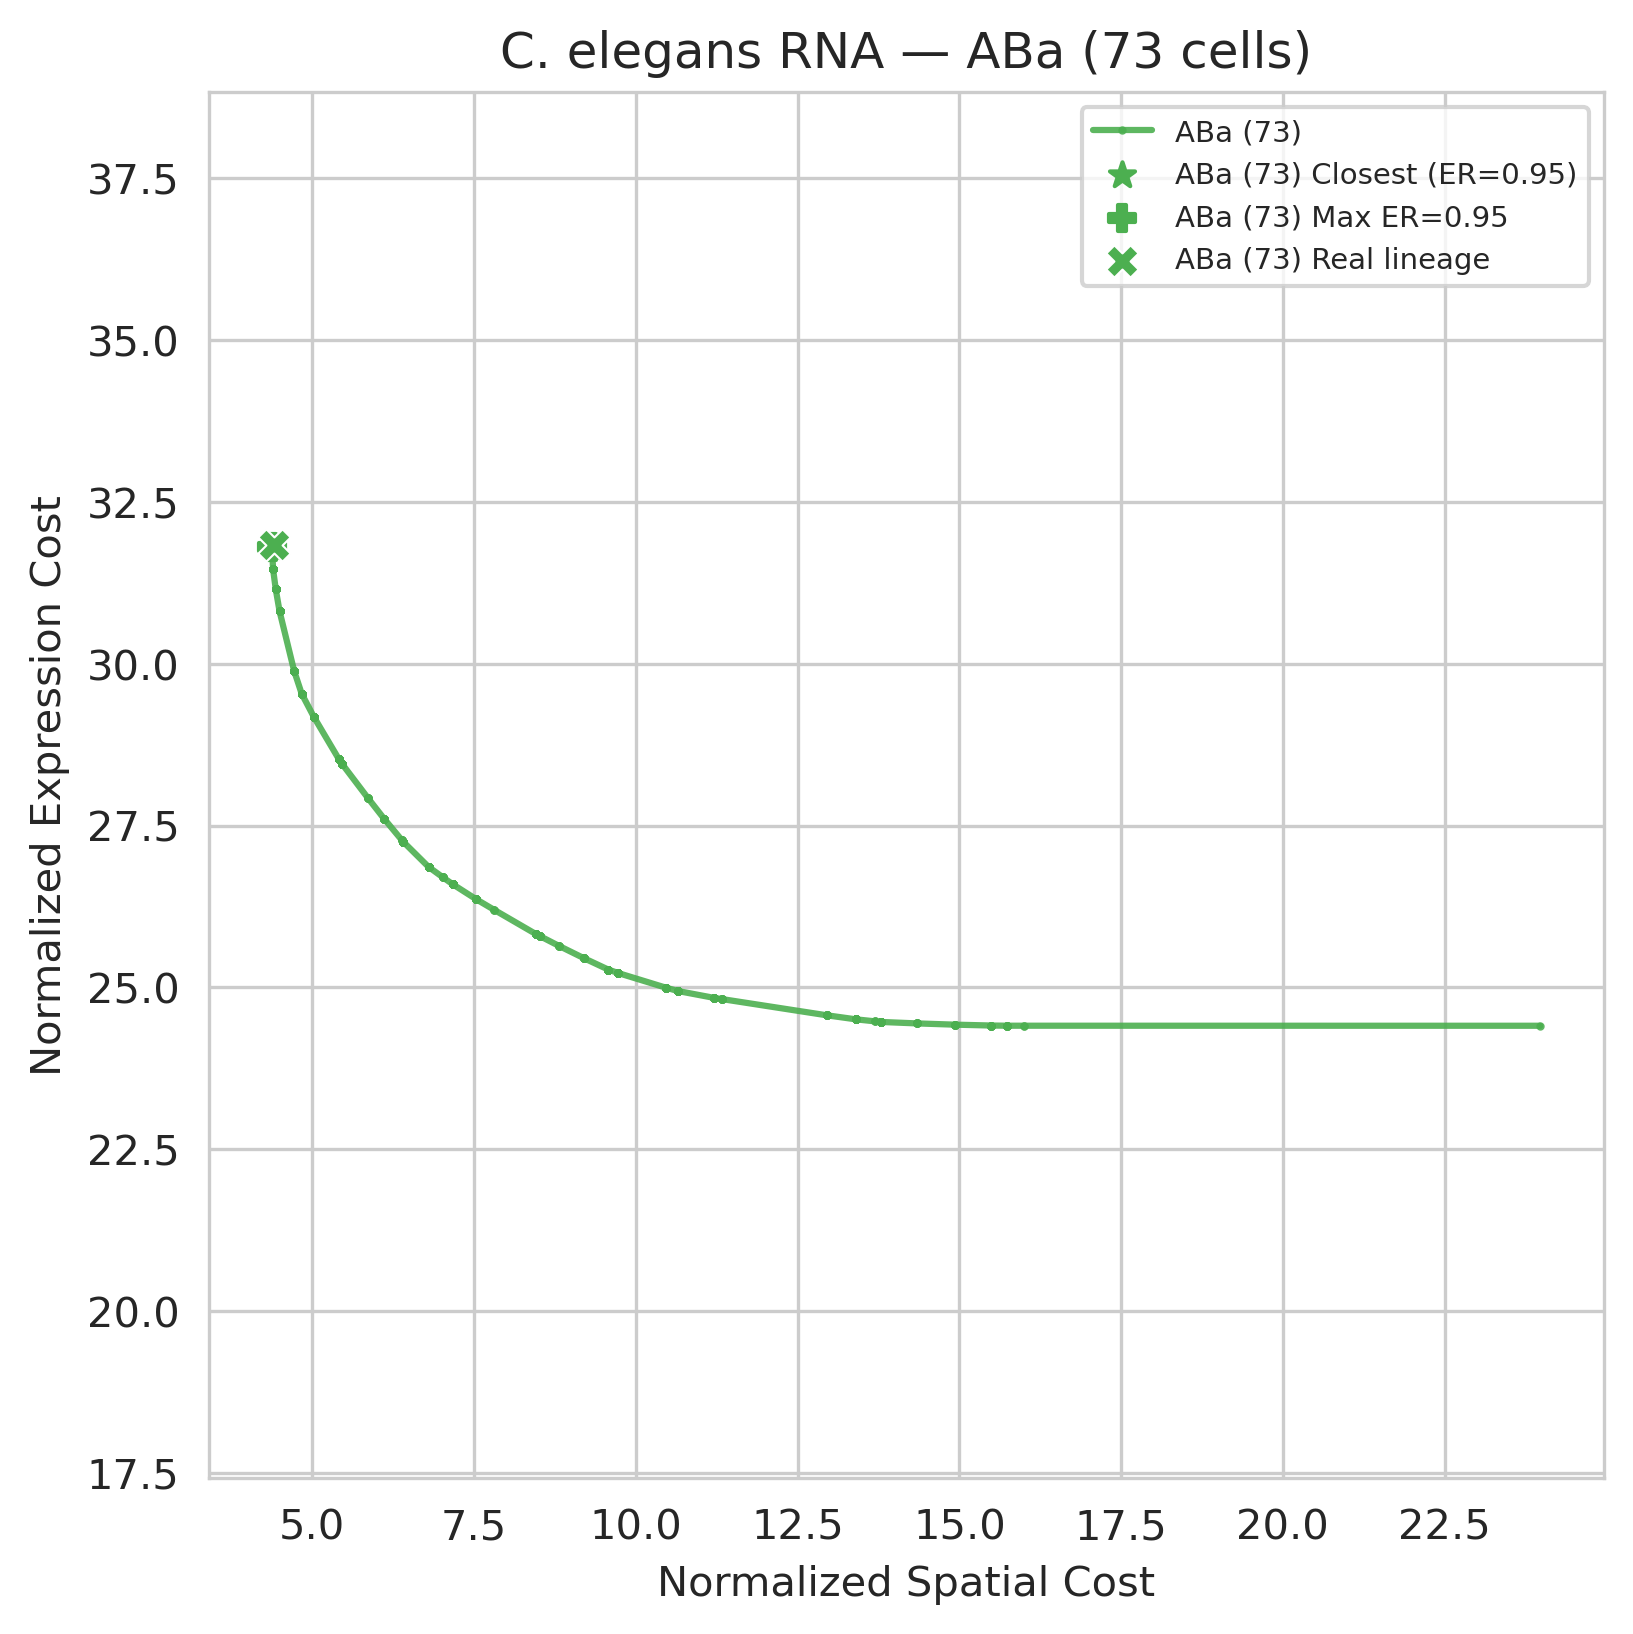

  ABa         :   73 cells | Expr opt ER=0.137 | Max ER=0.945 | XYZ opt ER=0.945


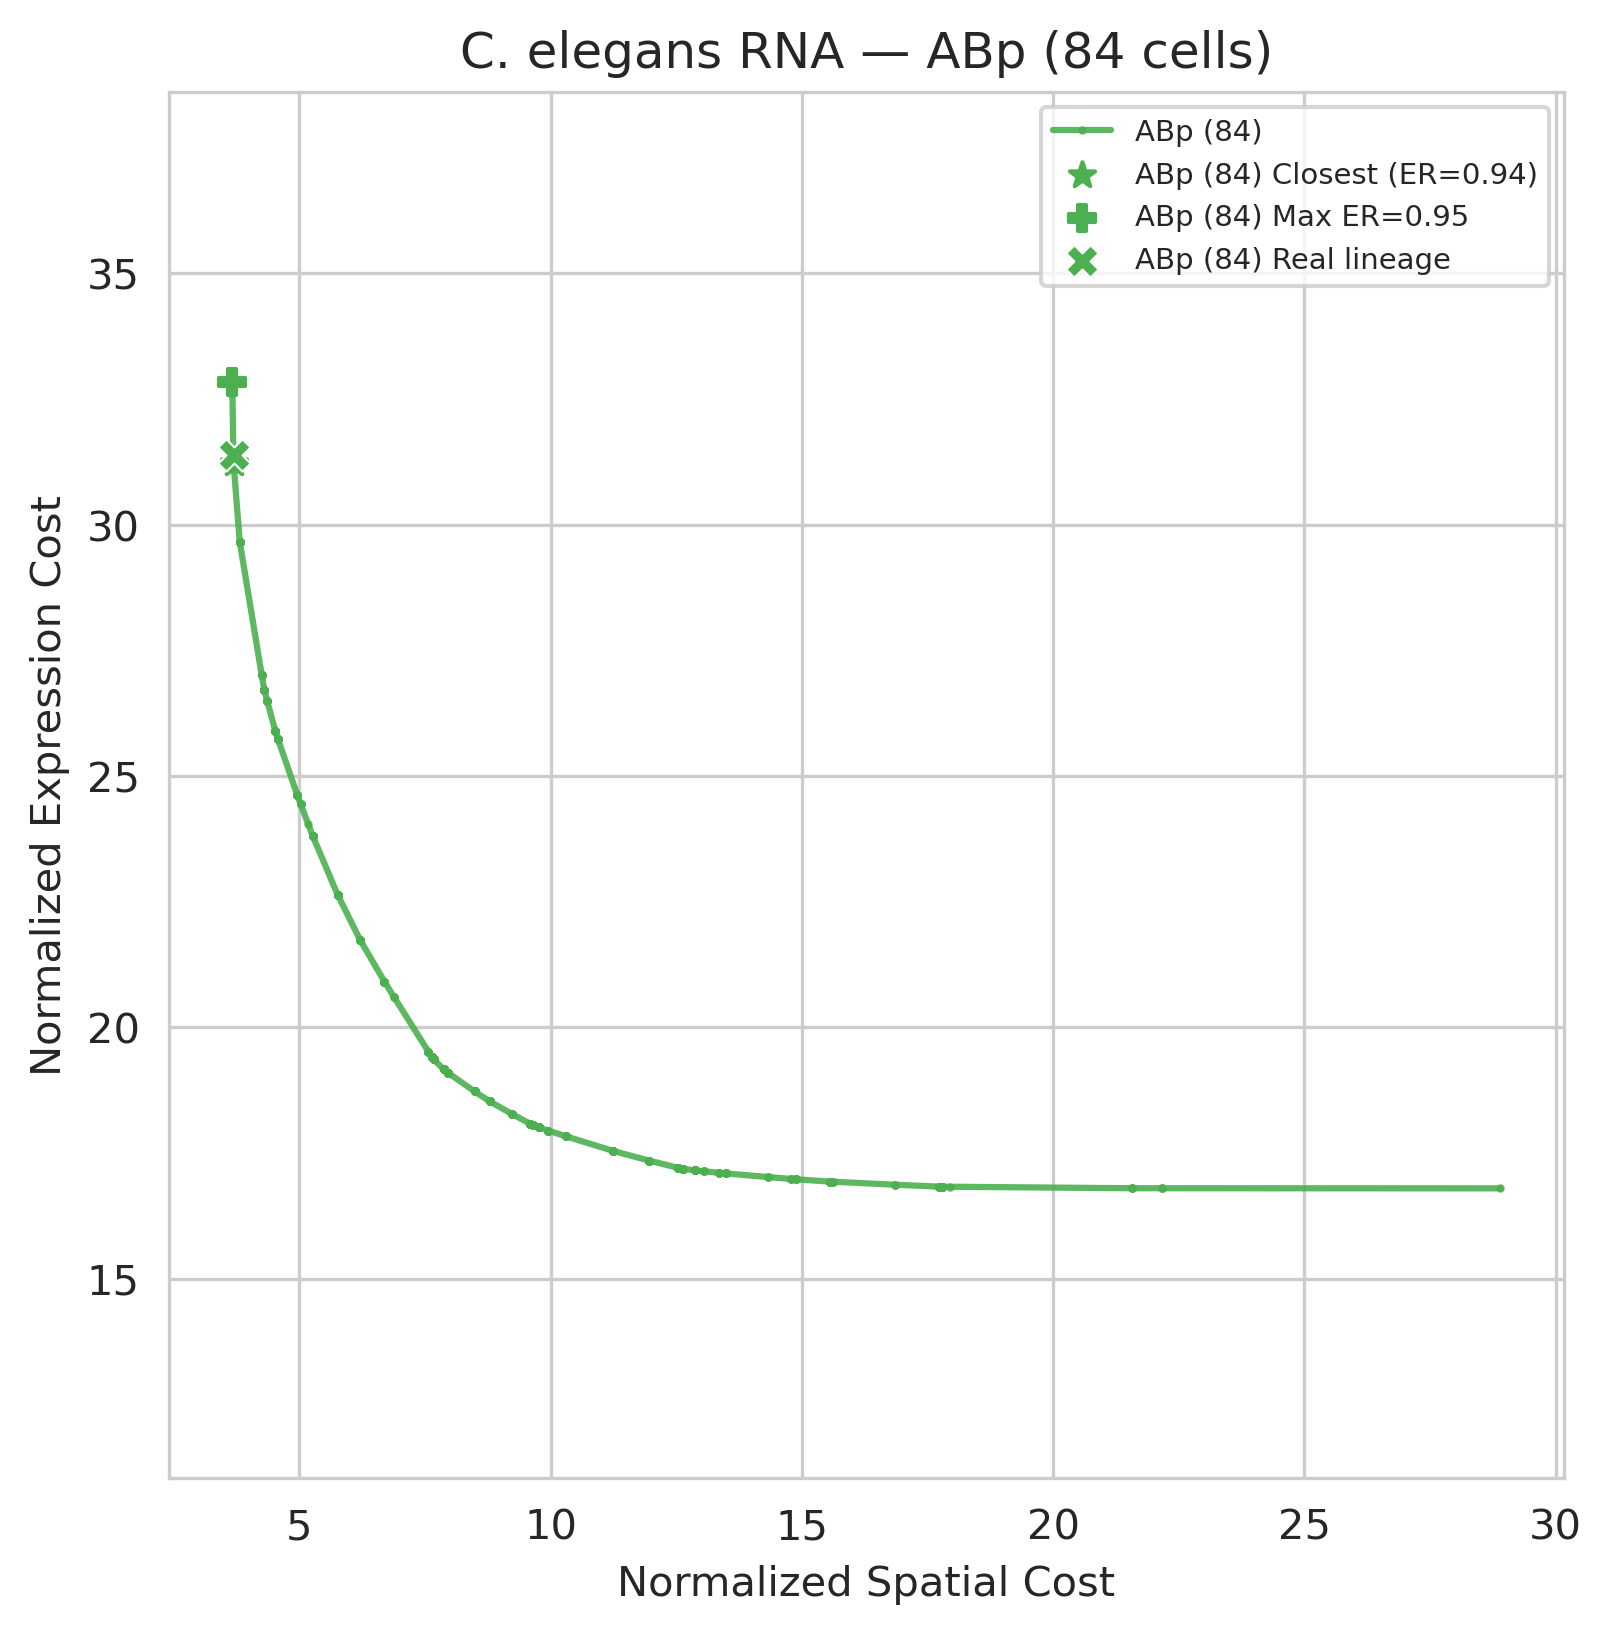

  ABp         :   84 cells | Expr opt ER=0.107 | Max ER=0.952 | XYZ opt ER=0.952


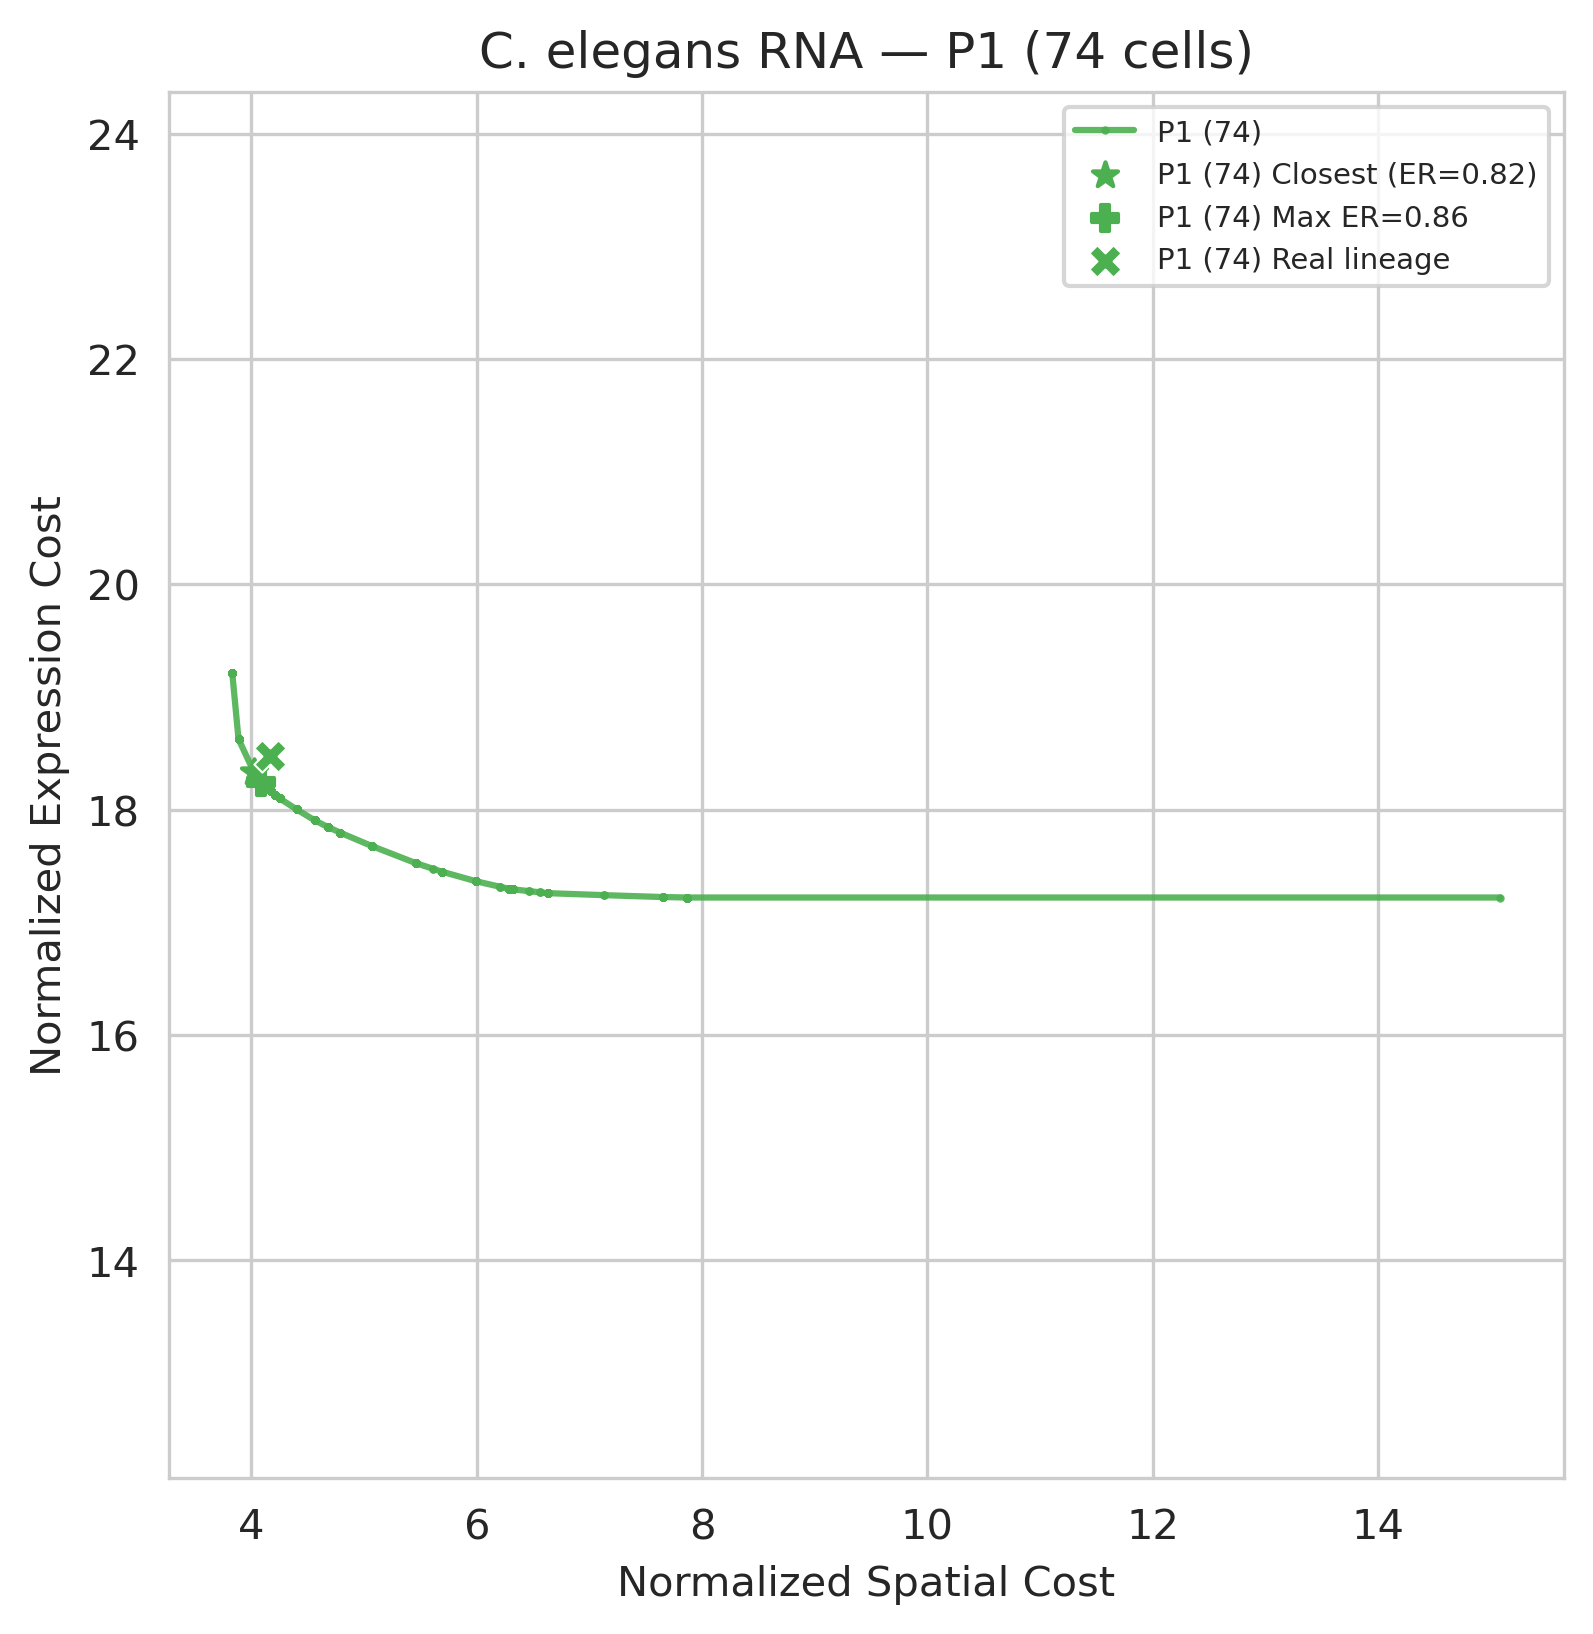

  P1          :   74 cells | Expr opt ER=0.176 | Max ER=0.865 | XYZ opt ER=0.811


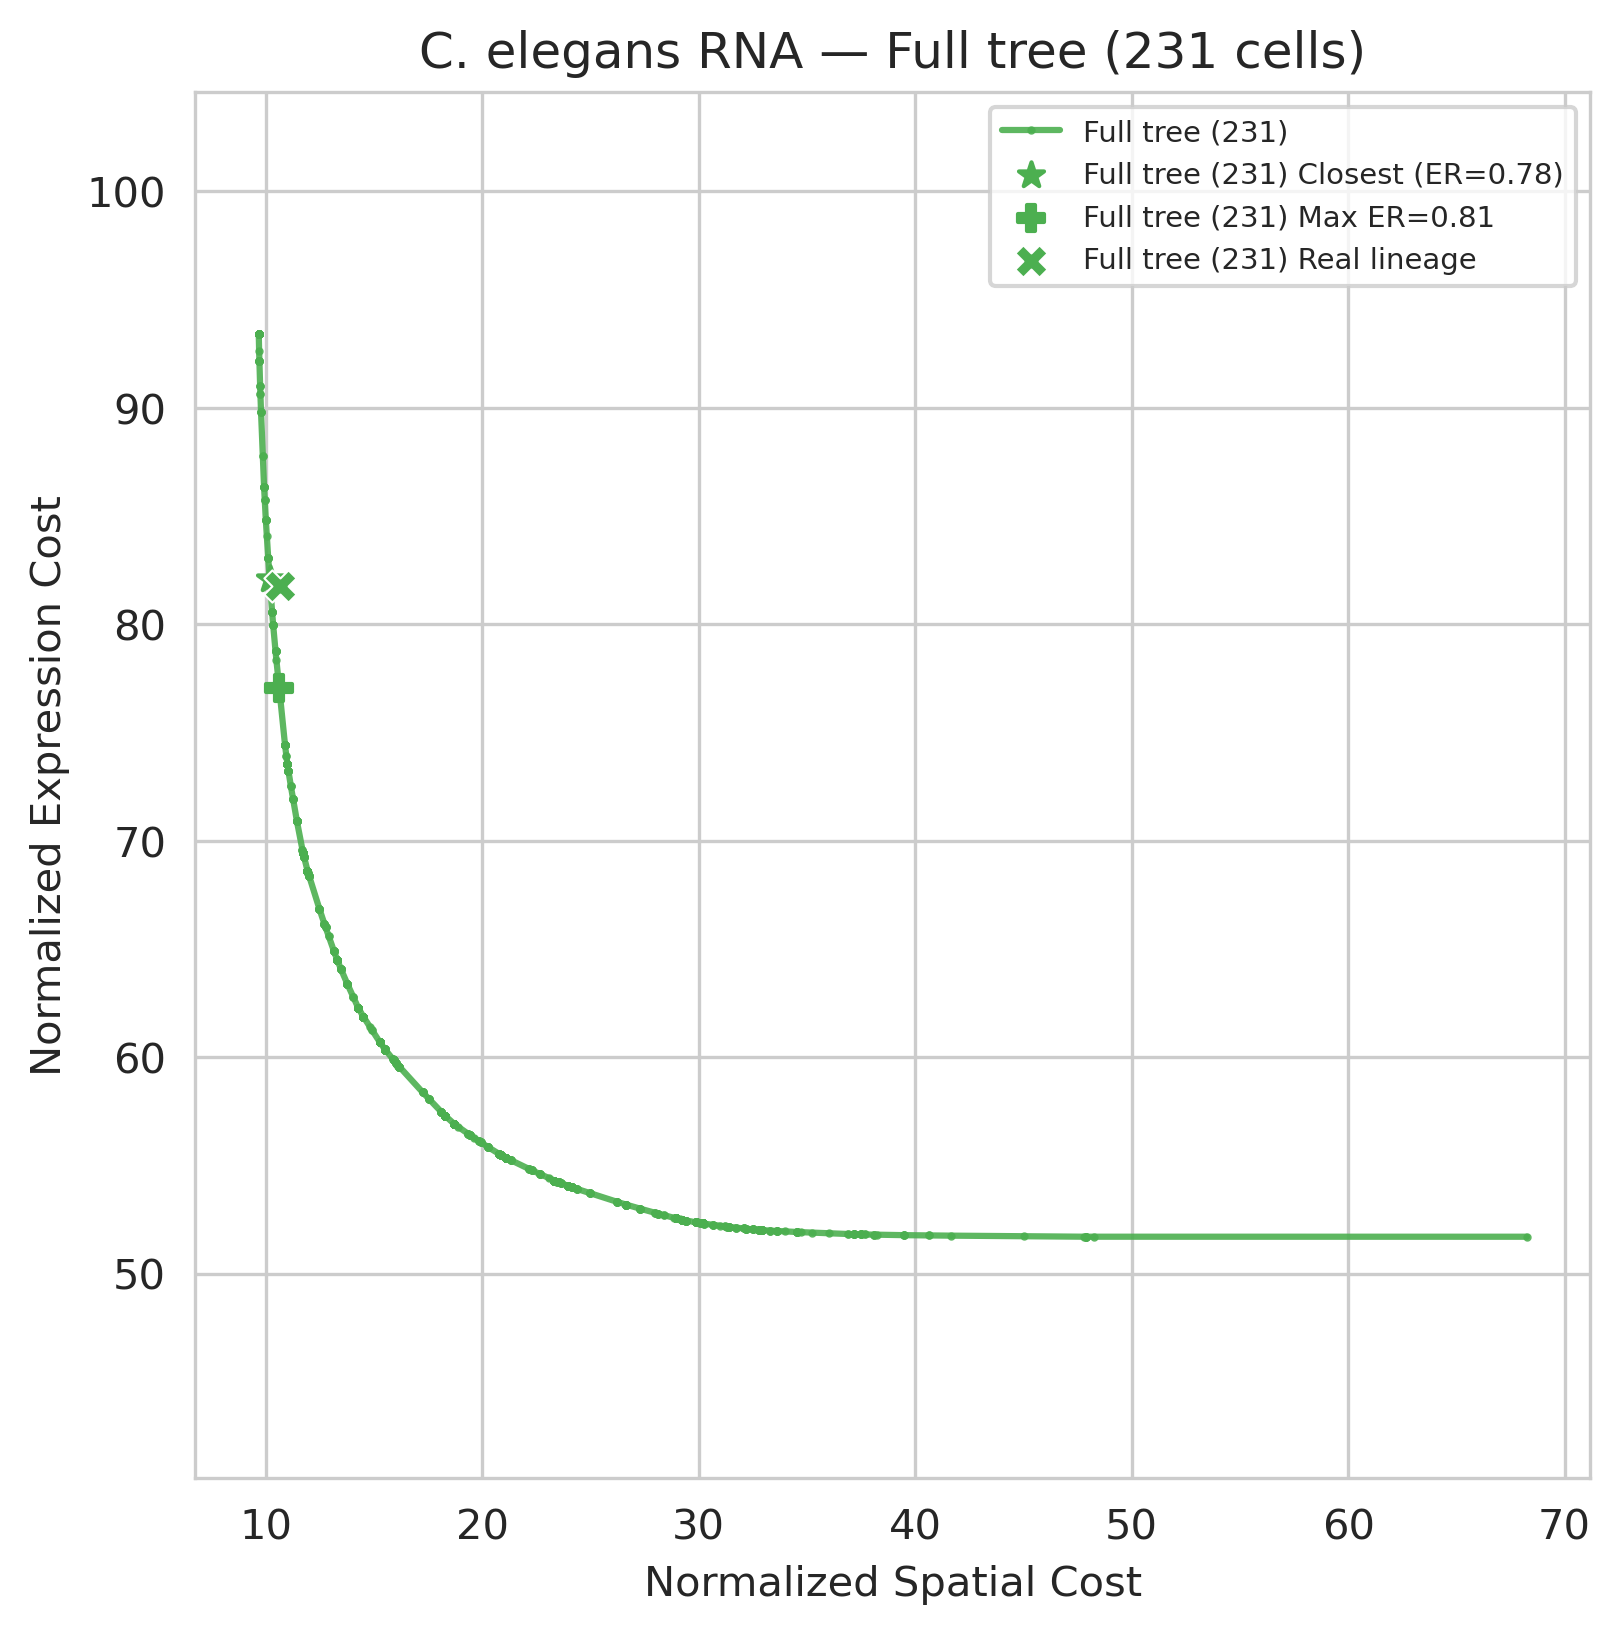

  Full tree   :  231 cells | Expr opt ER=0.074 | Max ER=0.805 | XYZ opt ER=0.684

Comparison: C. elegans RNA vs Protein (Expr Opt ER)
  Full tree   : RNA ER=0.074 (n=231)  vs  Protein ER=0.204 (n=299)
  AB          : RNA ER=0.083 (n=157)  vs  Protein ER=0.218 (n=216)
  ABa         : RNA ER=0.137 (n=73)  vs  Protein ER=0.302 (n=106)
  ABp         : RNA ER=0.107 (n=84)  vs  Protein ER=0.245 (n=110)
  P1          : RNA ER=0.176 (n=74)  vs  Protein ER=0.337 (n=83)


In [33]:
# ═══════════════════════════════════════════════════════
# Subtree analysis: C. elegans RNA (top 20 shared TFs)
# ═══════════════════════════════════════════════════════

er_subtree_results = {}

for sroot in SUBTREE_ROOTS + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    
    if sroot == 'Full':
        term_data = elegans_rna_term
    else:
        term_data = collect_terminal_cells(
            lineage_data, valid_cell_names_elegans_rna,
            protein_exp_index=elegans_rna_full.index,
            include_embryonic_terminals=False,
            include_apoptotic_cells=True,
            subtree_root_name=sroot
        )
    
    n_term = len(term_data['terminal_nodes'])
    
    xyz_mat, exp_mat, full_exp_dict, _ = build_cost_matrices(
        term_data['terminal_nodes'], term_data['terminal_parents'],
        all_xyz_map_elegans, elegans_rna_full, selected_features=rna_selected_features
    )
    
    res = pareto_calculate(
        xyz_mat, exp_mat, term_data['terminal_parents'],
        plot_figure=True, figure_title=f"C. elegans RNA — {label} ({n_term} cells)",
        color='#4CAF50', label=f'{label} ({n_term})'
    )
    plt.show()
    
    er_subtree_results[label] = {
        'term_data': term_data, 'xyz_mat': xyz_mat, 'exp_mat': exp_mat,
        'full_exp_dict': full_exp_dict, 'pareto': res,
    }
    
    print(f"  {label:12s}: {n_term:4d} cells | "
          f"Expr opt ER={res['optimal_exp_edge_ratio']:.3f} | "
          f"Max ER={res['largest_edge_ratio']:.3f} | "
          f"XYZ opt ER={res['optimal_xyz_edge_ratio']:.3f}")


# ── Quick comparison table vs protein ──
print("\nComparison: C. elegans RNA vs Protein (Expr Opt ER)")
for label in subtree_labels:
    rna_er = er_subtree_results[label]['pareto']['optimal_exp_edge_ratio']
    prot_er = subtree_results[label]['pareto']['optimal_exp_edge_ratio']
    rna_n = len(er_subtree_results[label]['term_data']['terminal_nodes'])
    prot_n = len(subtree_results[label]['term_data']['terminal_nodes'])
    print(f"  {label:12s}: RNA ER={rna_er:.3f} (n={rna_n})  vs  Protein ER={prot_er:.3f} (n={prot_n})")


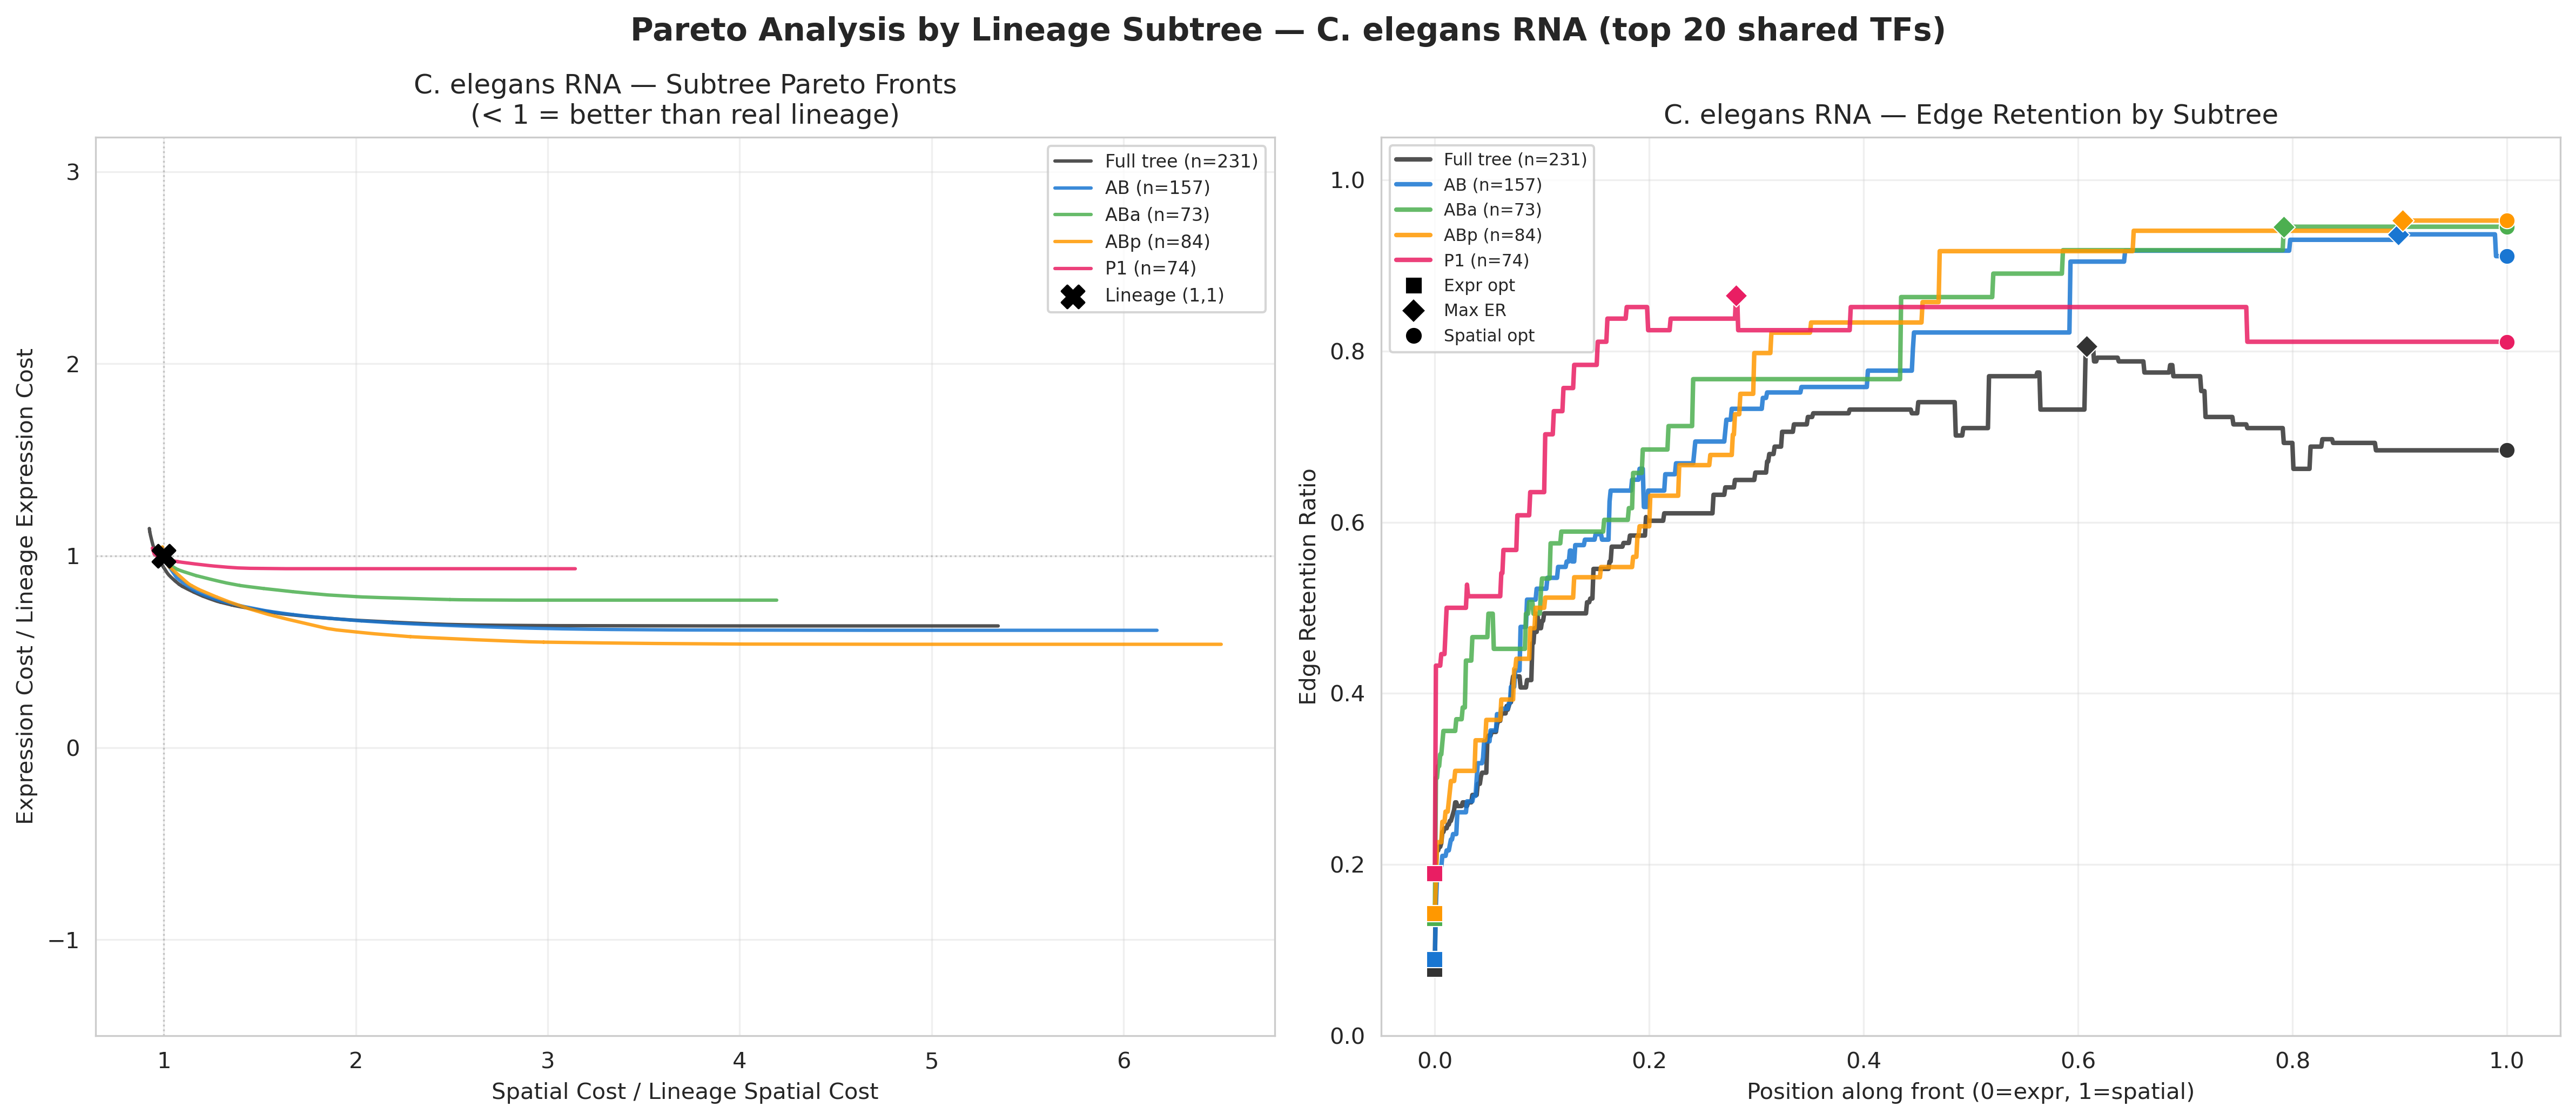

In [34]:
# Shared helpers (also defined in protein section above)
def _compute_ratio_pareto(xyz_cost_mat, exp_cost_mat, terminal_parents, iteration=1000):
    lineage_xyz = xyz_cost_mat.diagonal().sum()
    lineage_exp = exp_cost_mat.diagonal().sum()
    xyz_rel = xyz_cost_mat / lineage_xyz; exp_rel = exp_cost_mat / lineage_exp
    xyz_list, exp_list, edge_ratios = [], [], []
    for i in range(iteration + 1):
        alpha = i / iteration
        row_ind, col_ind = linear_sum_assignment(alpha * xyz_rel + (1 - alpha) * exp_rel)
        xyz_list.append(xyz_rel[row_ind, col_ind].sum())
        exp_list.append(exp_rel[row_ind, col_ind].sum())
        edge_ratios.append(lineage_edge_ratio(row_ind, col_ind, terminal_parents))
    edge_ratios = np.array(edge_ratios)
    max_er_idx = int(np.argmax(edge_ratios))
    key_points = {"expr_opt_idx": 0, "xyz_opt_idx": iteration, "max_er_idx": max_er_idx}
    return np.array(xyz_list), np.array(exp_list), edge_ratios, key_points

subtree_colors = {"Full tree": "#333333", "AB": "#1976D2", "ABa": "#4CAF50", "ABp": "#FF9800", "P1": "#E91E63"}
x_front = np.linspace(0, 1, 1001)
_markers = {"expr_opt_idx": ("s", "Expr opt"), "max_er_idx": ("D", "Max ER"), "xyz_opt_idx": ("o", "Spatial opt")}

# ── Visualize: C. elegans RNA subtree Pareto fronts ──

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))

for label in subtree_labels:
    sr = er_subtree_results[label]
    xyz_arr, exp_arr, edge_arr, key_pts = _compute_ratio_pareto(
        sr['xyz_mat'], sr['exp_mat'], sr['term_data']['terminal_parents'])
    color = subtree_colors[label]
    n = len(sr['term_data']['terminal_nodes'])
    
    ax_left.plot(xyz_arr, exp_arr, color=color, linewidth=1.5, alpha=0.85,
                 label=f'{label} (n={n})')
    ax_left.scatter(1.0, 1.0, color=color, marker='X', s=70, edgecolors='white', linewidth=0.8, zorder=6)
    
    ax_right.plot(x_front, edge_arr, color=color, linewidth=2, alpha=0.85, label=f'{label} (n={n})')
    for pt_key, (marker, _) in _markers.items():
        idx = key_pts[pt_key]
        ax_right.scatter(x_front[idx], edge_arr[idx], color=color, marker=marker,
                        s=50, zorder=8, edgecolors='white', linewidth=0.5)

ax_left.axvline(x=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.axhline(y=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.scatter([1.0], [1.0], color='black', marker='X', s=100, zorder=10, label='Lineage (1,1)')
ax_left.set_xlabel('Spatial Cost / Lineage Spatial Cost'); ax_left.set_ylabel('Expression Cost / Lineage Expression Cost')
ax_left.set_title('C. elegans RNA — Subtree Pareto Fronts\n(< 1 = better than real lineage)', fontsize=12)
ax_left.legend(fontsize=8, loc='upper right'); ax_left.axis('equal'); ax_left.grid(True, alpha=0.3)

legend_lines = list(ax_right.get_lines()) + [
    Line2D([0], [0], color='black', marker='s', linestyle='', markersize=6, label='Expr opt'),
    Line2D([0], [0], color='black', marker='D', linestyle='', markersize=6, label='Max ER'),
    Line2D([0], [0], color='black', marker='o', linestyle='', markersize=6, label='Spatial opt'),
]
ax_right.legend(handles=legend_lines, fontsize=7.5, loc='best')
ax_right.set_xlabel('Position along front (0=expr, 1=spatial)')
ax_right.set_ylabel('Edge Retention Ratio')
ax_right.set_title('C. elegans RNA — Edge Retention by Subtree', fontsize=12)
ax_right.set_ylim(0, 1.05); ax_right.grid(True, alpha=0.3)

fig.suptitle('Pareto Analysis by Lineage Subtree — C. elegans RNA (top 20 shared TFs)',
             fontsize=14, fontweight='bold')
fig.tight_layout(); plt.show()


---
## C. briggsae — RNA-seq Expression


In [35]:
# ═══════════════════════════════════════════════════════
# C. BRIGGSAE TRACKING + RNA-SEQ
# ═══════════════════════════════════════════════════════

# ── C. briggsae tracking ──
T_THRESHOLD_BRIGGSAE = 155
ts_briggsae = pd.read_csv("data/c_briggsae/CD140715HLH1cbp1.csv")
ts_briggsae = ts_briggsae.loc[ts_briggsae["time"] <= T_THRESHOLD_BRIGGSAE]

all_xyz_map_briggsae = {}
cell_names_briggsae = ts_briggsae["cell"].unique()
valid_cell_names_briggsae = []

for name in cell_names_briggsae:
    time_points = ts_briggsae.loc[ts_briggsae['cell'] == name]["time"].values
    if len(time_points) == 1 and time_points[0] == T_THRESHOLD_BRIGGSAE:
        continue
    # C. briggsae tracking: columns 8-10 are x, y, z
    all_xyz_map_briggsae[name] = ts_briggsae.loc[ts_briggsae['cell'] == name].values[-1][8:11]
    valid_cell_names_briggsae.append(name)

print(f"C. briggsae tracked cells: {len(valid_cell_names_briggsae)}")

# ── C. briggsae RNA expression ──
briggsae_rna_full = pd.read_csv(
    "data/c_briggsae/science.adu8249/c_briggsae_tf.csv", index_col=0
).T

print(f"C. briggsae RNA expression: {briggsae_rna_full.shape[0]} cells × {briggsae_rna_full.shape[1]} TFs")
print(f"Shared top 20 TFs: {rna_selected_features}")

# Verify features exist in briggsae data
available_features = [f for f in rna_selected_features if f in briggsae_rna_full.columns]
print(f"Selected features available in C. briggsae: {len(available_features)}/20")
if len(available_features) < 20:
    print(f"  Missing: {set(rna_selected_features) - set(available_features)}")

# Filter valid cells
valid_cell_names_briggsae_rna = [n for n in valid_cell_names_briggsae
                                  if n in briggsae_rna_full.index]
print(f"Valid C. briggsae cells with RNA data: {len(valid_cell_names_briggsae_rna)}")


C. briggsae tracked cells: 750
C. briggsae RNA expression: 1063 cells × 237 TFs
Shared top 20 TFs: ['pax-1', 'nhr-25', 'unc-120', 'lin-26', 'ceh-44', 'ceh-22', 'hnd-1', 'M03D4.4', 'unc-30', 'elt-1', 'pros-1', 'pha-4', 'nhr-49', 'egl-46', 'odd-2', 'ceh-31', 'nhr-186', 'hlh-8', 'ttx-1', 'tbx-8']
Selected features available in C. briggsae: 20/20
Valid C. briggsae cells with RNA data: 677


In [36]:
# ── Collect terminal cells ──
briggsae_rna_term = collect_terminal_cells(
    lineage_data, valid_cell_names_briggsae_rna,
    protein_exp_index=briggsae_rna_full.index,
    include_embryonic_terminals=False,
    include_apoptotic_cells=True
)

print(f"Terminal nodes: {len(briggsae_rna_term['terminal_nodes'])}")
print(f"Terminal parents: {len(briggsae_rna_term['terminal_parents'])}")
print(f"All terminal cells: {len(briggsae_rna_term['all_terminal_nodes'])}")


Terminal nodes: 69
Terminal parents: 69
All terminal cells: 373


In [37]:
# ── Build cost matrices ──
xyz_cost_cb, exp_cost_cb, full_exp_dict_cb, _ = build_cost_matrices(
    briggsae_rna_term['terminal_nodes'], briggsae_rna_term['terminal_parents'],
    all_xyz_map_briggsae, briggsae_rna_full, selected_features=rna_selected_features
)

# All-TF version
_, all_exp_cost_cb, _, _ = build_cost_matrices(
    briggsae_rna_term['terminal_nodes'], briggsae_rna_term['terminal_parents'],
    all_xyz_map_briggsae, briggsae_rna_full, selected_features=None
)

print("Cost matrix shapes:", xyz_cost_cb.shape, exp_cost_cb.shape)
print(f"Lineage spatial cost: {xyz_cost_cb.diagonal().sum():.2f}")
print(f"Lineage exp cost (all TFs): {all_exp_cost_cb.diagonal().sum():.2f}")
print(f"Lineage exp cost (top 20): {exp_cost_cb.diagonal().sum():.2f}")


Cost matrix shapes: (69, 69) (69, 69)
Lineage spatial cost: 2306.63
Lineage exp cost (all TFs): 27.45
Lineage exp cost (top 20): 19.69


C. BRIGGSAE RNA — PARETO FRONT RESULTS
  Top 20 shared TFs
    Spatial optimum edge ratio:     0.4928
    Expression optimum edge ratio:  0.1304
    Max edge ratio (best trade-off): 0.7536
    Closest distance to Pareto:     0.2448
  All 237 TFs
    Spatial optimum edge ratio:     0.4928
    Expression optimum edge ratio:  0.1884
    Max edge ratio (best trade-off): 0.7246
    Closest distance to Pareto:     0.5578


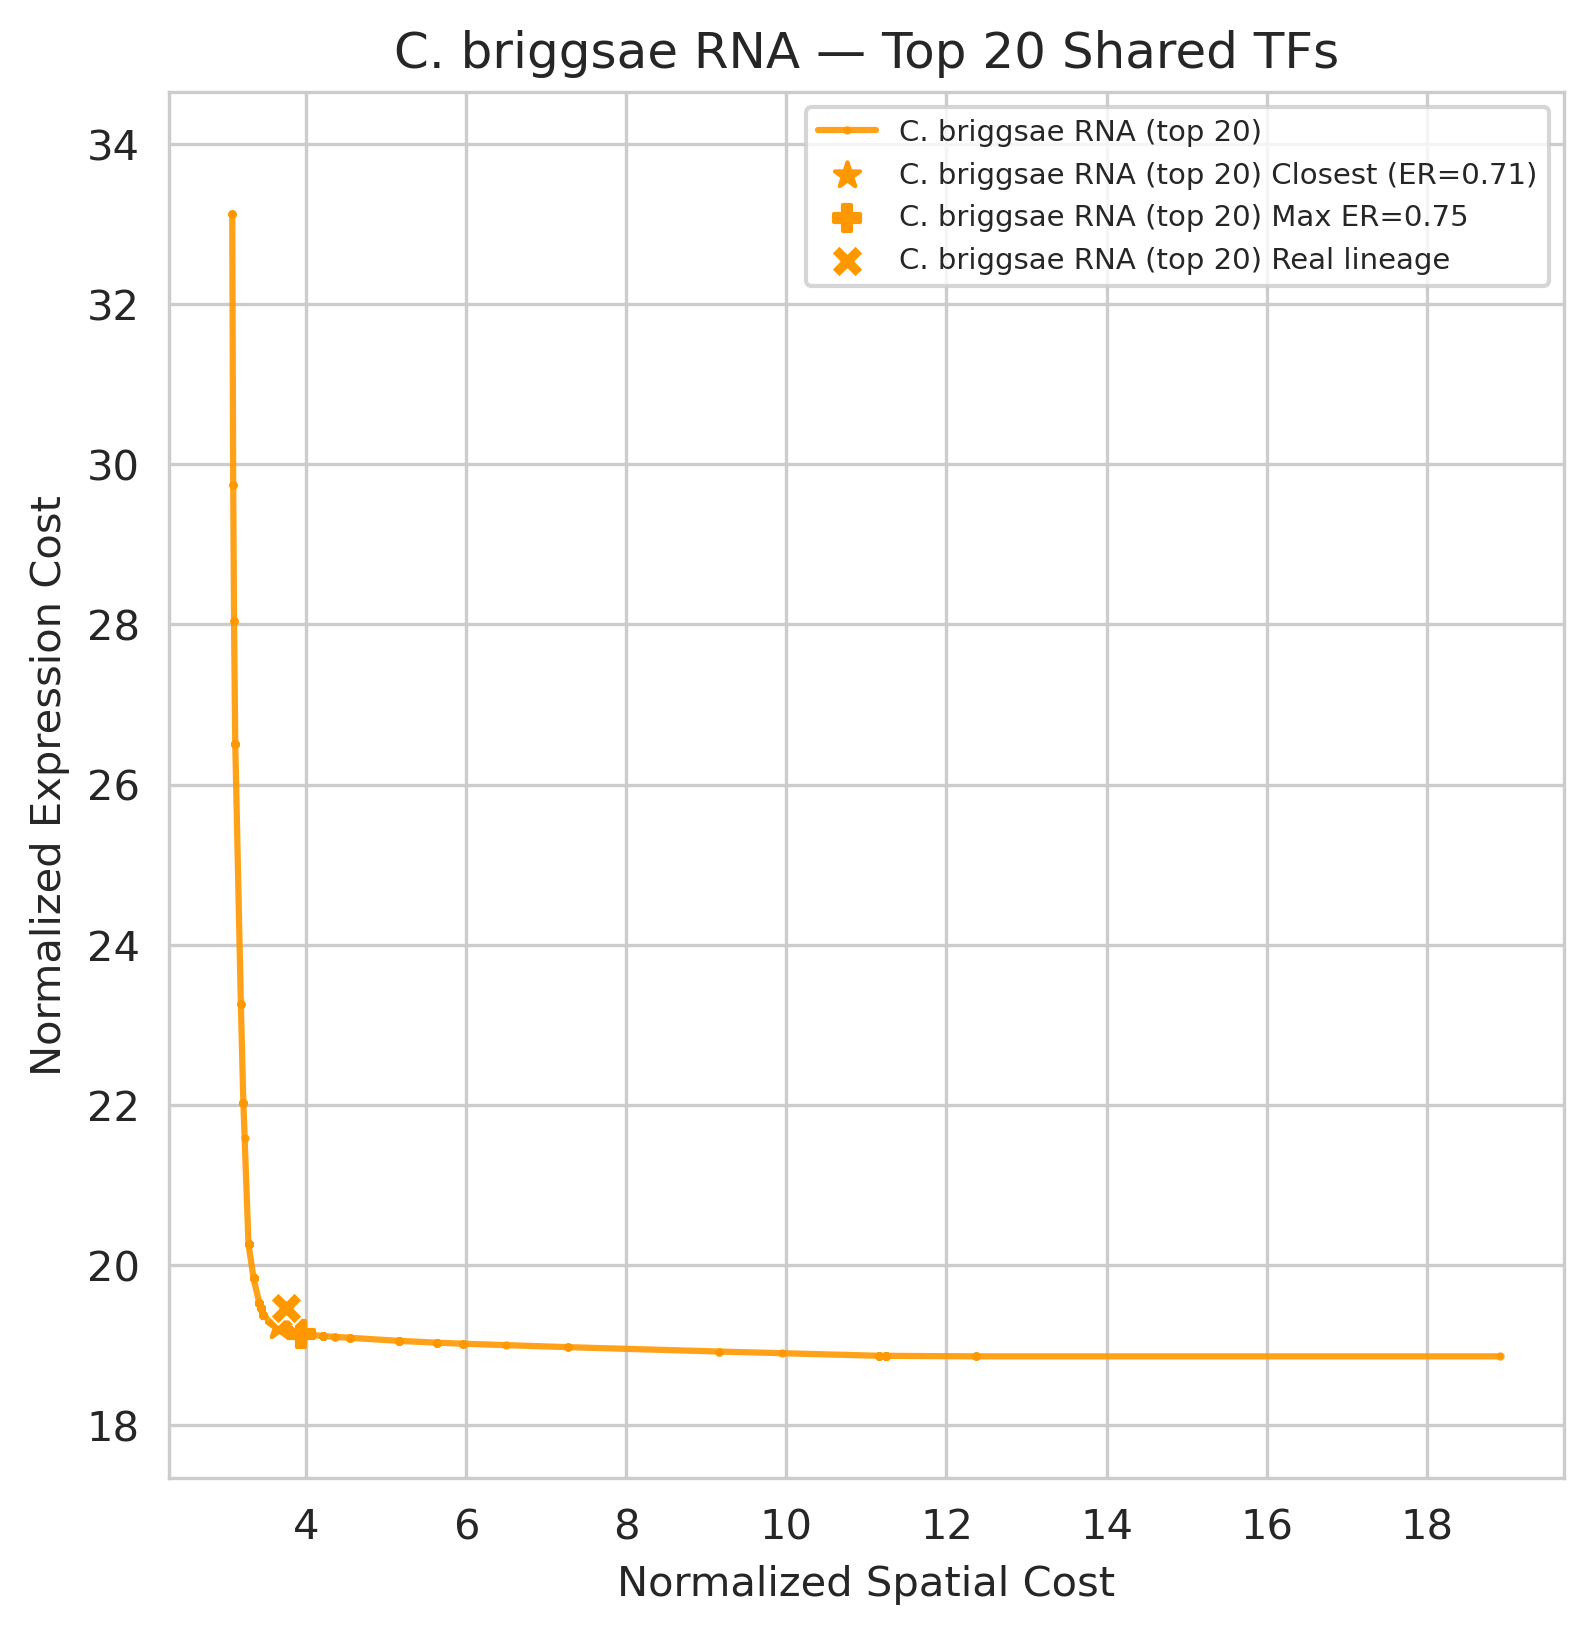

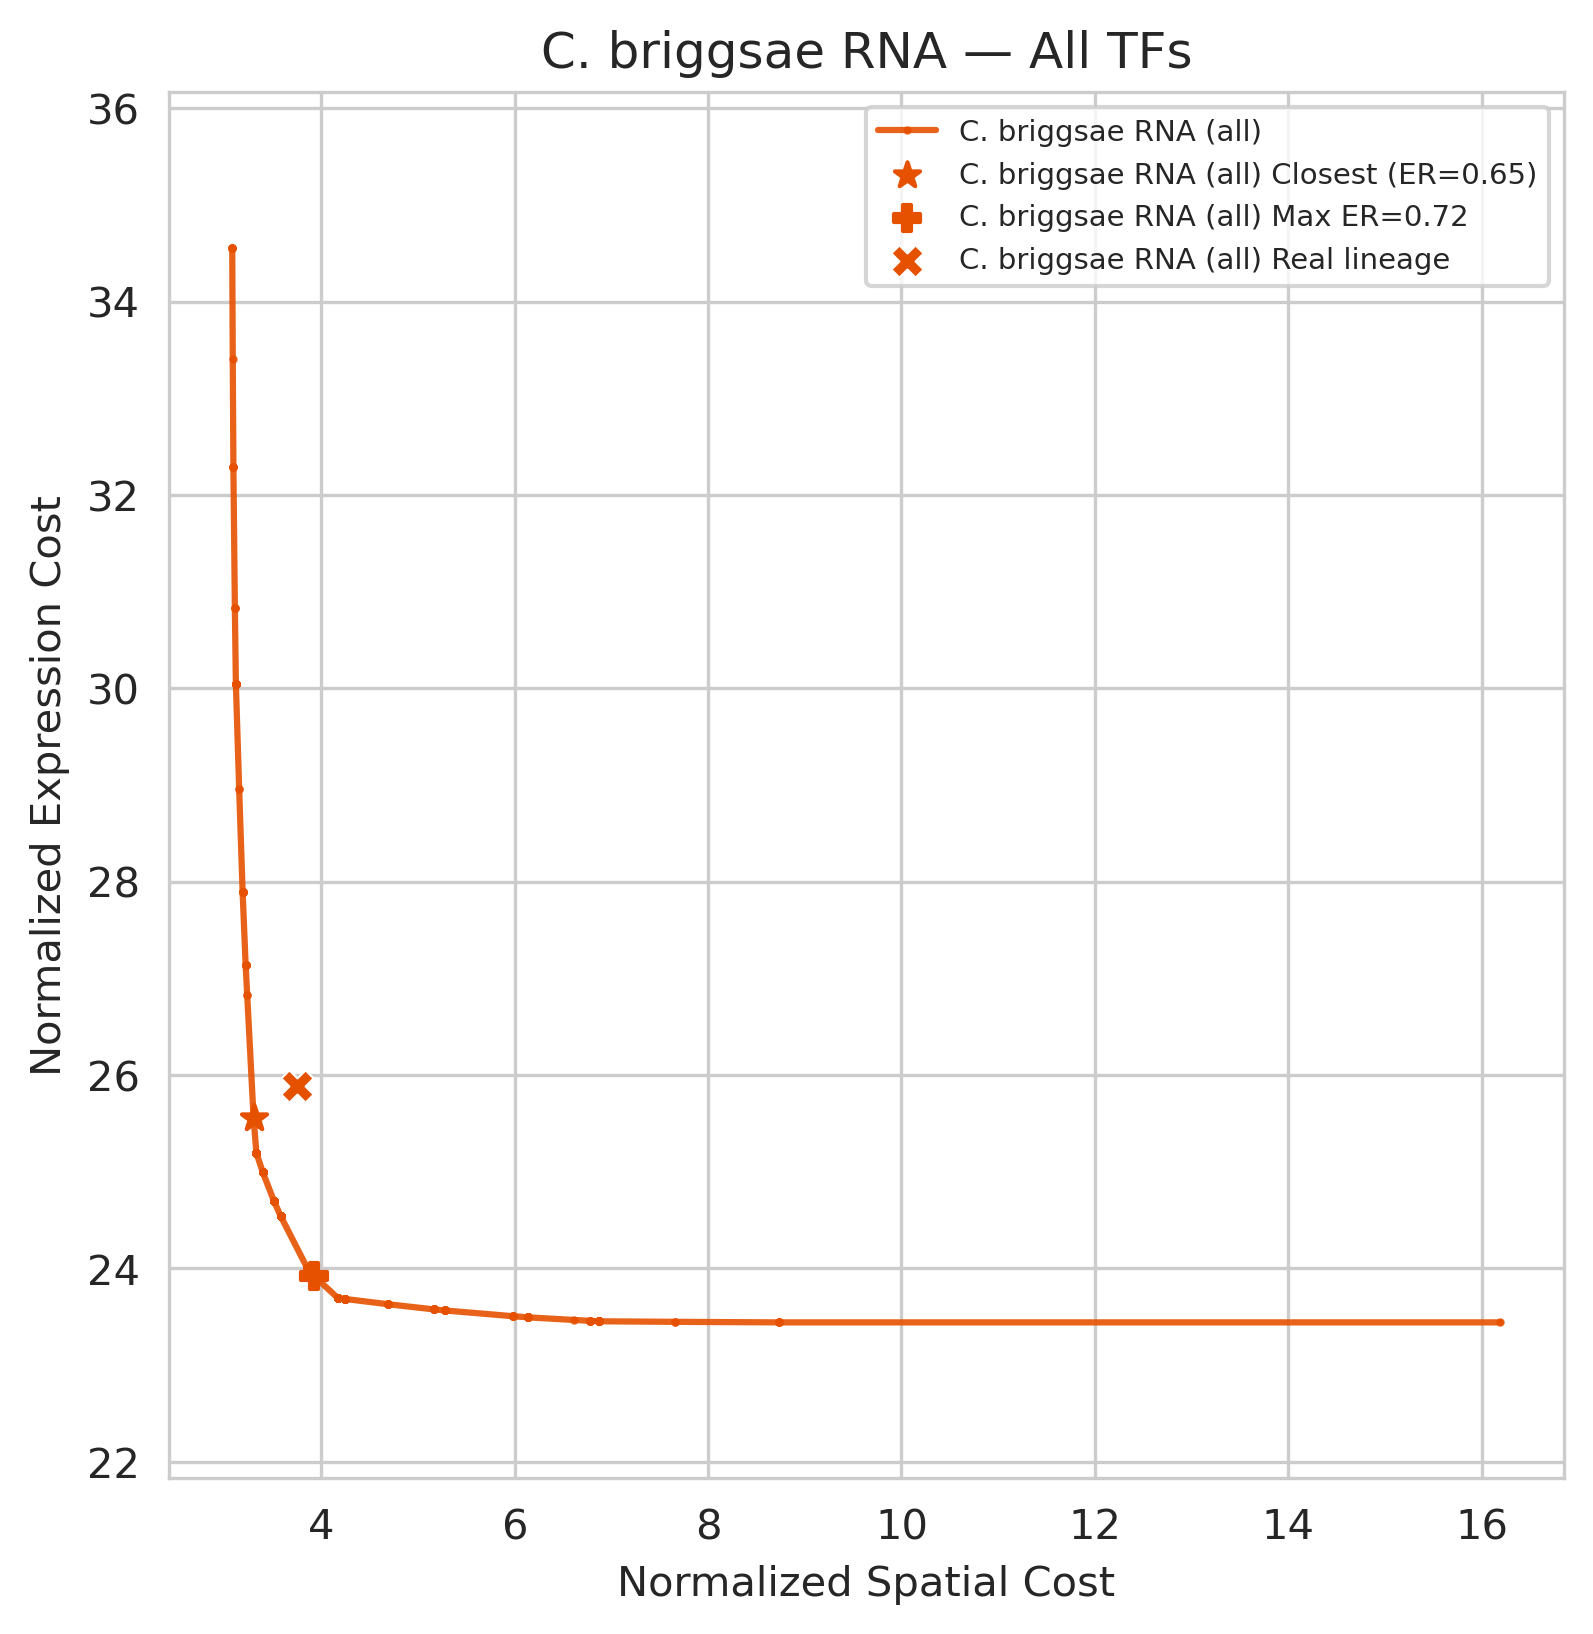

In [38]:
# ── Pareto front: C. briggsae RNA ──
print("=" * 60)
print("C. BRIGGSAE RNA — PARETO FRONT RESULTS")
print("=" * 60)

# 1) Top 20 shared TFs
res_cb = pareto_calculate(
    xyz_cost_cb, exp_cost_cb, briggsae_rna_term['terminal_parents'],
    plot_figure=True, figure_title="C. briggsae RNA — Top 20 Shared TFs",
    color='#FF9800', label='C. briggsae RNA (top 20)'
)
print_pareto_summary(res_cb, "Top 20 shared TFs")

# 2) All TFs
res_cb_all = pareto_calculate(
    xyz_cost_cb, all_exp_cost_cb, briggsae_rna_term['terminal_parents'],
    plot_figure=True, figure_title="C. briggsae RNA — All TFs",
    color='#E65100', label='C. briggsae RNA (all)'
)
print_pareto_summary(res_cb_all, f"All {briggsae_rna_full.shape[1]} TFs")


In [39]:
# ── Random baseline for C. briggsae RNA ──
print("Running random baseline for C. briggsae RNA...")

cb_random_mats = build_random_cost_matrices(
    briggsae_rna_term['terminal_parents'], briggsae_rna_term['terminal_nodes'],
    full_exp_dict_cb, n_features=20, n_random=1000
)

cb_random_results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(pareto_calculate)(xyz_cost_cb, rmat, briggsae_rna_term['terminal_parents'],
                              plot_figure=False)
    for rmat in tqdm(cb_random_mats, desc="Random baseline: C. briggsae RNA")
)

cb_rand_df = pd.DataFrame(cb_random_results)
print("\nRandom baseline summary (C. briggsae RNA, 20 random TFs, n=1000):")
print(f"  Spatial optimum ER:     {cb_rand_df['optimal_xyz_edge_ratio'].mean():.4f} ± {cb_rand_df['optimal_xyz_edge_ratio'].std():.4f}")
print(f"  Expression optimum ER:  {cb_rand_df['optimal_exp_edge_ratio'].mean():.4f} ± {cb_rand_df['optimal_exp_edge_ratio'].std():.4f}")
print(f"  Max edge ratio:         {cb_rand_df['largest_edge_ratio'].mean():.4f} ± {cb_rand_df['largest_edge_ratio'].std():.4f}")
print(f"  Closest distance:       {cb_rand_df['closest_distance'].mean():.4f} ± {cb_rand_df['closest_distance'].std():.4f}")
print(f"\nReal (top 20 shared TFs):")
print(f"  Spatial optimum ER:     {res_cb['optimal_xyz_edge_ratio']:.4f}")
print(f"  Expression optimum ER:  {res_cb['optimal_exp_edge_ratio']:.4f}")
print(f"  Max edge ratio:         {res_cb['largest_edge_ratio']:.4f}")
print(f"  Closest distance:       {res_cb['closest_distance']:.4f}")


Running random baseline for C. briggsae RNA...


Random feature matrices:   0%|          | 0/1000 [00:00<?, ?it/s]

Random feature matrices:  19%|█▉        | 192/1000 [00:00<00:00, 1201.05it/s]

Random feature matrices:  32%|███▏      | 320/1000 [00:00<00:00, 1172.73it/s]

Random feature matrices:  45%|████▍     | 448/1000 [00:00<00:00, 1139.33it/s]

...

Random baseline: C. briggsae RNA:  83%|████████▎ | 832/1000 [00:04<00:00, 176.96it/s]

Random baseline: C. briggsae RNA:  90%|████████▉ | 896/1000 [00:04<00:00, 180.60it/s]

Random baseline: C. briggsae RNA:  96%|█████████▌| 960/1000 [00:04<00:00, 178.16it/s]

Random baseline: C. briggsae RNA: 100%|██████████| 1000/1000 [00:04<00:00, 204.28it/s]


Random baseline summary (C. briggsae RNA, 20 random TFs, n=1000):
  Spatial optimum ER:     0.4928 ± 0.0000
  Expression optimum ER:  0.1176 ± 0.0511
  Max edge ratio:         0.7019 ± 0.0584
  Closest distance:       0.4782 ± 0.1259

Real (top 20 shared TFs):
  Spatial optimum ER:     0.4928
  Expression optimum ER:  0.1304
  Max edge ratio:         0.7536
  Closest distance:       0.2448


---
## Subtree Analysis — C. briggsae RNA

Same subtree analysis using C. briggsae scRNA-seq data with the shared top 20 TFs.
Key question: do the same lineage branches show similar patterns across species?


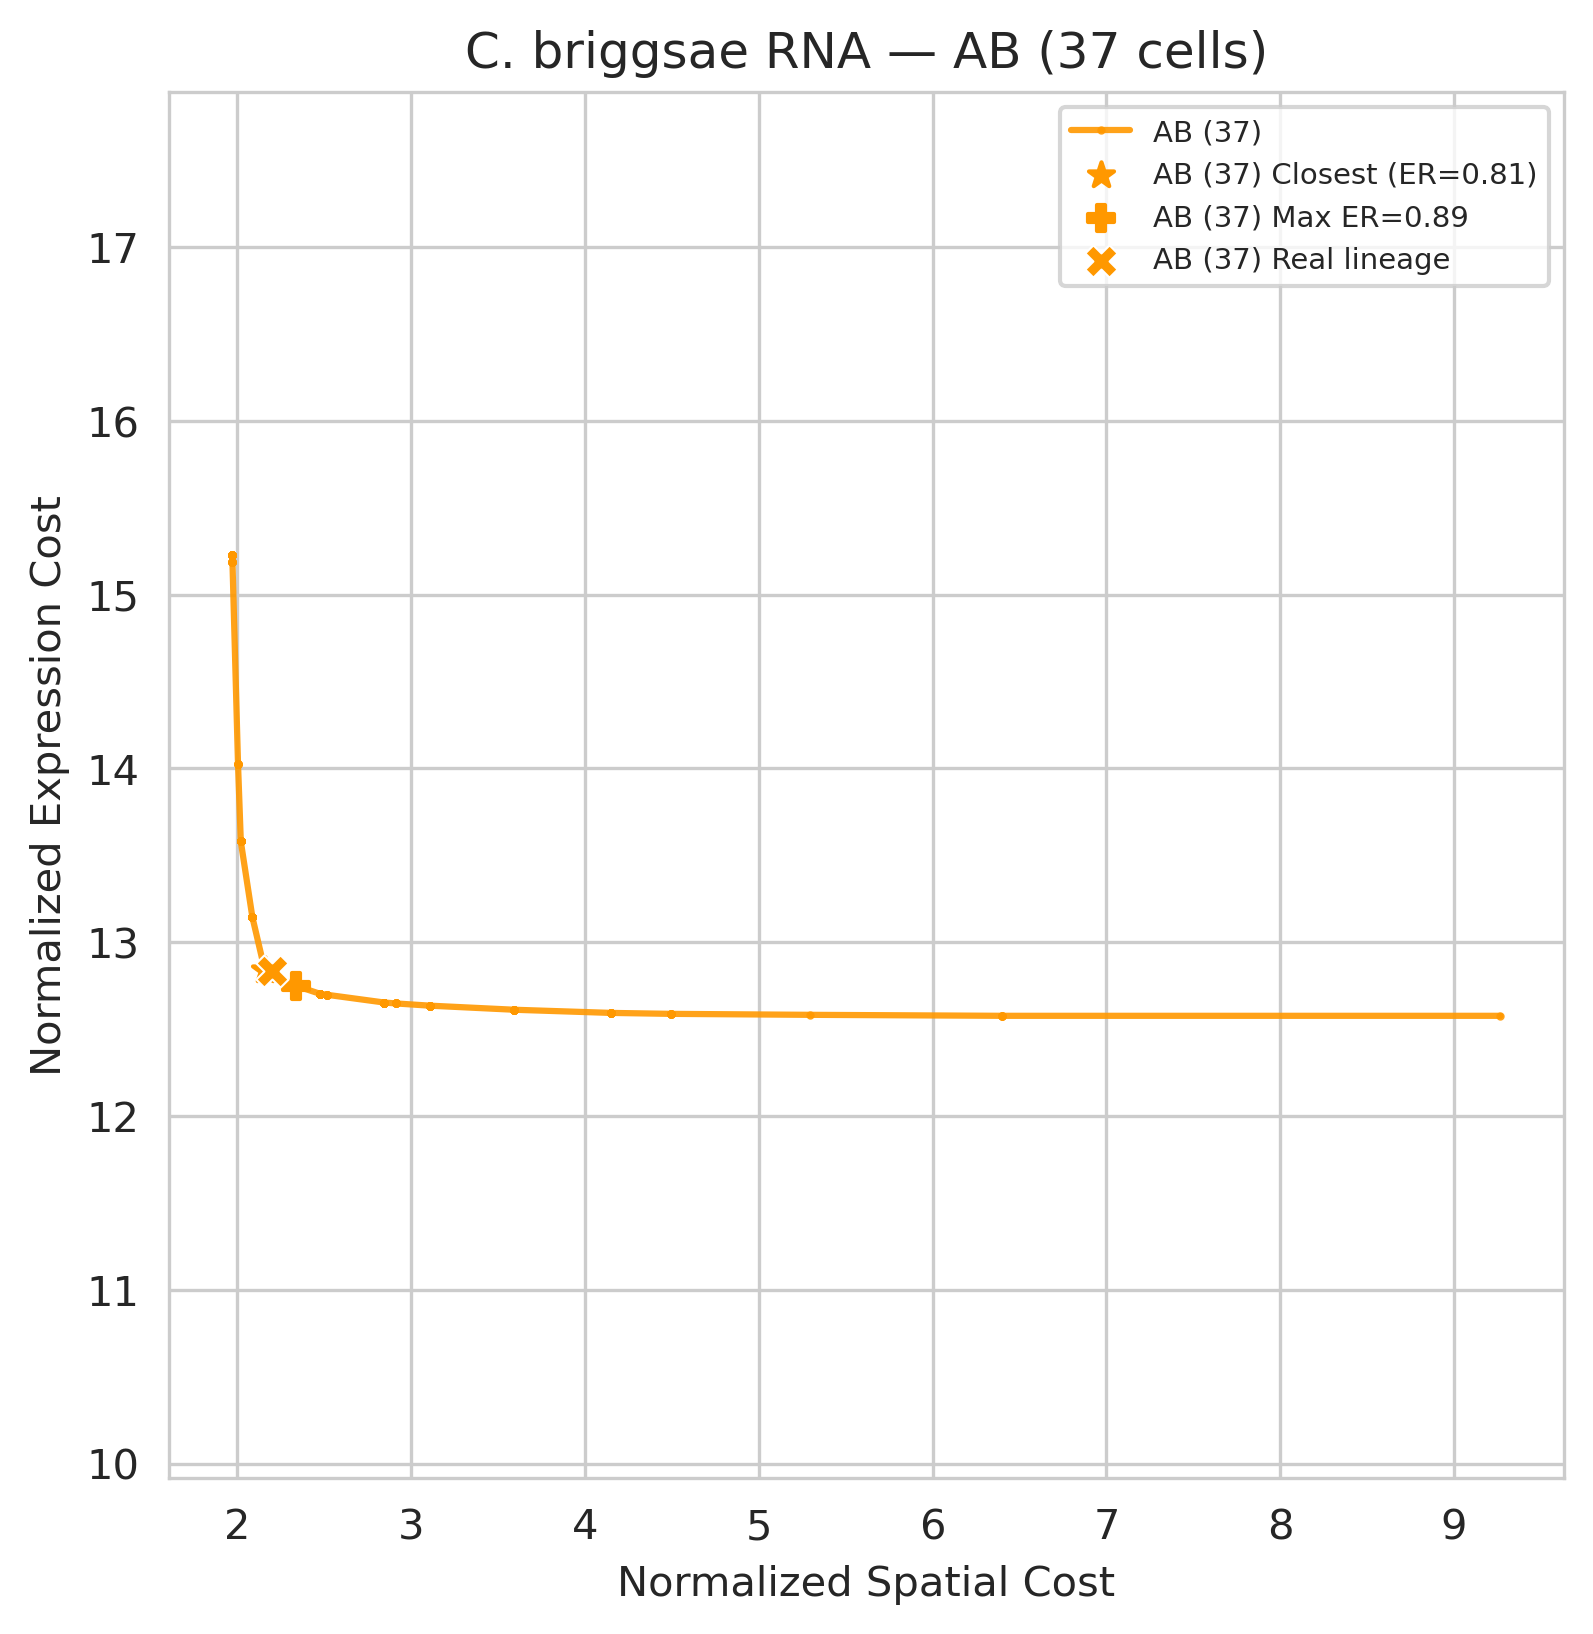

  AB          :   37 cells | Expr opt ER=0.243 | Max ER=0.892 | XYZ opt ER=0.838


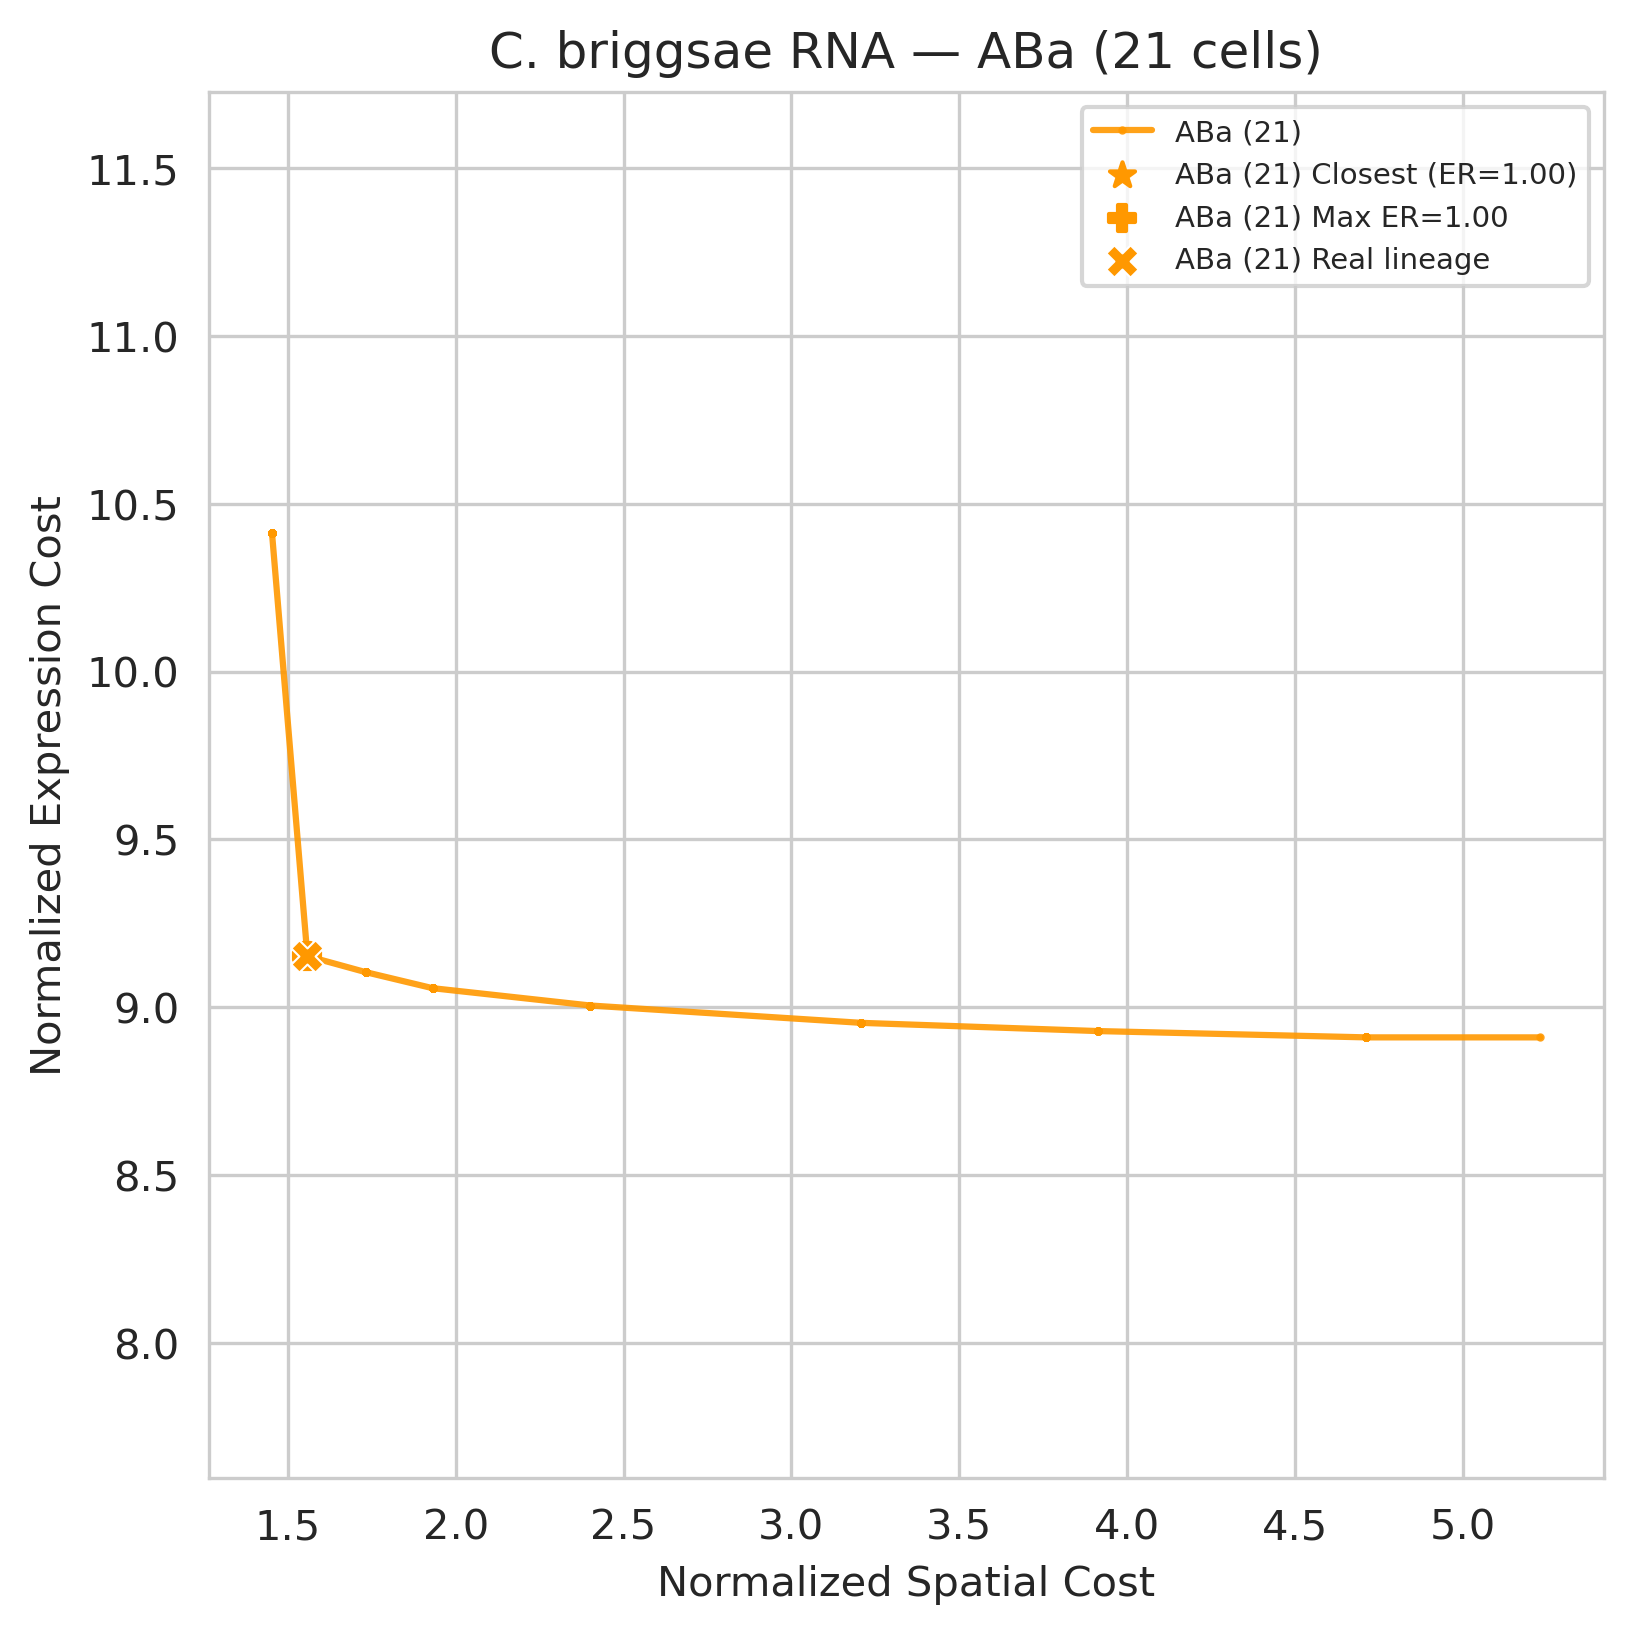

  ABa         :   21 cells | Expr opt ER=0.381 | Max ER=1.000 | XYZ opt ER=0.905


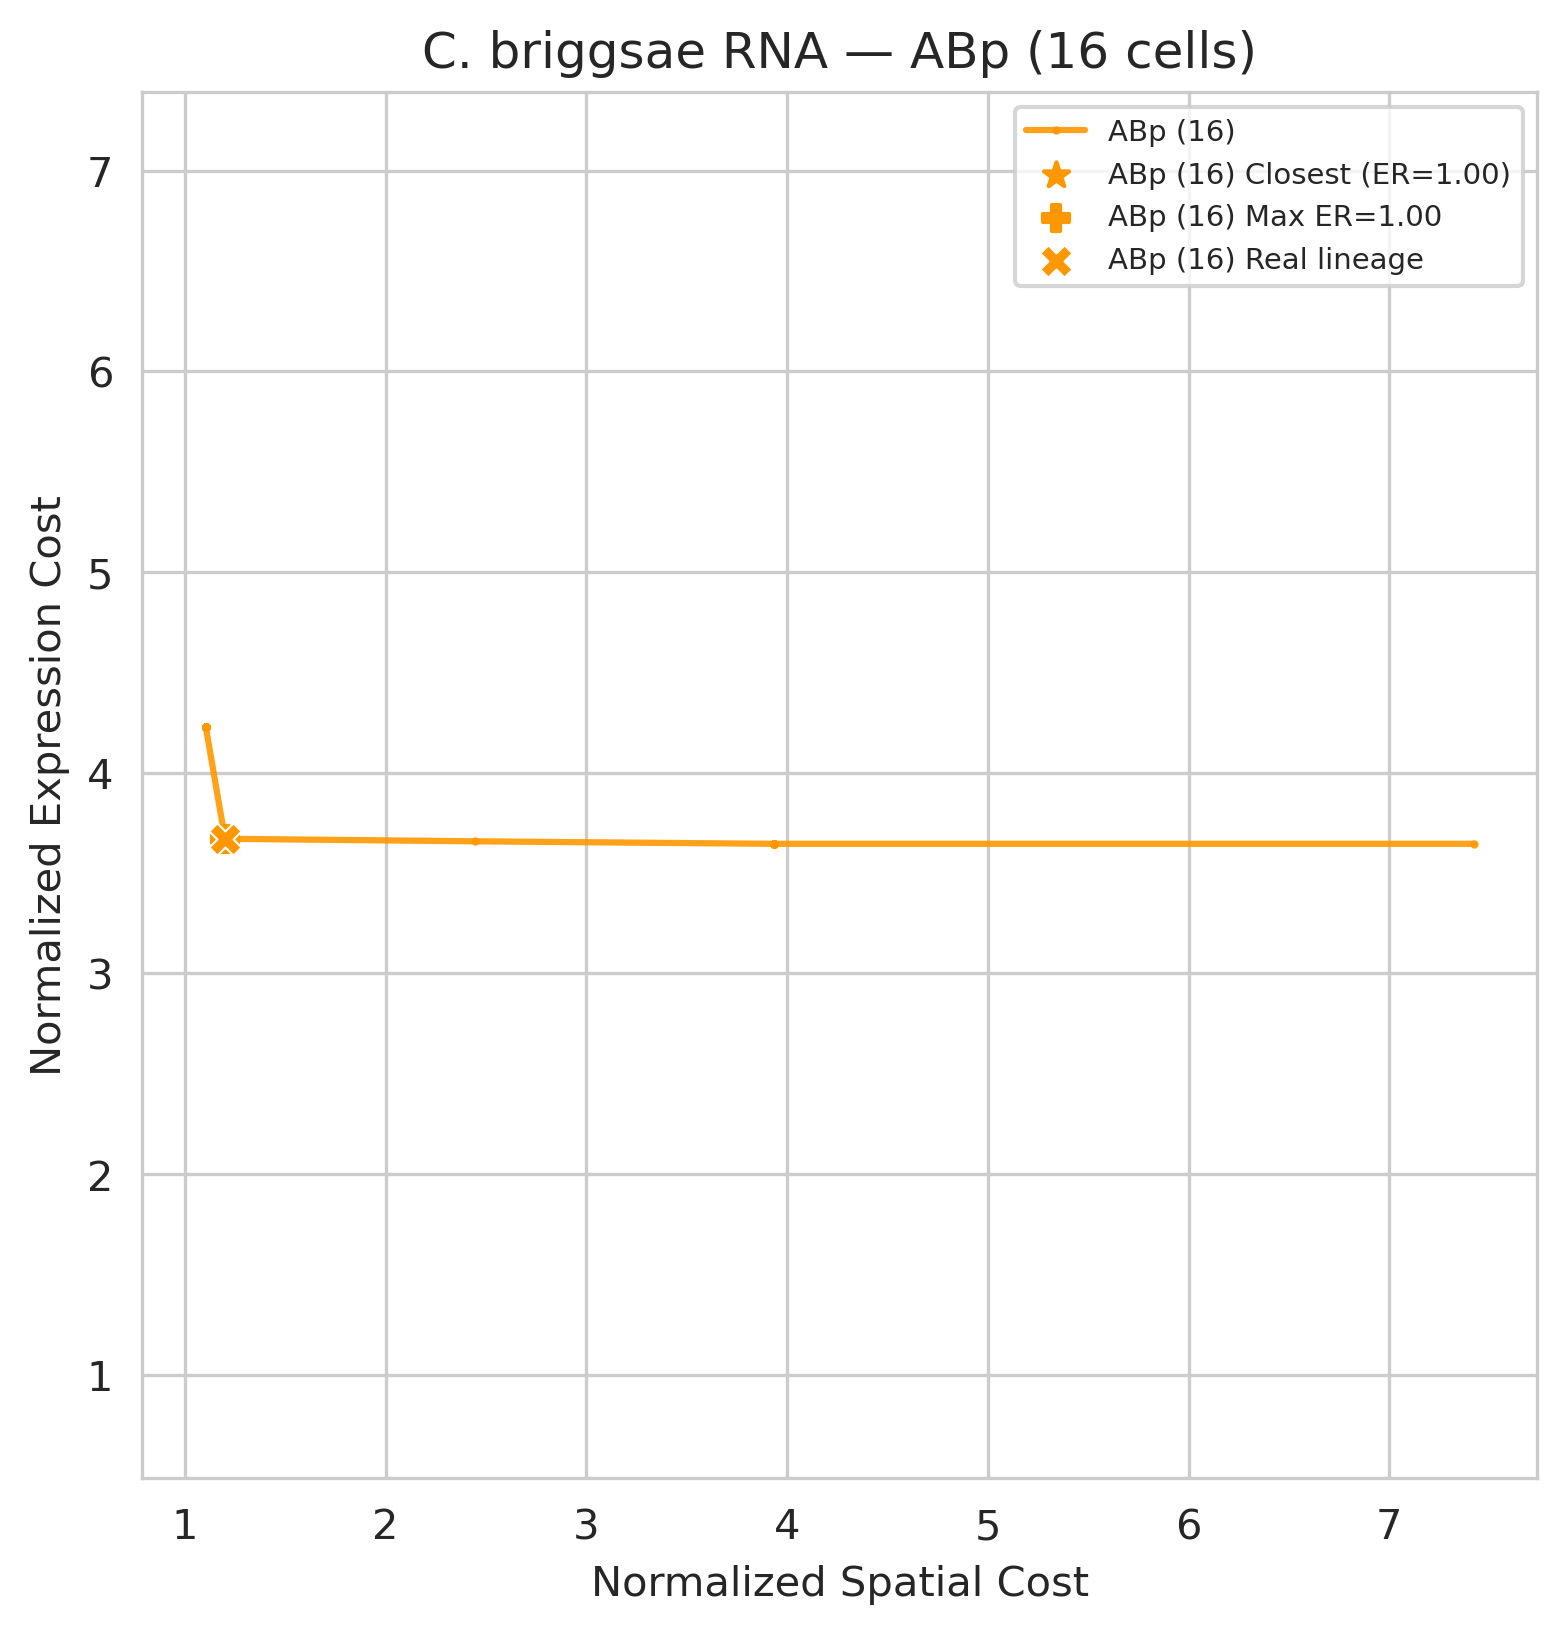

  ABp         :   16 cells | Expr opt ER=0.250 | Max ER=1.000 | XYZ opt ER=0.875


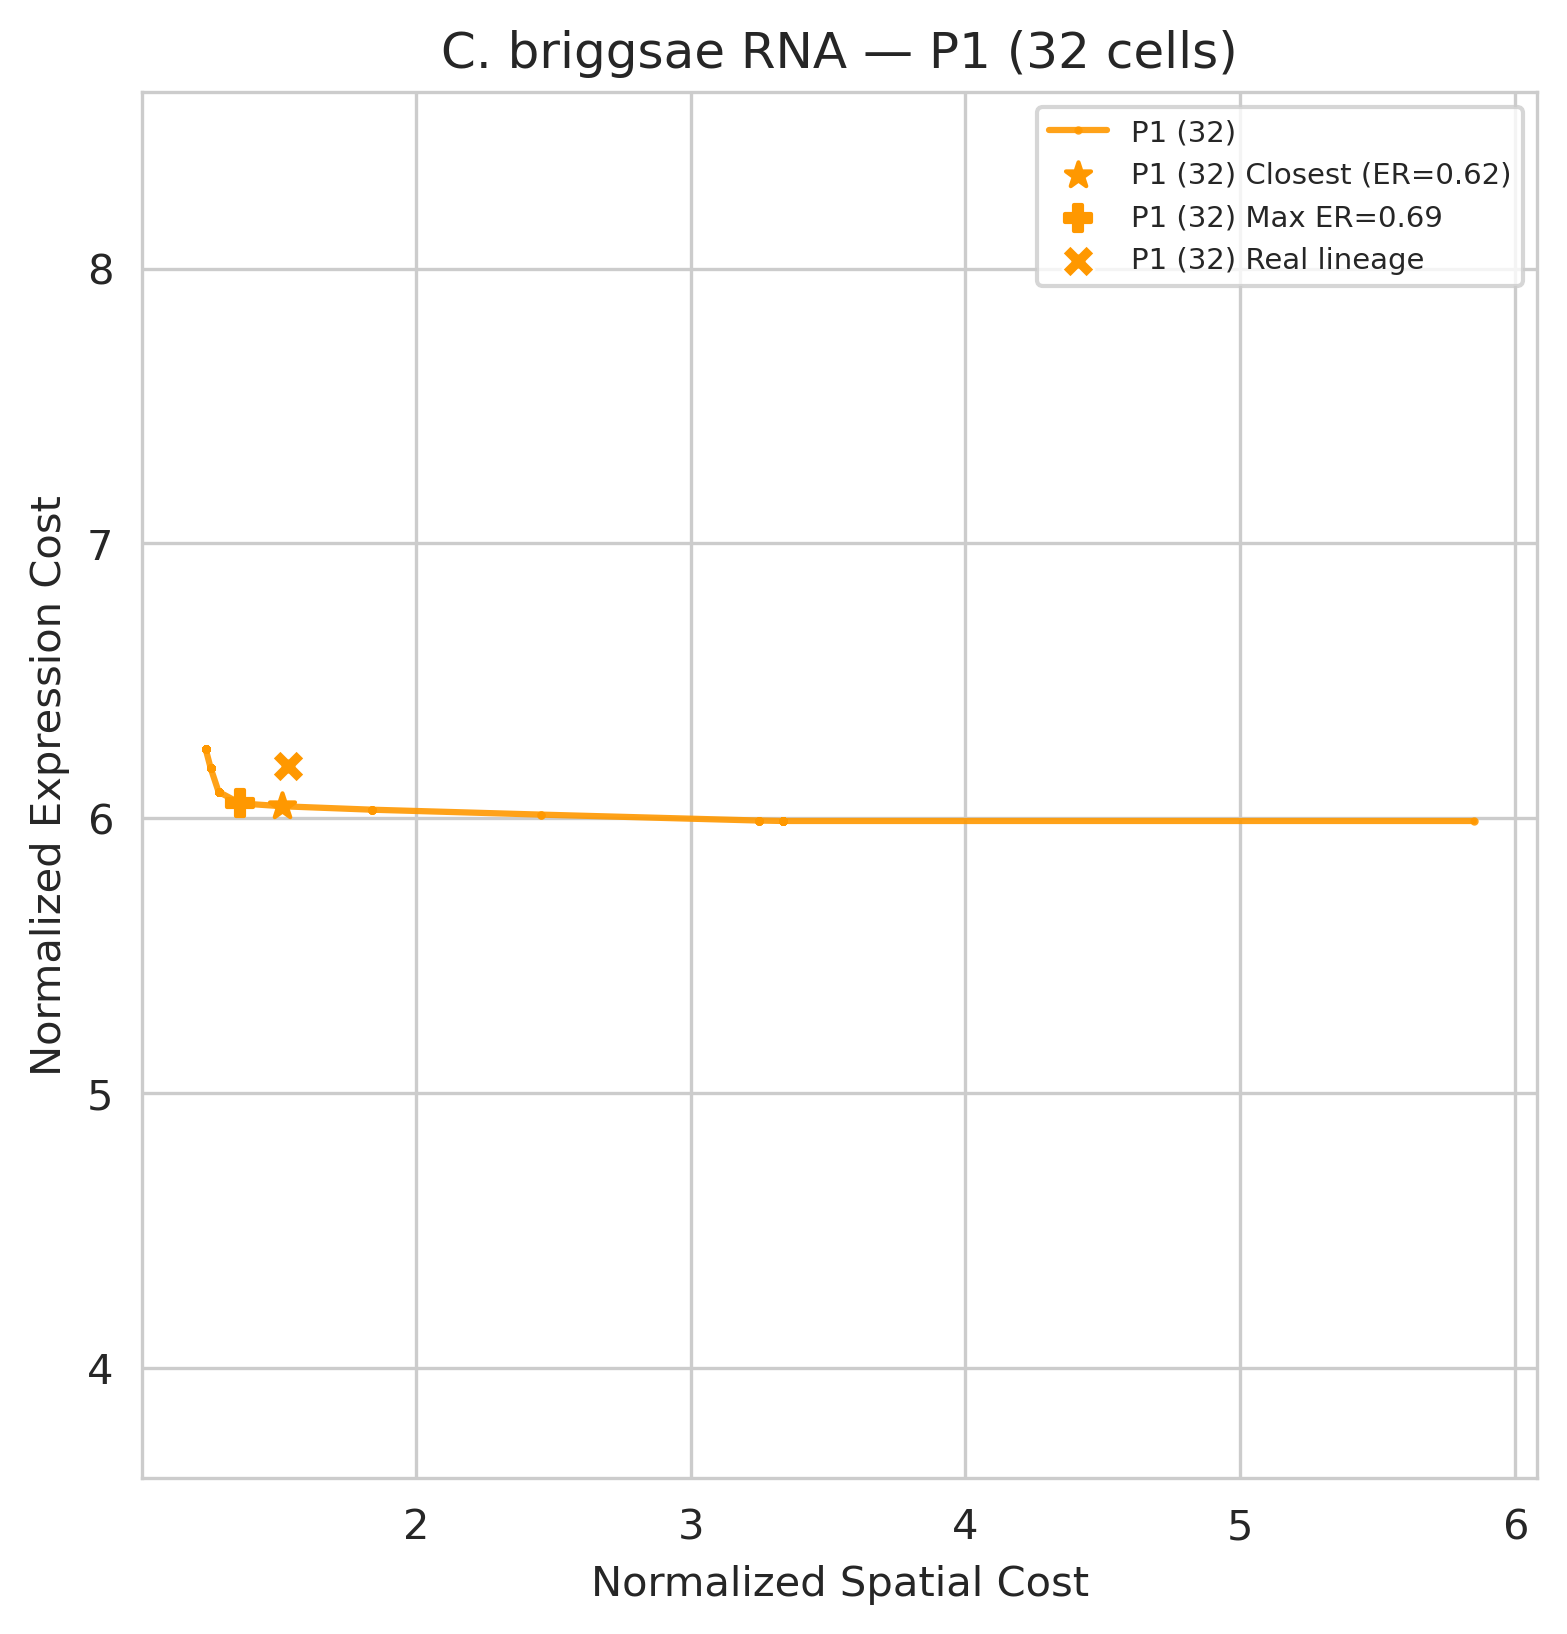

  P1          :   32 cells | Expr opt ER=0.375 | Max ER=0.688 | XYZ opt ER=0.625


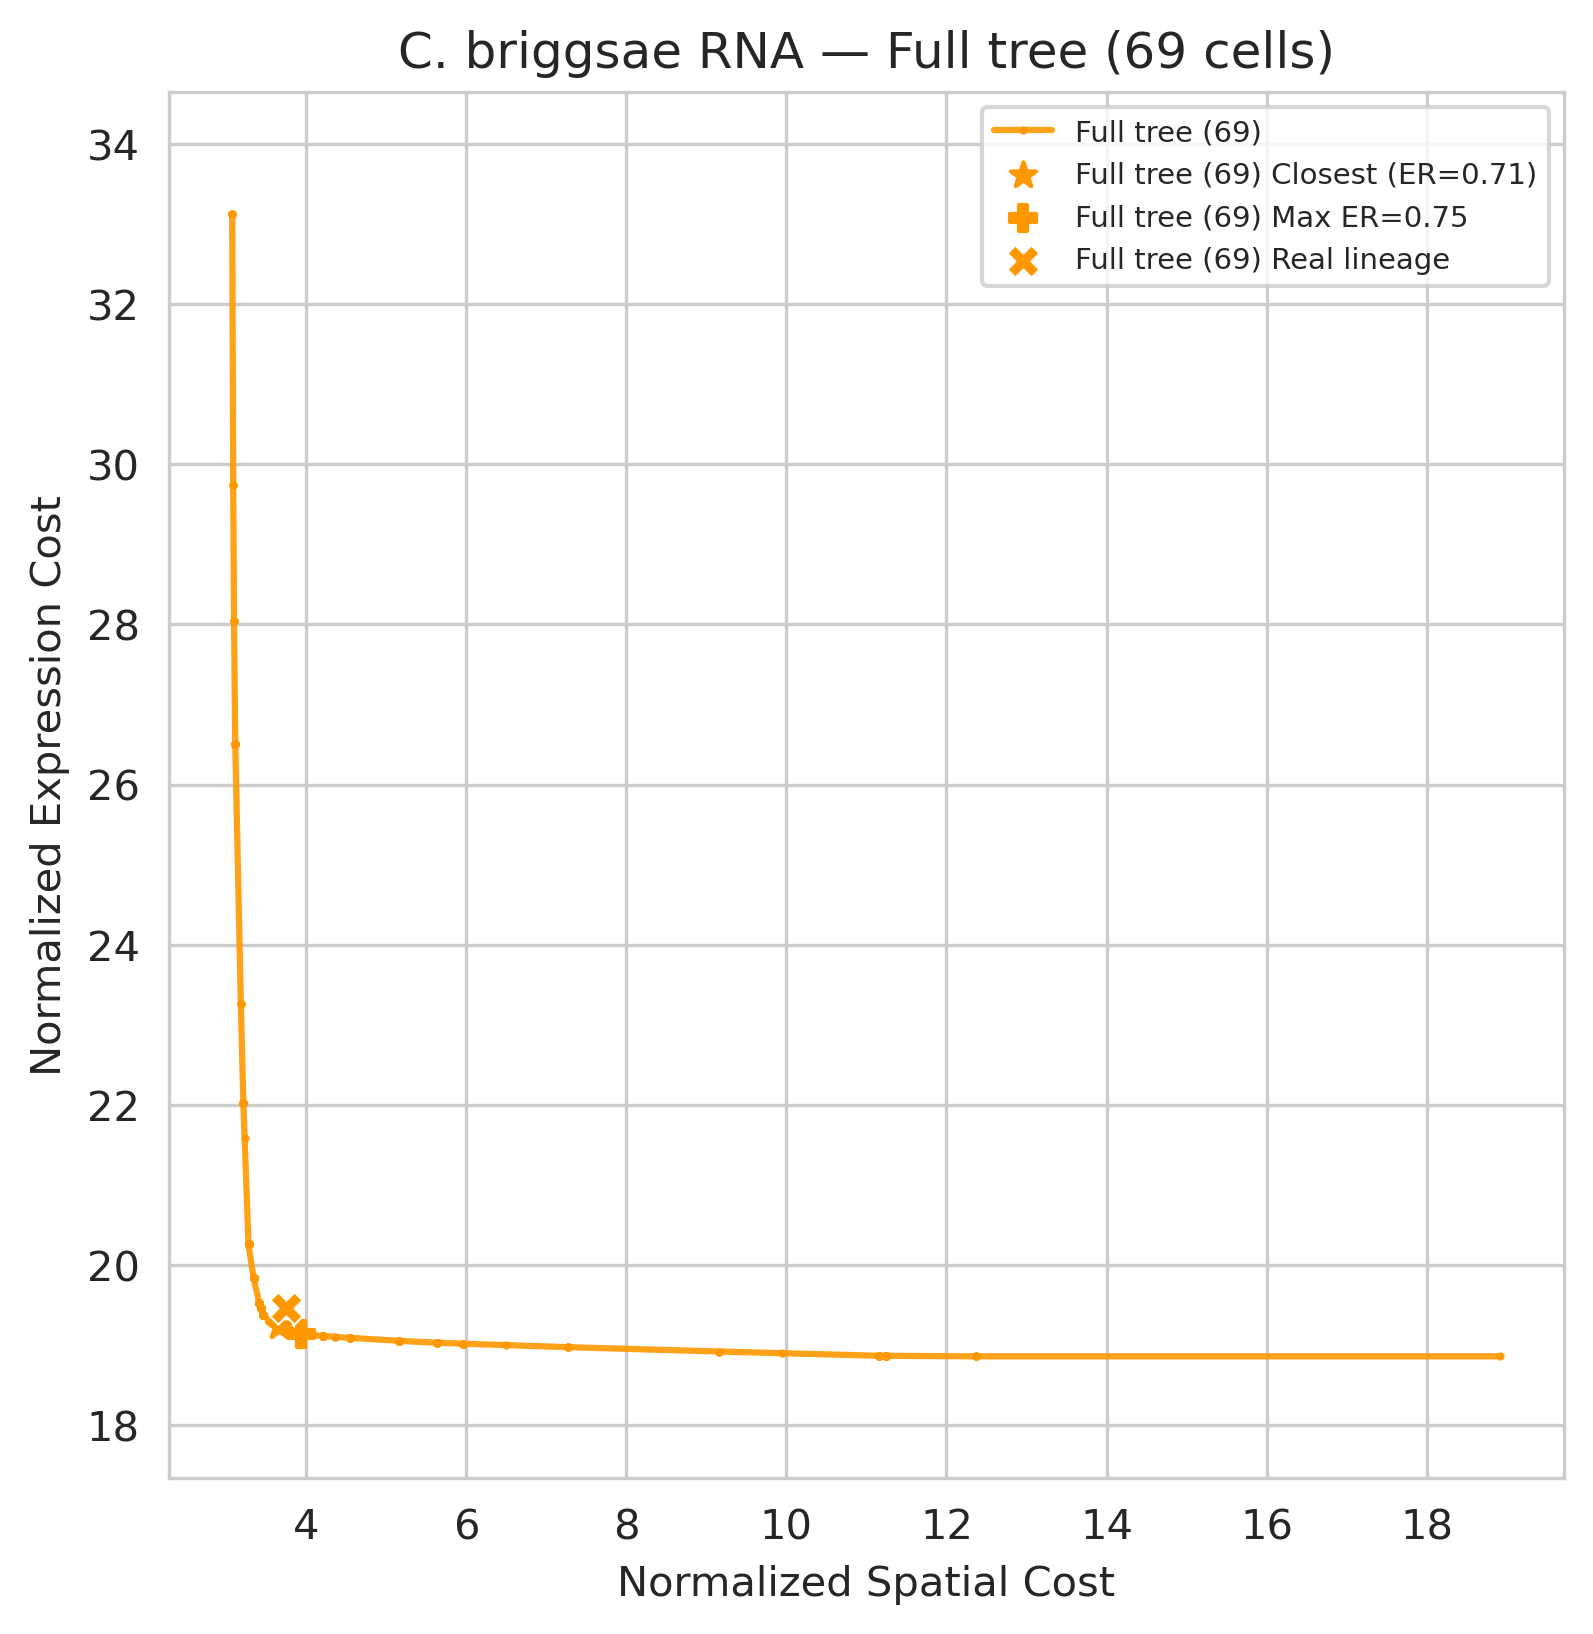

  Full tree   :   69 cells | Expr opt ER=0.130 | Max ER=0.754 | XYZ opt ER=0.493


In [40]:
# ═══════════════════════════════════════════════════════
# Subtree analysis: C. briggsae RNA (top 20 shared TFs)
# ═══════════════════════════════════════════════════════

cb_subtree_results = {}

for sroot in SUBTREE_ROOTS + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    
    if sroot == 'Full':
        term_data = briggsae_rna_term
    else:
        term_data = collect_terminal_cells(
            lineage_data, valid_cell_names_briggsae_rna,
            protein_exp_index=briggsae_rna_full.index,
            include_embryonic_terminals=False,
            include_apoptotic_cells=True,
            subtree_root_name=sroot
        )
    
    n_term = len(term_data['terminal_nodes'])
    
    xyz_mat, exp_mat, full_exp_dict, _ = build_cost_matrices(
        term_data['terminal_nodes'], term_data['terminal_parents'],
        all_xyz_map_briggsae, briggsae_rna_full, selected_features=rna_selected_features
    )
    
    res = pareto_calculate(
        xyz_mat, exp_mat, term_data['terminal_parents'],
        plot_figure=True, figure_title=f"C. briggsae RNA — {label} ({n_term} cells)",
        color='#FF9800', label=f'{label} ({n_term})'
    )
    plt.show()
    
    cb_subtree_results[label] = {
        'term_data': term_data, 'xyz_mat': xyz_mat, 'exp_mat': exp_mat,
        'full_exp_dict': full_exp_dict, 'pareto': res,
    }
    
    print(f"  {label:12s}: {n_term:4d} cells | "
          f"Expr opt ER={res['optimal_exp_edge_ratio']:.3f} | "
          f"Max ER={res['largest_edge_ratio']:.3f} | "
          f"XYZ opt ER={res['optimal_xyz_edge_ratio']:.3f}")


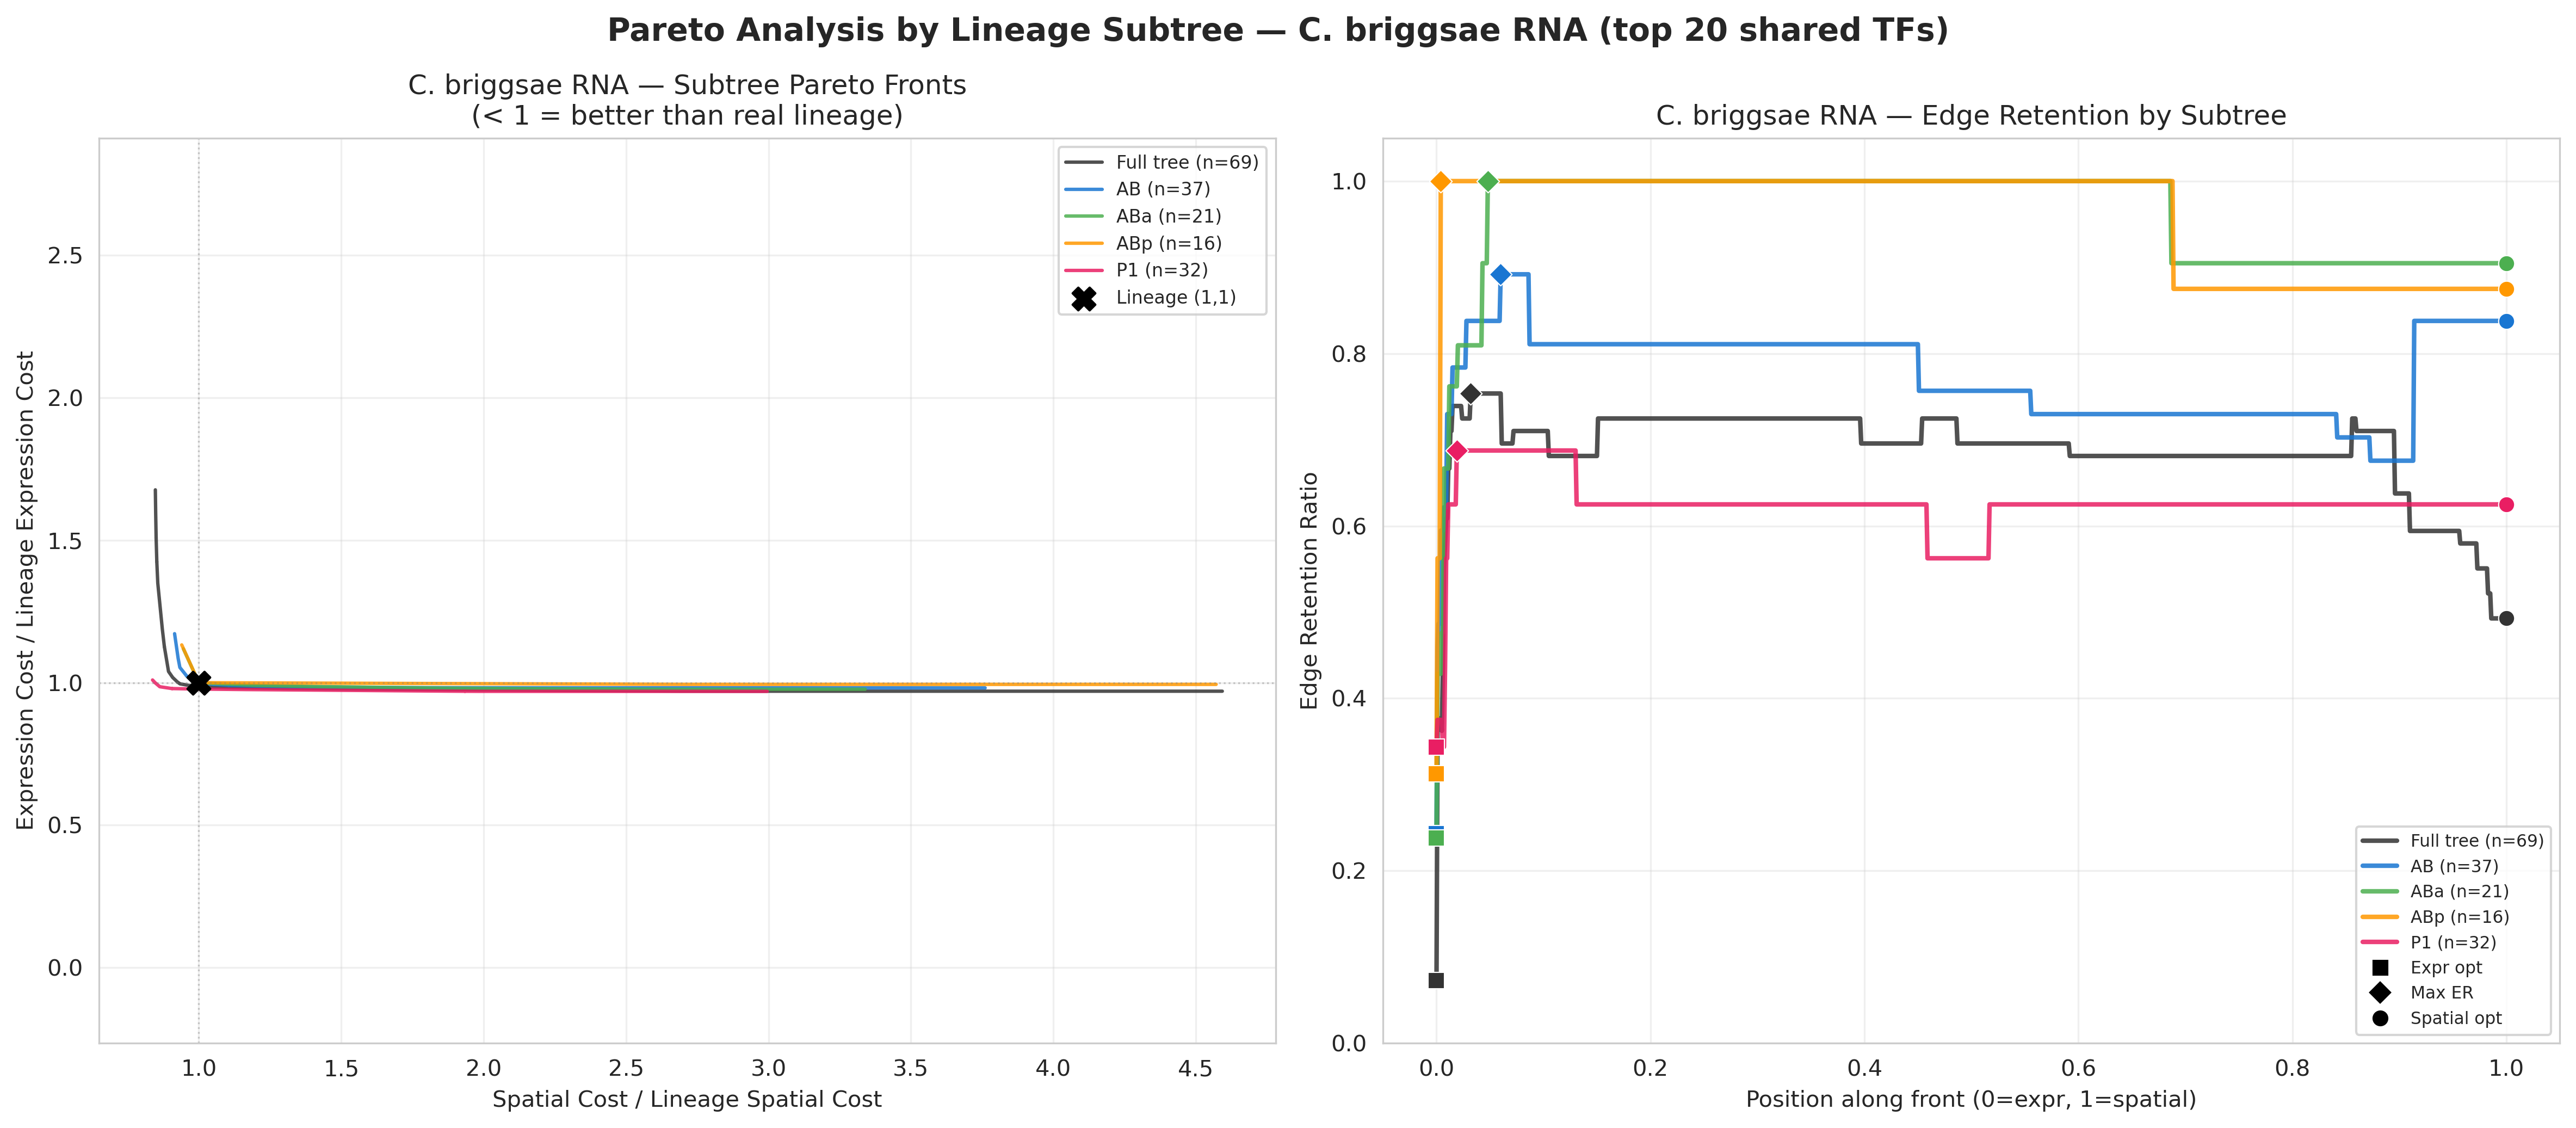


CROSS-SPECIES SUBTREE COMPARISON: Expr Opt ER
Subtree      | C. elegans Protein   | C. elegans RNA       | C. briggsae RNA     
--------------------------------------------------------------------------------
Full tree    | 0.204 (n=299)        | 0.074 (n=231)        | 0.130 (n= 69)
AB           | 0.218 (n=216)        | 0.083 (n=157)        | 0.243 (n= 37)
ABa          | 0.302 (n=106)        | 0.137 (n= 73)        | 0.381 (n= 21)
ABp          | 0.245 (n=110)        | 0.107 (n= 84)        | 0.250 (n= 16)
P1           | 0.337 (n= 83)        | 0.176 (n= 74)        | 0.375 (n= 32)

Subtree      | C. elegans Protein   | C. elegans RNA       | C. briggsae RNA     
--------------------------------------------------------------------------------
Full tree    | Max ER=0.819              | Max ER=0.805              | Max ER=0.754
AB           | Max ER=0.838              | Max ER=0.936              | Max ER=0.892
ABa          | Max ER=0.887              | Max ER=0.945              | Max ER=1.000

In [41]:
# Shared helpers (also defined in protein section above)
def _compute_ratio_pareto(xyz_cost_mat, exp_cost_mat, terminal_parents, iteration=1000):
    lineage_xyz = xyz_cost_mat.diagonal().sum()
    lineage_exp = exp_cost_mat.diagonal().sum()
    xyz_rel = xyz_cost_mat / lineage_xyz; exp_rel = exp_cost_mat / lineage_exp
    xyz_list, exp_list, edge_ratios = [], [], []
    for i in range(iteration + 1):
        alpha = i / iteration
        row_ind, col_ind = linear_sum_assignment(alpha * xyz_rel + (1 - alpha) * exp_rel)
        xyz_list.append(xyz_rel[row_ind, col_ind].sum())
        exp_list.append(exp_rel[row_ind, col_ind].sum())
        edge_ratios.append(lineage_edge_ratio(row_ind, col_ind, terminal_parents))
    edge_ratios = np.array(edge_ratios)
    max_er_idx = int(np.argmax(edge_ratios))
    key_points = {"expr_opt_idx": 0, "xyz_opt_idx": iteration, "max_er_idx": max_er_idx}
    return np.array(xyz_list), np.array(exp_list), edge_ratios, key_points

subtree_colors = {"Full tree": "#333333", "AB": "#1976D2", "ABa": "#4CAF50", "ABp": "#FF9800", "P1": "#E91E63"}
x_front = np.linspace(0, 1, 1001)
_markers = {"expr_opt_idx": ("s", "Expr opt"), "max_er_idx": ("D", "Max ER"), "xyz_opt_idx": ("o", "Spatial opt")}

# ── Visualize: C. briggsae RNA subtree Pareto fronts ──

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))

for label in subtree_labels:
    sr = cb_subtree_results[label]
    xyz_arr, exp_arr, edge_arr, key_pts = _compute_ratio_pareto(
        sr['xyz_mat'], sr['exp_mat'], sr['term_data']['terminal_parents'])
    color = subtree_colors[label]
    n = len(sr['term_data']['terminal_nodes'])
    
    ax_left.plot(xyz_arr, exp_arr, color=color, linewidth=1.5, alpha=0.85,
                 label=f'{label} (n={n})')
    ax_left.scatter(1.0, 1.0, color=color, marker='X', s=70, edgecolors='white', linewidth=0.8, zorder=6)
    
    ax_right.plot(x_front, edge_arr, color=color, linewidth=2, alpha=0.85, label=f'{label} (n={n})')
    for pt_key, (marker, _) in _markers.items():
        idx = key_pts[pt_key]
        ax_right.scatter(x_front[idx], edge_arr[idx], color=color, marker=marker,
                        s=50, zorder=8, edgecolors='white', linewidth=0.5)

ax_left.axvline(x=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.axhline(y=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.scatter([1.0], [1.0], color='black', marker='X', s=100, zorder=10, label='Lineage (1,1)')
ax_left.set_xlabel('Spatial Cost / Lineage Spatial Cost'); ax_left.set_ylabel('Expression Cost / Lineage Expression Cost')
ax_left.set_title('C. briggsae RNA — Subtree Pareto Fronts\n(< 1 = better than real lineage)', fontsize=12)
ax_left.legend(fontsize=8, loc='upper right'); ax_left.axis('equal'); ax_left.grid(True, alpha=0.3)

legend_lines = list(ax_right.get_lines()) + [
    Line2D([0], [0], color='black', marker='s', linestyle='', markersize=6, label='Expr opt'),
    Line2D([0], [0], color='black', marker='D', linestyle='', markersize=6, label='Max ER'),
    Line2D([0], [0], color='black', marker='o', linestyle='', markersize=6, label='Spatial opt'),
]
ax_right.legend(handles=legend_lines, fontsize=7.5, loc='best')
ax_right.set_xlabel('Position along front (0=expr, 1=spatial)')
ax_right.set_ylabel('Edge Retention Ratio')
ax_right.set_title('C. briggsae RNA — Edge Retention by Subtree', fontsize=12)
ax_right.set_ylim(0, 1.05); ax_right.grid(True, alpha=0.3)

fig.suptitle('Pareto Analysis by Lineage Subtree — C. briggsae RNA (top 20 shared TFs)',
             fontsize=14, fontweight='bold')
fig.tight_layout(); plt.show()


# ── Cross-species comparison table ──
print("\n" + "=" * 80)
print("CROSS-SPECIES SUBTREE COMPARISON: Expr Opt ER")
print("=" * 80)
print(f"{'Subtree':12s} | {'C. elegans Protein':20s} | {'C. elegans RNA':20s} | {'C. briggsae RNA':20s}")
print("-" * 80)
for label in subtree_labels:
    prot_er = subtree_results[label]['pareto']['optimal_exp_edge_ratio']
    prot_n = len(subtree_results[label]['term_data']['terminal_nodes'])
    rna_er = er_subtree_results[label]['pareto']['optimal_exp_edge_ratio']
    rna_n = len(er_subtree_results[label]['term_data']['terminal_nodes'])
    cb_er = cb_subtree_results[label]['pareto']['optimal_exp_edge_ratio']
    cb_n = len(cb_subtree_results[label]['term_data']['terminal_nodes'])
    print(f"{label:12s} | {prot_er:.3f} (n={prot_n:3d})        | {rna_er:.3f} (n={rna_n:3d})        | {cb_er:.3f} (n={cb_n:3d})")

print(f"\n{'Subtree':12s} | {'C. elegans Protein':20s} | {'C. elegans RNA':20s} | {'C. briggsae RNA':20s}")
print("-" * 80)
for label in subtree_labels:
    prot_er = subtree_results[label]['pareto']['largest_edge_ratio']
    rna_er = er_subtree_results[label]['pareto']['largest_edge_ratio']
    cb_er = cb_subtree_results[label]['pareto']['largest_edge_ratio']
    print(f"{label:12s} | Max ER={prot_er:.3f}              | Max ER={rna_er:.3f}              | Max ER={cb_er:.3f}")


---
## Comparative Analysis


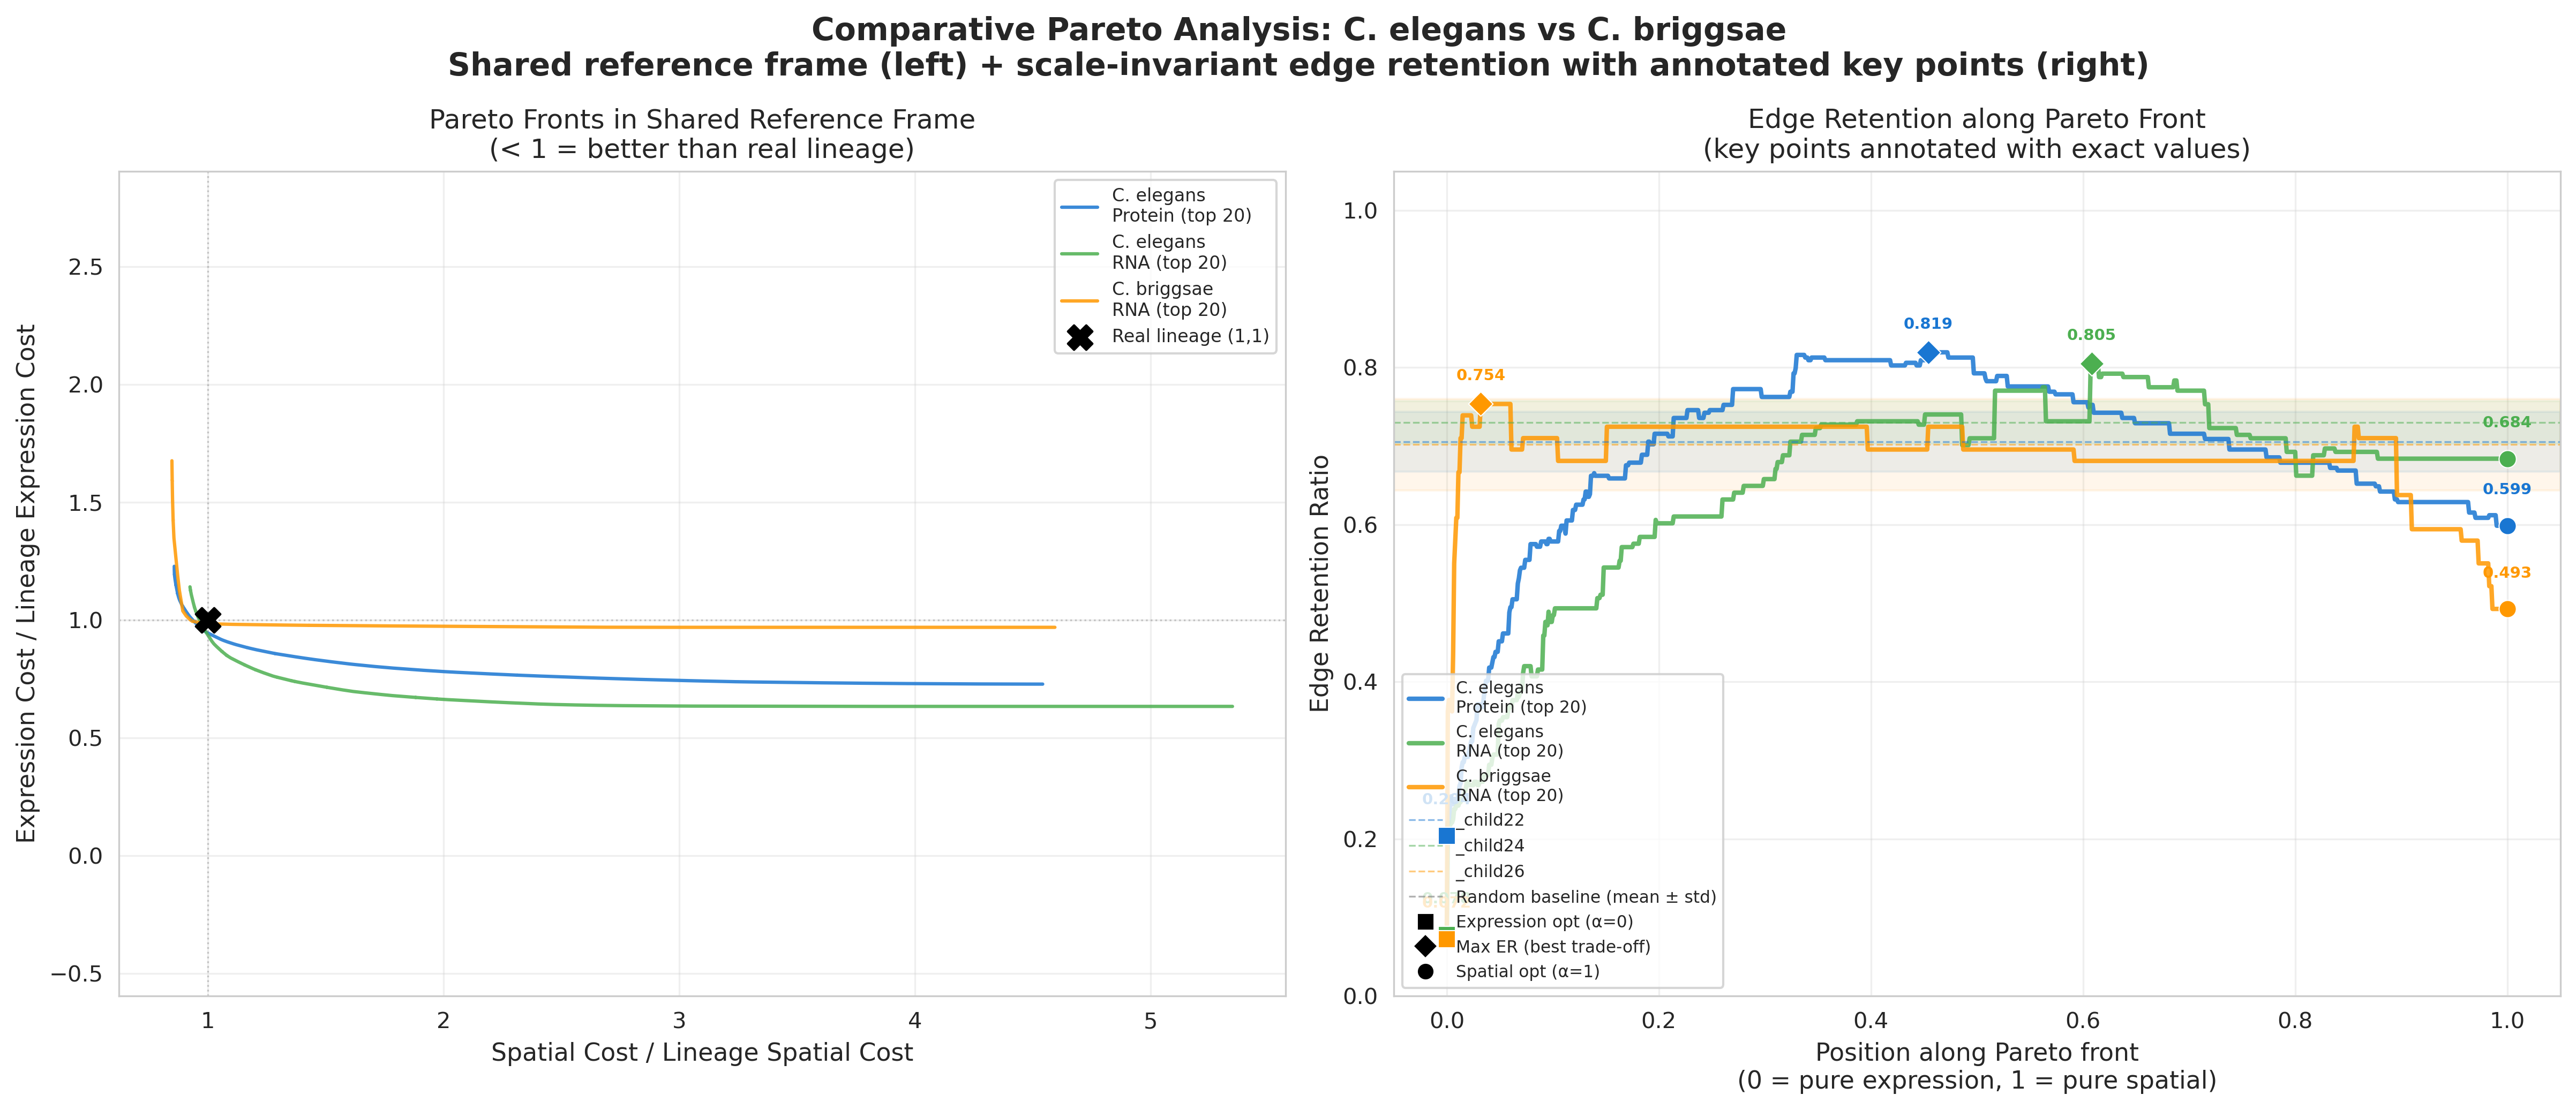

In [42]:
# ═══════════════════════════════════════════════════════════
# COMPARATIVE VISUALIZATION: Shared reference frame
# ═══════════════════════════════════════════════════════════
#
# Problem: min-max normalization gives each dataset its own coordinate
# system, making overlays misleading.  Solution: express all costs as
# RATIOS of the real lineage cost.  The lineage point is always at (1,1),
# and the Pareto front shows how much improvement is possible over the
# real lineage on each axis.  Values < 1 = better than real lineage;
# values > 1 = worse.
#
# We pair this with a second panel showing edge retention along the
# front — a genuinely scale-invariant metric.  Key points (expression
# optimum, spatial optimum, max ER) are marked explicitly so the small
# values at the expression end are visually verifiable.

def compute_ratio_pareto(xyz_cost_mat, exp_cost_mat, terminal_parents,
                         iteration=1000):
    """Compute Pareto front with costs as ratios of lineage diagonal cost.
    
    Returns (xyz_list, exp_list, edge_ratios, key_points) where costs are
    expressed as fraction of real lineage cost, and key_points is a dict
    with indices for the extrema and max-ER point.
    """
    lineage_xyz = xyz_cost_mat.diagonal().sum()
    lineage_exp = exp_cost_mat.diagonal().sum()
    
    xyz_rel = xyz_cost_mat / lineage_xyz
    exp_rel = exp_cost_mat / lineage_exp
    
    xyz_list, exp_list = [], []
    edge_ratios = []
    
    for i in range(iteration + 1):
        alpha = i / iteration
        combined = alpha * xyz_rel + (1 - alpha) * exp_rel
        row_ind, col_ind = linear_sum_assignment(combined)
        xyz_list.append(xyz_rel[row_ind, col_ind].sum())
        exp_list.append(exp_rel[row_ind, col_ind].sum())
        edge_ratios.append(lineage_edge_ratio(row_ind, col_ind, terminal_parents))
    
    edge_ratios = np.array(edge_ratios)
    max_er_idx = int(np.argmax(edge_ratios))
    
    key_points = {
        'expr_opt_idx': 0,                          # pure expression (alpha=0)
        'xyz_opt_idx': iteration,                    # pure spatial (alpha=1)
        'max_er_idx': max_er_idx,                    # best trade-off
    }
    
    return np.array(xyz_list), np.array(exp_list), edge_ratios, key_points


# Compute ratio-based Pareto fronts for all three datasets
ratio_results = {}
for name, xyz_mat, exp_mat, tp in [
    ('C. elegans\nProtein (top 20)', xyz_cost_prot, all_exp_cost_prot, prot_data['terminal_parents']),
    ('C. elegans\nRNA (top 20)',     xyz_cost_er,  exp_cost_er,    elegans_rna_term['terminal_parents']),
    ('C. briggsae\nRNA (top 20)',    xyz_cost_cb,  exp_cost_cb,    briggsae_rna_term['terminal_parents']),
]:
    ratio_results[name] = compute_ratio_pareto(xyz_mat, exp_mat, tp)

# ═══════════════════════════════════════════════════════════
# Figure: 1 row × 2 columns
# ═══════════════════════════════════════════════════════════
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))

colors = {'C. elegans\nProtein (top 20)': '#1976D2',
          'C. elegans\nRNA (top 20)':     '#4CAF50',
          'C. briggsae\nRNA (top 20)':    '#FF9800'}

# Marker style for key points on the edge-retention plot
markers = {'expr_opt_idx': ('s', 'Expr opt'), 
           'max_er_idx':   ('D', 'Max ER'),
           'xyz_opt_idx':  ('o', 'Spatial opt')}

# ═══════════════════════════════════════════════════════════
# LEFT PANEL: Ratio-based Pareto fronts (shared reference frame)
# ═══════════════════════════════════════════════════════════
for name, (xyz_arr, exp_arr, edge_arr, key_pts) in ratio_results.items():
    color = colors[name]
    ax_left.plot(xyz_arr, exp_arr, color=color, linewidth=1.5, alpha=0.85, label=name)
    ax_left.scatter(1.0, 1.0, color=color, marker='X', s=80,
                    edgecolors='white', linewidth=0.8, zorder=6)

# Lineage reference crosshair
ax_left.axvline(x=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.axhline(y=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax_left.scatter([1.0], [1.0], color='black', marker='X', s=120,
                zorder=10, label='Real lineage (1,1)')

ax_left.set_xlabel('Spatial Cost / Lineage Spatial Cost', fontsize=11)
ax_left.set_ylabel('Expression Cost / Lineage Expression Cost', fontsize=11)
ax_left.set_title('Pareto Fronts in Shared Reference Frame\n(< 1 = better than real lineage)', fontsize=12)
ax_left.legend(fontsize=8, loc='upper right')
ax_left.axis('equal')
ax_left.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════
# RIGHT PANEL: Edge retention along the Pareto front
# ═══════════════════════════════════════════════════════════
x_front = np.linspace(0, 1, 1001)

for name, (xyz_arr, exp_arr, edge_arr, key_pts) in ratio_results.items():
    color = colors[name]
    ax_right.plot(x_front, edge_arr, color=color, linewidth=2, alpha=0.85, label=f'{name}')
    
    # Mark key points on each curve with explicit annotations
    for pt_key, (marker, pt_label) in markers.items():
        idx = key_pts[pt_key]
        ax_right.scatter(x_front[idx], edge_arr[idx], color=color, marker=marker,
                        s=60, zorder=8, edgecolors='white', linewidth=0.5)
        # Annotate with value (offset to avoid overlaps)
        y_offset = 0.04 if pt_key != 'max_er_idx' else 0.03
        ax_right.annotate(f'{edge_arr[idx]:.3f}',
                         (x_front[idx], edge_arr[idx] + y_offset),
                         color=color, fontsize=7, ha='center', fontweight='bold')

# Random baselines as horizontal bands (mean ± std)
rand_stats = {
    'C. elegans Protein': (prot_rand_df, '#1976D2'),
    'C. elegans RNA':     (er_rand_df,   '#4CAF50'),
    'C. briggsae RNA':    (cb_rand_df,   '#FF9800'),
}
for name, (rand_df, color) in rand_stats.items():
    mean_er = rand_df['largest_edge_ratio'].mean()
    std_er = rand_df['largest_edge_ratio'].std()
    ax_right.axhspan(mean_er - std_er, mean_er + std_er, color=color, alpha=0.08)
    ax_right.axhline(y=mean_er, color=color, linestyle='--', linewidth=0.8, alpha=0.5)

# Legend: add random baseline entry and key-point markers
from matplotlib.lines import Line2D
custom_lines = list(ax_right.get_lines()) + [
    Line2D([0], [0], color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Random baseline (mean ± std)'),
    Line2D([0], [0], color='black', marker='s', linestyle='', markersize=6, label='Expression opt (α=0)'),
    Line2D([0], [0], color='black', marker='D', linestyle='', markersize=6, label='Max ER (best trade-off)'),
    Line2D([0], [0], color='black', marker='o', linestyle='', markersize=6, label='Spatial opt (α=1)'),
]
ax_right.legend(handles=custom_lines, fontsize=7.5, loc='lower left')

ax_right.set_xlabel('Position along Pareto front\n(0 = pure expression, 1 = pure spatial)', fontsize=11)
ax_right.set_ylabel('Edge Retention Ratio', fontsize=11)
ax_right.set_title('Edge Retention along Pareto Front\n(key points annotated with exact values)', fontsize=12)
ax_right.set_ylim(0, 1.05)  # slight headroom for annotations
ax_right.grid(True, alpha=0.3)

fig.suptitle('Comparative Pareto Analysis: C. elegans vs C. briggsae\n'
             'Shared reference frame (left) + scale-invariant edge retention with annotated key points (right)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


In [43]:
# ── Build comparison table (scale-invariant metrics only) ──

comparison_data = []

def add_row(label, term_data, res, rand_df):
    comparison_data.append({
        'Dataset': label,
        'N Cells': len(term_data['terminal_nodes']),
        'Spatial Opt ER': res['optimal_xyz_edge_ratio'],
        'Expr Opt ER': res['optimal_exp_edge_ratio'],
        'Max ER': res['largest_edge_ratio'],
        'Closest Dist': res['closest_distance'],
        # Random baseline (mean ± std)
        'Random Expr Opt ER': f"{rand_df['optimal_exp_edge_ratio'].mean():.3f} ± {rand_df['optimal_exp_edge_ratio'].std():.3f}",
        'Random Max ER': f"{rand_df['largest_edge_ratio'].mean():.3f} ± {rand_df['largest_edge_ratio'].std():.3f}",
    })

# C. elegans Protein (top 20)
add_row('C. elegans Protein (top 20)', prot_data, res_top_prot, prot_rand_df)

# C. elegans RNA (top 20)
add_row('C. elegans RNA (top 20)', elegans_rna_term, res_er, er_rand_df)

# C. briggsae RNA (top 20)
add_row('C. briggsae RNA (top 20)', briggsae_rna_term, res_cb, cb_rand_df)

# Gaussian noise (no random baseline — meaningless for noise)
comparison_data.append({
    'Dataset': 'C. elegans Gaussian Noise',
    'N Cells': len(prot_data['terminal_nodes']),
    'Spatial Opt ER': res_gauss_prot['optimal_xyz_edge_ratio'],
    'Expr Opt ER': res_gauss_prot['optimal_exp_edge_ratio'],
    'Max ER': res_gauss_prot['largest_edge_ratio'],
    'Closest Dist': res_gauss_prot['closest_distance'],
    'Random Expr Opt ER': '—',
    'Random Max ER': '—',
})

comp_df = pd.DataFrame(comparison_data).set_index('Dataset')
comp_df


,N Cells,Spatial Opt ER,Expr Opt ER,Max ER,Closest Dist,Random Expr Opt ER,Random Max ER
Dataset,,,,,,,
C. elegans Protein (top 20),299,0.598662,0.204013,0.819398,1.131506,0.113 ± 0.039,0.705 ± 0.038
C. elegans RNA (top 20),231,0.683983,0.073593,0.805195,0.596727,0.042 ± 0.018,0.730 ± 0.027
C. briggsae RNA (top 20),69,0.492754,0.130435,0.753623,0.244804,0.118 ± 0.051,0.702 ± 0.058
C. elegans Gaussian Noise,299,0.598662,0.006689,0.598662,6.819968,—,—


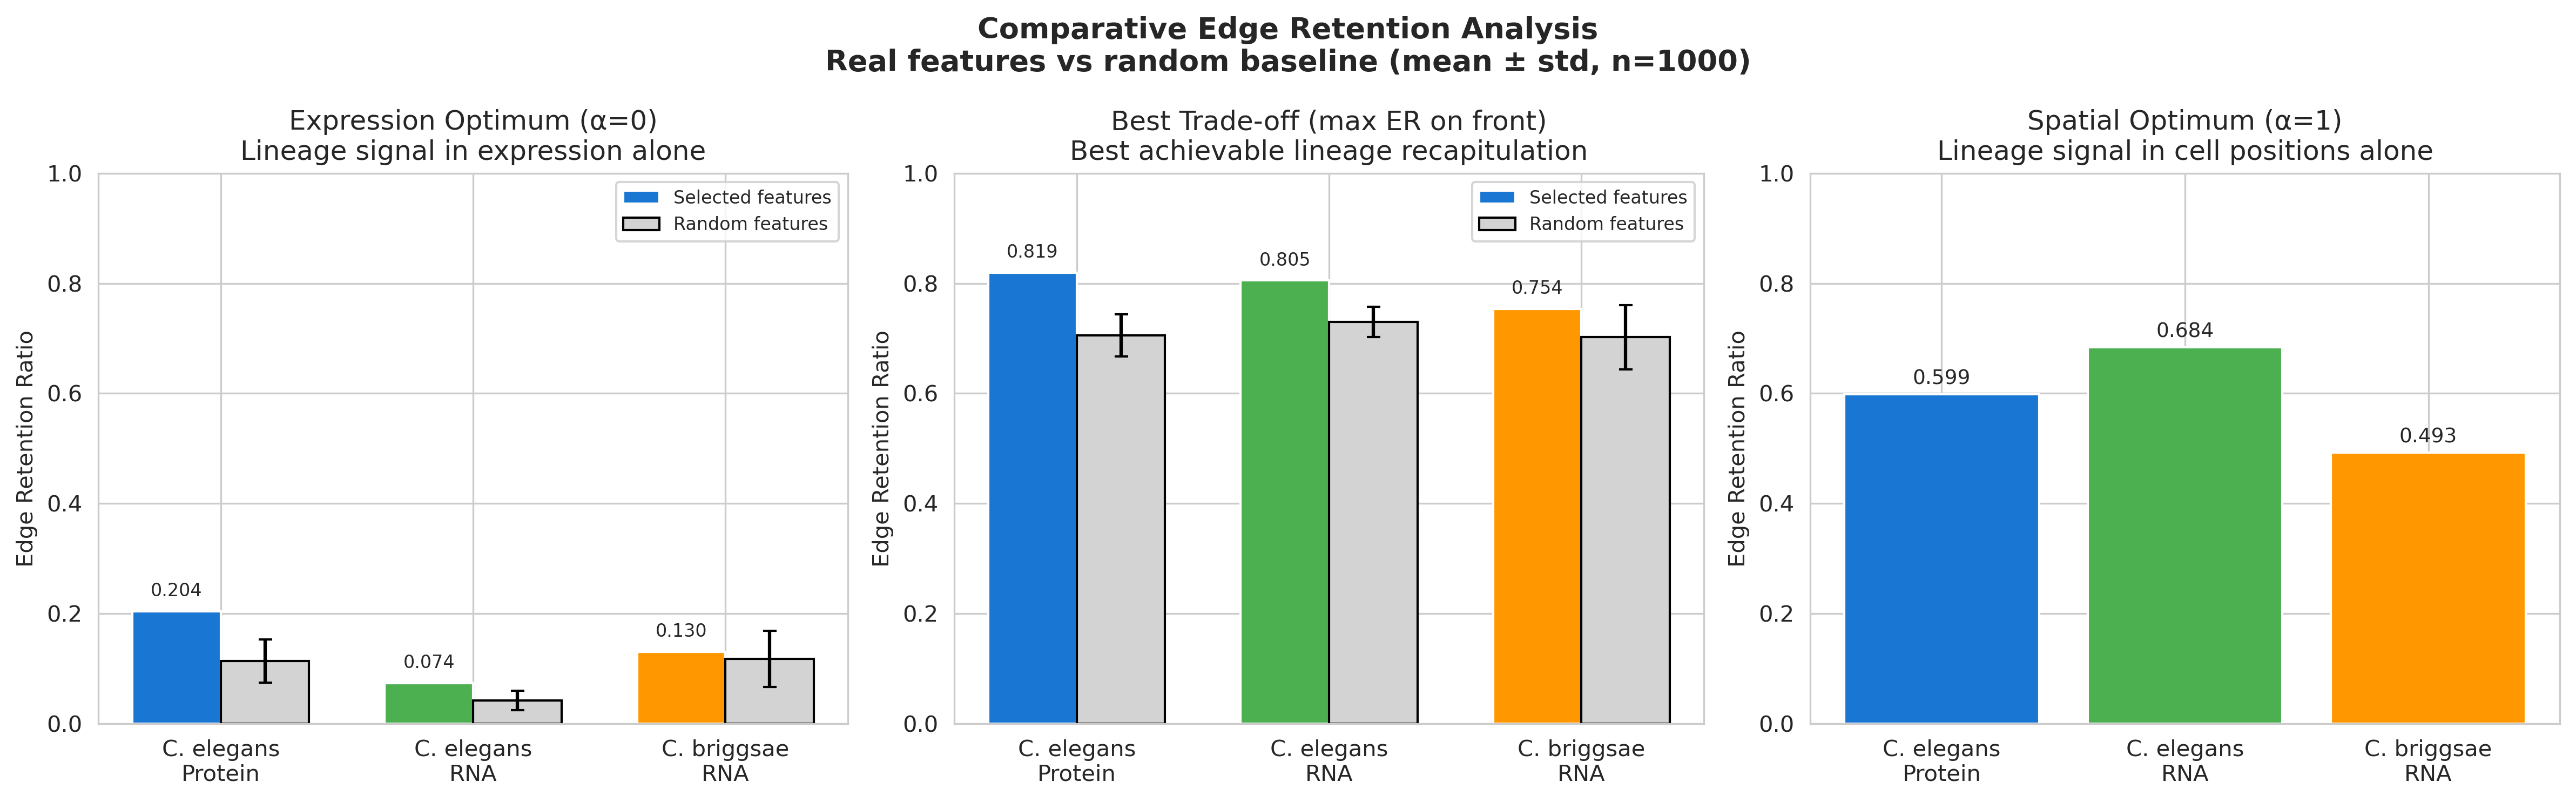

In [44]:
# ── Bar chart: scale-invariant edge retention metrics across datasets ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = ['C. elegans\nProtein', 'C. elegans\nRNA', 'C. briggsae\nRNA']
colors = ['#1976D2', '#4CAF50', '#FF9800']

# Collect real and random stats
real_expr_opt = [res_top_prot['optimal_exp_edge_ratio'],
                 res_er['optimal_exp_edge_ratio'],
                 res_cb['optimal_exp_edge_ratio']]
rand_expr_opt = [prot_rand_df['optimal_exp_edge_ratio'].mean(),
                 er_rand_df['optimal_exp_edge_ratio'].mean(),
                 cb_rand_df['optimal_exp_edge_ratio'].mean()]
rand_expr_opt_std = [prot_rand_df['optimal_exp_edge_ratio'].std(),
                     er_rand_df['optimal_exp_edge_ratio'].std(),
                     cb_rand_df['optimal_exp_edge_ratio'].std()]

real_max_er = [res_top_prot['largest_edge_ratio'],
               res_er['largest_edge_ratio'],
               res_cb['largest_edge_ratio']]
rand_max_er = [prot_rand_df['largest_edge_ratio'].mean(),
               er_rand_df['largest_edge_ratio'].mean(),
               cb_rand_df['largest_edge_ratio'].mean()]
rand_max_er_std = [prot_rand_df['largest_edge_ratio'].std(),
                   er_rand_df['largest_edge_ratio'].std(),
                   cb_rand_df['largest_edge_ratio'].std()]

real_xyz_opt = [res_top_prot['optimal_xyz_edge_ratio'],
                res_er['optimal_xyz_edge_ratio'],
                res_cb['optimal_xyz_edge_ratio']]

x = np.arange(len(datasets))
w = 0.35

# ── Panel 1: Expression Optimum Edge Ratio (α=0) ──
ax = axes[0]
bars1 = ax.bar(x - w/2, real_expr_opt, w, color=colors, edgecolor='white',
               label='Selected features')
bars2 = ax.bar(x + w/2, rand_expr_opt, w, color='lightgray', edgecolor='black',
               yerr=rand_expr_opt_std, capsize=3, label='Random features')
ax.set_ylabel('Edge Retention Ratio')
ax.set_title('Expression Optimum (α=0)\nLineage signal in expression alone')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
for bar, val in zip(bars1, real_expr_opt):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# ── Panel 2: Max Edge Retention (best trade-off anywhere on front) ──
ax = axes[1]
bars1 = ax.bar(x - w/2, real_max_er, w, color=colors, edgecolor='white',
               label='Selected features')
bars2 = ax.bar(x + w/2, rand_max_er, w, color='lightgray', edgecolor='black',
               yerr=rand_max_er_std, capsize=3, label='Random features')
ax.set_ylabel('Edge Retention Ratio')
ax.set_title('Best Trade-off (max ER on front)\nBest achievable lineage recapitulation')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
for bar, val in zip(bars1, real_max_er):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# ── Panel 3: Spatial Optimum Edge Ratio (α=1) ──
ax = axes[2]
# Spatial optimum is the same for all feature sets (same xyz data within species)
# For protein/ce-RNA (same tracking), it's identical; for cb-RNA it differs
bars = ax.bar(datasets, real_xyz_opt, color=colors, edgecolor='white')
ax.set_ylabel('Edge Retention Ratio')
ax.set_title('Spatial Optimum (α=1)\nLineage signal in cell positions alone')
ax.set_ylim(0, 1)
for bar, val in zip(bars, real_xyz_opt):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Comparative Edge Retention Analysis\nReal features vs random baseline (mean ± std, n=1000)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


### Cross-Species Comparison — Std-Based Scaling

Stacked Pareto fronts for all three datasets using std-based normalization
(1 unit = 1σ of cousin-randomized total cost). Each dataset has its own σ scale,
making direct overlay inappropriate — hence the stacked layout.
Edge retention curves are overlaid since ER is always in [0,1].

  C. elegans Protein (T=255): lineage at (25.5σ, 150.0σ), max ER=0.819


  C. elegans RNA (T=255): lineage at (22.8σ, 100.5σ), max ER=0.835
  C. briggsae RNA (T=155): lineage at (13.5σ, 72.6σ), max ER=0.725


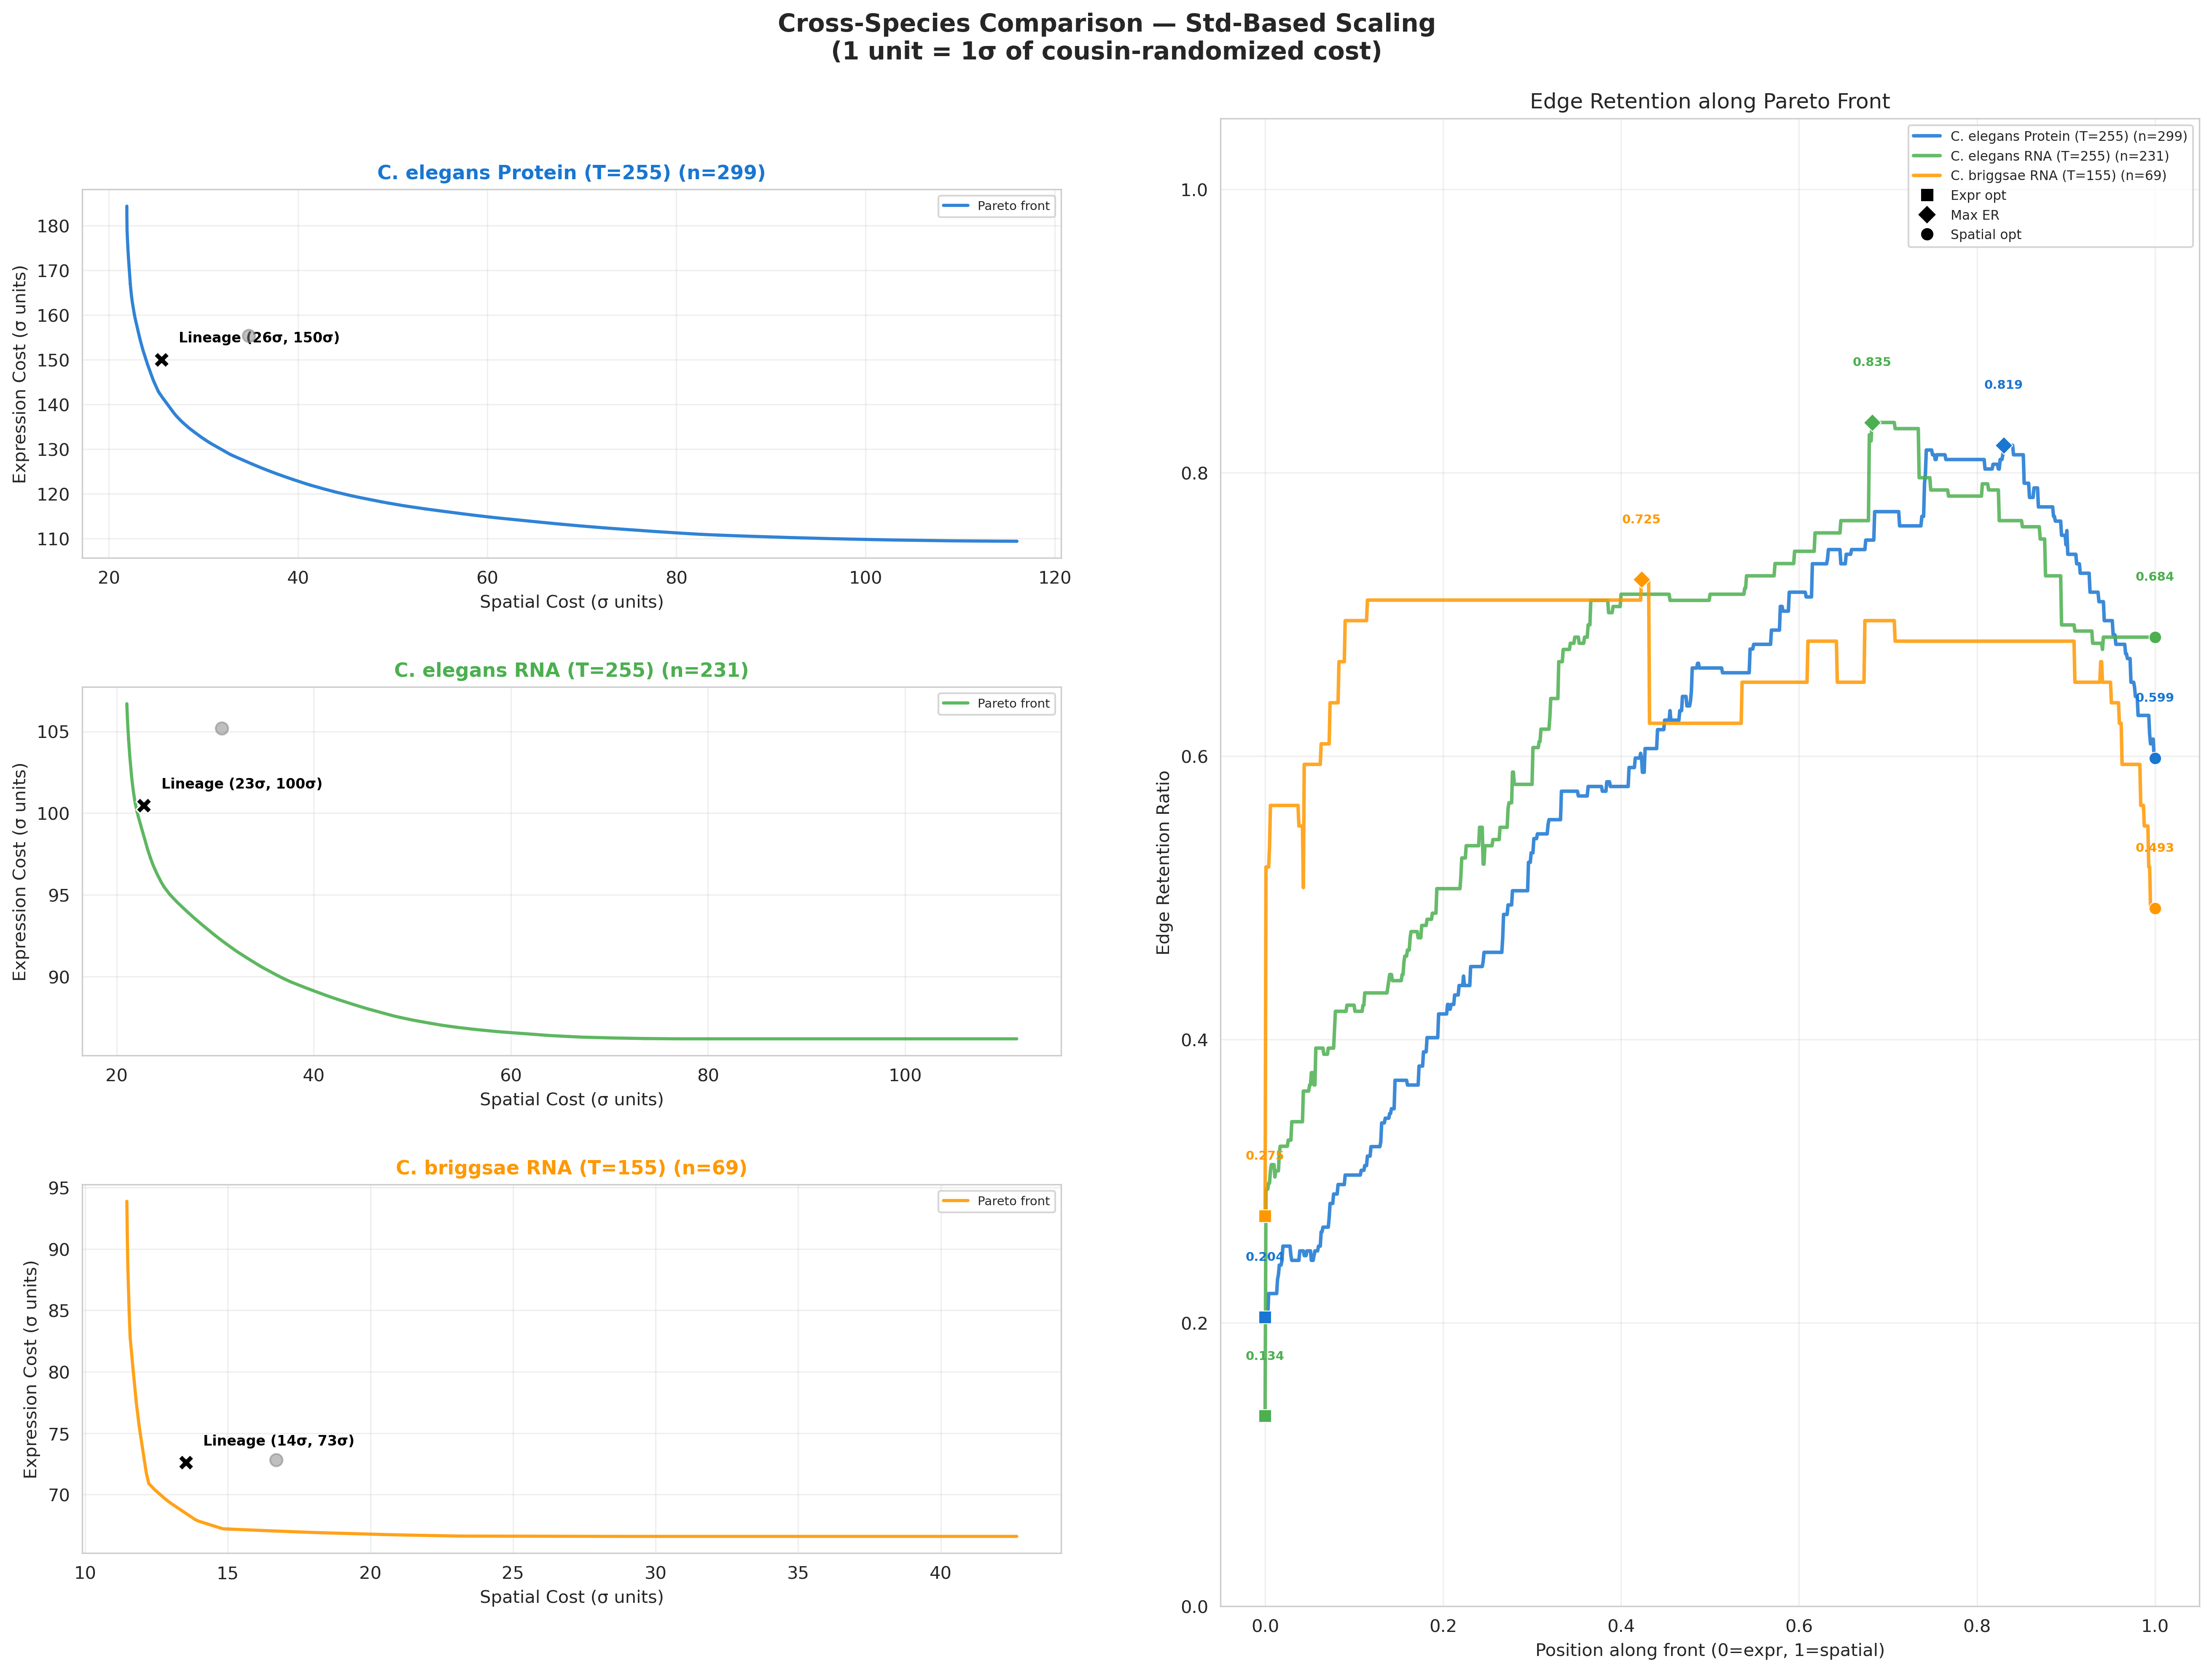

In [45]:
# ═══════════════════════════════════════════════════════════
# Cross-species comparison: std-scaled stacked Pareto + ER overlay
# ═══════════════════════════════════════════════════════════

# Compute random stats for each dataset
prot_xs_groups = build_cousin_groups(prot_data['terminal_nodes'], gp_map)
er_xs_groups = build_cousin_groups(elegans_rna_term['terminal_nodes'], gp_map)
cb_xs_groups = build_cousin_groups(briggsae_rna_term['terminal_nodes'], gp_map)

prot_xs_rs = compute_cousin_random_stats(xyz_cost_prot, all_exp_cost_prot, prot_xs_groups, n_random=500, seed=42)
er_xs_rs = compute_cousin_random_stats(xyz_cost_er, all_exp_cost_er, er_xs_groups, n_random=500, seed=42)
cb_xs_rs = compute_cousin_random_stats(xyz_cost_cb, all_exp_cost_cb, cb_xs_groups, n_random=500, seed=42)

datasets = [
    ('C. elegans Protein (T=255)', xyz_cost_prot, all_exp_cost_prot, prot_data['terminal_parents'], '#1976D2', prot_xs_rs),
    ('C. elegans RNA (T=255)',      xyz_cost_er,   all_exp_cost_er,   elegans_rna_term['terminal_parents'], '#4CAF50', er_xs_rs),
    ('C. briggsae RNA (T=155)',     xyz_cost_cb,   all_exp_cost_cb,   briggsae_rna_term['terminal_parents'], '#FF9800', cb_xs_rs),
]

fig = plt.figure(figsize=(22, 14))
x_front = np.linspace(0, 1, 1001)
markers = {'expr_opt_idx': 's', 'spatial_opt_idx': 'o', 'max_er_idx': 'D'}

# ── TOP: 3 stacked Pareto panels ──
gs_pareto = fig.add_gridspec(3, 1, left=0.03, right=0.38, hspace=0.35)

for idx, (name, xm, em, tp, color, rs) in enumerate(datasets):
    ax = fig.add_subplot(gs_pareto[idx])
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    n = len(tp)
    lx = xm.diagonal().sum() / rs['xyz_std']
    le = em.diagonal().sum() / rs['exp_std']
    rx = rs['xyz_mean'] / rs['xyz_std']
    re = rs['exp_mean'] / rs['exp_std']
    
    ax.plot(xyz_arr, exp_arr, color=color, lw=1.8, alpha=0.9, label='Pareto front')
    ax.scatter(rx, re, color='gray', marker='o', s=50, alpha=0.5, zorder=5)
    ax.scatter(lx, le, color='black', marker='X', s=80, edgecolors='white', lw=0.8, zorder=10)
    ax.annotate(f'Lineage ({lx:.0f}σ, {le:.0f}σ)', (lx, le),
                xytext=(10, 10), textcoords='offset points', fontsize=8, color='black', fontweight='bold')
    ax.set_xlabel('Spatial Cost (σ units)'); ax.set_ylabel('Expression Cost (σ units)')
    ax.set_title(f'{name} (n={n})', fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)
    print(f"  {name}: lineage at ({lx:.1f}σ, {le:.1f}σ), max ER={edge_arr.max():.3f}")

# ── BOTTOM: Edge retention overlay ──
ax_er = fig.add_subplot(fig.add_gridspec(1, 1, left=0.42, right=0.98, top=0.92, bottom=0.08)[0])

for name, xm, em, tp, color, rs in datasets:
    __, ___, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    n = len(tp)
    ax_er.plot(x_front, edge_arr, color=color, lw=2, alpha=0.85, label=f'{name} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_er.scatter(x_front[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_er.annotate(f'{edge_arr[idx]:.3f}', (x_front[idx], edge_arr[idx]+0.04),
                       color=color, fontsize=7, ha='center', fontweight='bold')

ax_er.legend(handles=list(ax_er.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
ax_er.set_xlabel('Position along front (0=expr, 1=spatial)'); ax_er.set_ylabel('Edge Retention Ratio')
ax_er.set_title('Edge Retention along Pareto Front', fontsize=12)
ax_er.set_ylim(0, 1.05); ax_er.grid(True, alpha=0.3)

fig.suptitle('Cross-Species Comparison — Std-Based Scaling\n(1 unit = 1σ of cousin-randomized cost)',
             fontsize=14, fontweight='bold', y=0.98)
plt.show()


### Key Observations

**Interpreting the scale-invariant metrics:**

All metrics below are **edge retention ratios** (ER) — the fraction of real parent→child edges
preserved by the optimal assignment. These are directly comparable across datasets because they
are unitless proportions, unlike alpha values which depend on the arbitrary relative scaling of
spatial (µm) and expression (cosine distance) costs.

- **Expression Optimum ER** (α=0, left panel): How many real lineage edges are preserved when
  optimizing purely for expression similarity. This measures how much lineage information is
  encoded in the expression data alone, independent of spatial constraints. *Key comparison:
  real features vs random baseline.*

- **Best Trade-off ER** (center panel): The maximum edge retention achieved at any point on
  the Pareto front. This is the best possible lineage recapitulation achievable by any weighted
  combination of spatial and expression costs. *Key comparison: real features vs random baseline.*

- **Spatial Optimum ER** (α=1, right panel): How many real lineage edges are preserved when
  optimizing purely for physical proximity. Within a species this is the same regardless of
  expression modality (same tracking data). Differences between C. elegans and C. briggsae
  reflect genuine differences in cell positioning.

**What to look for:**
1. **Real >> Random at expression optimum**: The selected features carry genuine
   lineage-relevant information beyond what random feature sets provide.
2. **Best trade-off ER**: The ceiling for how much of the lineage can be recapitulated
   by any spatial-expression compromise.
3. **Cross-species comparison**: How does C. briggsae (same 20 shared TFs, different
   tracking and expression) compare to C. elegans RNA?
4. **Cross-modality comparison**: Does protein-level data retain more lineage edges
   than RNA-seq for the same species?


---
## Legacy Experiments

The cells below are retained from earlier iterations of this analysis.
They are commented out and preserved for reference.


In [46]:
# # ── Subtree Pareto Analysis ──
# # def terminal_pareto_by_subtree(subtree_root: str, exp_df=selected_protein_exp, save_fig=True):
# #     subtree_terminal_nodes = []
# #     subtree_terminal_parents = []
# #     def dfs_subtree(node, parent):
# #         children = node.get("children", [])
# #         lookup_name = map_names(node["did"])
# #         if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
# #             p_lookup_name = map_names(parent['did'])
# #             if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
# #                 subtree_terminal_nodes.append(lookup_name)
# #                 subtree_terminal_parents.append(p_lookup_name)
# #         else:
# #             for child in children:
# #                 dfs_subtree(child, node)
# #     dfs_subtree(internal_node_dict[subtree_root]['node'], None)
# #     print(len(subtree_terminal_nodes))
# #     ...
# #     # (See original notebook for full implementation)


In [47]:
# # ── Cousin Group Analysis ──
# # def terminal_cousin_group(terminal_ancestry, degree=2):
# #     lowest_common_ancestor_group = defaultdict(list)
# #     for terminal_name, ancestry in terminal_ancestry.items():
# #         if len(ancestry) < degree:
# #             continue
# #         lca = ancestry[-degree]
# #         lowest_common_ancestor_group[lca].append(terminal_name)
# #     return lowest_common_ancestor_group
# #
# # cell_type_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
# # lineage_type_dict = defaultdict(str)
# # ...


In [48]:
# # ── Homo vs Hetero-type Sibling Expression Distance ──
# # from scipy.stats import mannwhitneyu
# # from scipy.spatial.distance import minkowski
# #
# # def homo_hecter_distance_comp(expression_df, distance_func=minkowski):
# #     homo_dists = []
# #     hecter_dists = []
# #     for siblings in homo_type_siblings:
# #         sib1_vec = expression_df.loc[siblings[0]].values
# #         sib2_vec = expression_df.loc[siblings[1]].values
# #         homo_dists.append(distance_func(sib1_vec, sib2_vec))
# #     ...
# #     return mannwhitneyu(homo_dists, hecter_dists)


In [49]:
# # ── p-value distribution: Euclidean distance ──
# # p_val_list = []
# # for i in tqdm(range(100000)):
# #     np.random.seed(i)
# #     selected_proteins = np.random.choice(protein_exp.columns, size=20, replace=False)
# #     selected_df = protein_exp[selected_proteins]
# #     p_val_list.append(homo_hecter_distance_comp(selected_df)[1])
# # ...


In [50]:
# # ── p-value distribution: Cosine distance ──
# # cos_p_val_list = []
# # for i in tqdm(range(100000)):
# #     np.random.seed(i)
# #     selected_proteins = np.random.choice(protein_exp.columns, size=20, replace=False)
# #     selected_df = protein_exp[selected_proteins]
# #     cos_p_val_list.append(homo_hecter_distance_comp(selected_df, distance_func=cosine)[1])
# # ...


In [51]:
# # ── TerminalPareto class experiments ──
# # new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry,
# #                      xyz_coord_dict, lineage_exp, binary_lineage_exp,
# #                      binary_lineage_end_exp,
# #                      title="Pareto Front of 299 Terminal Cells")
# # xyz_mat, exp_mat = new_pf.compute_cost_matrices()
# # res = new_pf.compute_pareto_front(xyz_mat, exp_mat, monte_carlo=False,
# #                                   return_lca_distances=True)
# # new_pf.pre_plot()
